In [20]:
from pathlib import Path
import numpy as np
import cobra
from cobra.util.array import create_stoichiometric_matrix

OUT_DIR = Path("out")
OUT_DIR.mkdir(exist_ok=True)

SBML_PATH = Path("yeast-GEM.xml")
assert SBML_PATH.is_file(), f"No se encontro SBML: {SBML_PATH.resolve()}"

MODEL_READY_SBML = OUT_DIR / "model_ready.xml"
S_FILE = OUT_DIR / "S.csv"
LB_FILE = OUT_DIR / "lb.csv"
UB_FILE = OUT_DIR / "ub.csv"
RXN_FILE = OUT_DIR / "rxn_ids.txt"
MET_FILE = OUT_DIR / "met_ids.txt"

print(f"SBML: {SBML_PATH.resolve()}")
print(f"OUT_DIR: {OUT_DIR.resolve()}")


SBML: C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\yeast-GEM.xml
OUT_DIR: C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\out


In [21]:
model = cobra.io.read_sbml_model(str(SBML_PATH))

print("Modelo cargado")
print(f"- Metabolitos: {len(model.metabolites)}")
print(f"- Reacciones: {len(model.reactions)}")
print(f"- Genes: {len(model.genes)}")

rxn_ids = {r.id for r in model.reactions}
obj_candidates = ["r_2111"]
obj_id = next((rid for rid in obj_candidates if rid in rxn_ids), None)
print(f"- Objetivo candidato: {obj_id}")


Modelo cargado
- Metabolitos: 2806
- Reacciones: 4131
- Genes: 1161
- Objetivo candidato: r_2111


In [22]:
key_rxn_ids = ["r_1761", "r_1714", "r_1709", "r_1992", "r_4046", "r_4598"]
METS_ANAEROBIC_BYPASS = ["s_3714[c]", "s_1198[c]", "s_1203[c]", "s_1207[c]", "s_1212[c]", "s_0529[c]"]

rxn_idx = {r.id: i + 1 for i, r in enumerate(model.reactions)}
met_idx = {m.id: i + 1 for i, m in enumerate(model.metabolites)}

rxn_nms = {r.id: r.name for r in model.reactions}
met_nms = {m.id: m.name for m in model.metabolites}

print()
print("Chequeo de reacciones clave")
for rid in key_rxn_ids:
    found = rid in rxn_idx
    idx = rxn_idx[rid] if found else -1
    name = rxn_nms.get(rid, "Unknown")
    print(f"- {rid:8s} found={found} idx={idx} name={name}")

print()
print("Chequeo de metabolitos clave")
for mid in METS_ANAEROBIC_BYPASS:
    found = mid in met_idx
    alt = mid.replace("[c]", "")
    found_alt = (not found) and (alt in met_idx)
    idx = met_idx[mid] if found else (met_idx[alt] if found_alt else -1)
    print(f"- {mid:10s} found={found or found_alt} idx={idx} name={met_nms.get(mid, met_nms.get(alt, 'Unknown'))}")



Chequeo de reacciones clave
- r_1761   found=True idx=1221 name=ethanol exchange
- r_1714   found=True idx=1180 name=D-glucose exchange
- r_1709   found=True idx=1175 name=D-fructose exchange
- r_1992   found=True idx=1408 name=oxygen exchange
- r_4046   found=True idx=3411 name=non-growth associated maintenance reaction
- r_4598   found=True idx=3948 name=cofactor pseudoreaction

Chequeo de metabolitos clave
- s_3714[c]  found=True idx=2208 name=heme a
- s_1198[c]  found=True idx=942 name=NAD
- s_1203[c]  found=True idx=947 name=NADH
- s_1207[c]  found=True idx=951 name=NADP(+)
- s_1212[c]  found=True idx=955 name=NADPH
- s_0529[c]  found=True idx=400 name=coenzyme A


In [23]:
def find_metabolite(mdl, mid):
    met_ids = {m.id for m in mdl.metabolites}
    if mid in met_ids:
        return mdl.metabolites.get_by_id(mid)
    clean = mid.replace("[c]", "")
    if clean in met_ids:
        return mdl.metabolites.get_by_id(clean)
    return None

print(f"Reacción r_4598 antes: {model.reactions.get_by_id('r_4598').build_reaction_string()}")

removed = 0.0
if "r_4598" in {r.id for r in model.reactions}:
    rcof = model.reactions.get_by_id("r_4598")
    updates = {}
    for mid in METS_ANAEROBIC_BYPASS:
        met = find_metabolite(model, mid)
        if met is None:
            continue
        coef = rcof.metabolites.get(met, 0.0)
        if coef != 0:
            updates[met] = -coef
            removed += abs(coef)
    if updates:
        rcof.add_metabolites(updates)

print(f"- Metabolitos eliminados de r_4598: {len(METS_ANAEROBIC_BYPASS)}")
print(f"Reacción r_4598 actualizada: {model.reactions.get_by_id('r_4598').build_reaction_string()}")

Reacción r_4598 antes: 0.000190000006114133 s_0529 + 9.99999974737875e-06 s_0687 + 1e-06 s_0750 + 0.00264999992214143 s_1198 + 0.000150000007124618 s_1203 + 0.000569999974686652 s_1207 + 0.00270000007003546 s_1212 + 0.000989999971352518 s_1405 + 1.20000004244503e-06 s_1475 + 6.34000025456771e-05 s_1487 + 9.99999997475243e-07 s_3714 --> s_4205
- Metabolitos eliminados de r_4598: 6
Reacción r_4598 actualizada: 9.99999974737875e-06 s_0687 + 1e-06 s_0750 + 0.000989999971352518 s_1405 + 1.20000004244503e-06 s_1475 + 6.34000025456771e-05 s_1487 --> s_4205


In [24]:
# --- Configuracion de bounds con trazabilidad ---

# Index rapido por ID para evitar busquedas repetidas
rxn_by_id = {r.id: r for r in model.reactions}
change_log = []

# Trazas configurables (ajustables)
VITAMIN_TRACE_LB = -1e-2   # traza mas elevada para vitaminas
ION_TRACE_LB = -1e-3       # trazas para iones esenciales


def _fmt_bound(x):
    return f"{x:.3f}" if isinstance(x, (int, float)) else str(x)


def _short(txt, n=70):
    txt = (txt or "").strip()
    return txt if len(txt) <= n else txt[: n - 3] + "..."


def set_bounds_logged(mdl, rid, lb=None, ub=None, group="", note=""):
    rec = {
        "group": group,
        "rid": rid,
        "note": note,
        "status": "MISSING",
        "name": "",
        "old_lb": None,
        "old_ub": None,
        "new_lb": None,
        "new_ub": None,
    }

    if rid not in rxn_by_id:
        print(f"  [MISSING] {rid:8s} | no existe en el modelo")
        change_log.append(rec)
        return rec

    r = rxn_by_id[rid]
    old_lb, old_ub = float(r.lower_bound), float(r.upper_bound)
    new_lb = old_lb if lb is None else float(lb)
    new_ub = old_ub if ub is None else float(ub)

    r.lower_bound = new_lb
    r.upper_bound = new_ub

    rec.update(
        {
            "status": "UPDATED",
            "name": r.name,
            "old_lb": old_lb,
            "old_ub": old_ub,
            "new_lb": new_lb,
            "new_ub": new_ub,
        }
    )
    change_log.append(rec)

    print(
        f"  [OK] {rid:8s} | {_short(r.name, 46):46s} | "
        f"({_fmt_bound(old_lb):>8s}, {_fmt_bound(old_ub):>8s}) -> "
        f"({_fmt_bound(new_lb):>8s}, {_fmt_bound(new_ub):>8s})"
    )
    return rec


def apply_group(group_name, reaction_ids, lb=None, ub=None, note=""):
    print("\n" + "=" * 100)
    print(f"Grupo: {group_name}")
    print(f"Objetivo de bounds: lb={lb if lb is not None else 'sin cambio'}, ub={ub if ub is not None else 'sin cambio'}")
    if note:
        print(f"Nota: {note}")
    print("-" * 100)
    for rid in reaction_ids:
        set_bounds_logged(model, rid, lb=lb, ub=ub, group=group_name, note=note)


# Reglas de manipulacion, agrupadas por sentido biologico/proceso
ALL_N_SOURCE_IDS = [
    "r_1654", "r_1904", "r_1891", "r_1889", "r_1880", "r_1881",
    "r_1873", "r_1879", "r_1810", "r_1906", "r_1911", "r_1914",
    "r_1899", "r_1897", "r_1903", "r_1913", "r_1912", "r_1893",
    "r_1900", "r_1902", "r_1883", "r_1987", "r_1800",
]

KINETIC_N_SOURCE_IDS = [
    "r_1654",  # NH4+
    "r_1879",  # Arg
    "r_1891",  # Gln
    "r_1889",  # Glu
    "r_1906",  # Ser
    "r_1911",  # Thr
    "r_1873",  # Ala
    "r_1912",  # Trp
    "r_1899",  # Leu
]

GROUP_RULES = [
    {
        "group": "Anaerobiosis (O2 apagado)",
        "ids": ["r_1992"],
        "lb": 0.0,
        "ub": 0.0,
        "note": "Forzar intercambio de oxigeno en cero.",
    },
    {
        "group": "Suplementos anaerobicos abiertos",
        "ids": ["r_1757", "r_1915", "r_1994", "r_2106", "r_2134", "r_2137", "r_2189"],
        "lb": -1000.0,
        "ub": 0.0,
        "note": "Permitir captacion de suplementos en anaerobiosis.",
    },
    {
        "group": "Shuttles cerrados",
        "ids": ["r_0713", "r_0714", "r_0487"],
        "lb": 0.0,
        "ub": 0.0,
        "note": "Se aplican bounds asimetricos por reaccion.",
    },
    {
        "group": "Fuentes de carbono",
        "ids": ["r_1714", "r_1709"],
        "lb": -1000.0,
        "ub": 0.0,
        "note": "Glucosa y fructosa solo como uptake.",
    },
    {
        "group": "Fuentes de nitrogeno (todos)",
        "ids": ALL_N_SOURCE_IDS,
        "lb": 0.0,
        "ub": 0.0,
        "note": "23 fuentes de N inhabilitadas para captacion.",
    },
    {
        "group": "Fuentes de nitrogeno (medio vinico) - cinetica",
        "ids": KINETIC_N_SOURCE_IDS,
        "lb": -1000.0,
        "ub": 0.0,
        "note": "7 fuentes de N cineticas habilitadas para captacion.",
    },
    {
        "group": "Vitaminas",
        "ids": ["r_2067", "r_1671", "r_1967", "r_2028", "r_1548", "r_2038", "r_1947"],
        "lb": VITAMIN_TRACE_LB,
        "ub": 0.0,
        "note": "Vitaminas en traza elevada (evitar uso masivo como carbono).",
    },
    {
        "group": "Fosfato abierto",
        "ids": ["r_2005"],
        "lb": -1000.0,
        "ub": 0.0,
        "note": "Liberar captacion de fosfato para diagnostico.",
    },
    {
        "group": "Sulfato abierto",
        "ids": ["r_2060"],
        "lb": -1000.0,
        "ub": 0.0,
        "note": "Liberar captacion de sulfato para diagnostico.",
    },
    {
        "group": "Iones esenciales",
        "ids": ["r_2020", "r_1861", "r_4596", "r_4597", "r_4594", "r_4600", "r_4595", "r_4593"],
        "lb": ION_TRACE_LB,
        "ub": 0.0,
        "note": "Iones en traza.",
    },
    {
        "group": "Productos abiertos",
        "ids": ["r_1761", "r_1808", "r_1634", "r_2056", "r_1549", "r_1546", "r_1552", "r_1765", "r_1867", "r_1866", "r_1862", "r_1865"],
        "lb": 0.0,
        "ub": 1000.0,
        "note": "Excrecion permitida.",
    },
    {
        "group": "Agua y protones",
        "ids": ["r_2100", "r_1832"],
        "lb": -1000.0,
        "ub": 1000.0,
    },
]

# Aplicar grupos estandar
for rule in GROUP_RULES:
    # Caso especial: shuttles con limites asimetricos
    if rule["group"] == "Shuttles cerrados":
        print("\n" + "=" * 100)
        print(f"Grupo: {rule['group']}")
        print("Nota: Cierres especificos por reaccion")
        print("-" * 100)
        set_bounds_logged(model, "r_0713", lb=0.0, ub=None, group=rule["group"], note="Cerrar uptake inverso")
        set_bounds_logged(model, "r_0714", lb=0.0, ub=None, group=rule["group"], note="Cerrar uptake inverso")
        set_bounds_logged(model, "r_0487", lb=None, ub=0.0, group=rule["group"], note="Cerrar direccion directa")
        continue

    apply_group(
        rule["group"],
        rule["ids"],
        lb=rule.get("lb", None),
        ub=rule.get("ub", None),
        note=rule.get("note", ""),
    )

# ATP de mantenimiento fijo
print("\n" + "=" * 100)
print("Grupo: ATP de mantenimiento")
print("-" * 100)
set_bounds_logged(model, "r_4046", lb=0.7, ub=0.7, group="ATPM", note="ATPM fijo")

# Resumen global de cambios
updated = [x for x in change_log if x["status"] == "UPDATED"]
missing = [x for x in change_log if x["status"] == "MISSING"]
print("\n" + "=" * 100)
print("Resumen de aplicacion de bounds")
print("=" * 100)
print(f"Total reglas procesadas: {len(change_log)}")
print(f"- Reacciones actualizadas: {len(updated)}")
print(f"- Reacciones faltantes:   {len(missing)}")
if missing:
    print("IDs faltantes:")
    for m in missing:
        print(f"  - {m['rid']} (grupo: {m['group']})")

# Chequeo final de reacciones clave con nombre y ecuacion
KEY_RXN_LABELS = {
    "r_1992": "Intercambio O2",
    "r_1714": "Uptake glucosa",
    "r_1709": "Uptake fructosa",
    "r_4046": "Mantenimiento ATP",
    "r_1761": "Intercambio etanol",
}

print("\n" + "=" * 100)
print("Chequeo final (reacciones clave)")
print("=" * 100)
for rid, label in KEY_RXN_LABELS.items():
    if rid not in rxn_by_id:
        print(f"- {label:20s} | {rid:8s} | MISSING")
        continue
    r = rxn_by_id[rid]
    eq = _short(getattr(r, "reaction", ""), n=90)
    print(
        f"- {label:20s} | {rid:8s} | {_short(r.name, 42):42s} | "
        f"lb={r.lower_bound:.3f}, ub={r.upper_bound:.3f}"
    )
    if eq:
        print(f"    ecuacion: {eq}")



Grupo: Anaerobiosis (O2 apagado)
Objetivo de bounds: lb=0.0, ub=0.0
Nota: Forzar intercambio de oxigeno en cero.
----------------------------------------------------------------------------------------------------
  [OK] r_1992   | oxygen exchange                                | (-1000.000, 1000.000) -> (   0.000,    0.000)

Grupo: Suplementos anaerobicos abiertos
Objetivo de bounds: lb=-1000.0, ub=0.0
Nota: Permitir captacion de suplementos en anaerobiosis.
----------------------------------------------------------------------------------------------------
  [OK] r_1757   | ergosterol exchange                            | (   0.000, 1000.000) -> (-1000.000,    0.000)
  [OK] r_1915   | lanosterol exchange                            | (   0.000, 1000.000) -> (-1000.000,    0.000)
  [OK] r_1994   | palmitoleate exchange                          | (   0.000, 1000.000) -> (-1000.000,    0.000)
  [OK] r_2106   | zymosterol exchange                            | (   0.000, 1000.000) -> (-10

In [25]:
# Diagnostico FBA rapido (antes de exportar a Julia)
print("\n" + "=" * 100)
print("Chequeo FBA con bounds actuales")
print("=" * 100)

solution = model.optimize()
print(f"status: {solution.status}")
print(f"objective ({model.objective.expression}): {solution.objective_value:.6g}")

if solution.status != "optimal":
    print("[WARN] El problema FBA no llego a optimo. Revisar bounds y consistencia del modelo.")

# Convencion: biomasa esperada positiva
if solution.objective_value <= 1e-8:
    print("[WARN] Crecimiento nulo o casi nulo (objective <= 1e-8).")
else:
    print("[OK] El modelo muestra crecimiento bajo bounds actuales.")

# Flujos clave: etiqueta biologica + ID + nombre de reaccion
key_flux_map = [
    ("Biomasa", "r_2111"),
    ("Uptake glucosa", "r_1714"),
    ("Uptake fructosa", "r_1709"),
    ("Produccion etanol", "r_1761"),
    ("Intercambio O2", "r_1992"),
    ("Mantenimiento ATP", "r_4046"),
]

print("\nFlujos clave (FBA):")
for label, rid in key_flux_map:
    if rid in rxn_by_id:
        rxn = rxn_by_id[rid]
        v = solution.fluxes.get(rid, float("nan"))
        print(f"- {label:20s} ({rid}) | {rxn.name} | v = {v: .6g}")
    else:
        print(f"- {label:20s} ({rid}) | MISSING")

# Diagnostico adicional de posibles bloqueos (uptakes de C/N)
print("\nUptakes de C/N habilitados (lb, ub, flujo):")
for rid in ["r_1714", "r_1709"] + KINETIC_N_SOURCE_IDS:
    if rid not in rxn_by_id:
        print(f"- {rid:8s}: MISSING")
        continue
    rxn = rxn_by_id[rid]
    v = solution.fluxes.get(rid, float("nan"))
    print(f"- {rxn.name:40s} ({rid}) | lb={rxn.lower_bound:8.3f}, ub={rxn.upper_bound:8.3f}, v={v: .6g}")



Chequeo FBA con bounds actuales
status: optimal
objective (1.0*r_2111 - 1.0*r_2111_reverse_58b69): 0.275482
[OK] El modelo muestra crecimiento bajo bounds actuales.

Flujos clave (FBA):
- Biomasa              (r_2111) | growth | v =  0.275482
- Uptake glucosa       (r_1714) | D-glucose exchange | v =  0
- Uptake fructosa      (r_1709) | D-fructose exchange | v = -17.0369
- Produccion etanol    (r_1761) | ethanol exchange | v =  0
- Intercambio O2       (r_1992) | oxygen exchange | v =  0
- Mantenimiento ATP    (r_4046) | non-growth associated maintenance reaction | v =  0.7

Uptakes de C/N habilitados (lb, ub, flujo):
- D-glucose exchange                       (r_1714) | lb=-1000.000, ub=   0.000, v= 0
- D-fructose exchange                      (r_1709) | lb=-1000.000, ub=   0.000, v=-17.0369
- ammonium exchange                        (r_1654) | lb=-1000.000, ub=   0.000, v= 0
- L-arginine exchange                      (r_1879) | lb=-1000.000, ub=   0.000, v=-0.337704
- L-glutamine ex

In [26]:
# Aplicar en COBRApy las mismas restricciones clave que en Notebook 2 (aprox. en t=0)
print("\n" + "=" * 100)
print("Imposicion de restricciones estilo Notebook 2 sobre flujos clave")
print("=" * 100)

import os
import re

# Switch principal: sin capeo de productos/biomasa (recomendado para diagnostico FBA/FVA)
APPLY_PRODUCT_CAPS = False
print(f"Modo capeo de producto/biomasa: {'ON' if APPLY_PRODUCT_CAPS else 'OFF (sin capeo)'}")

# --- Parametros con switch entre legacy y paper Zenteno ---
ZENTENO_PARAM_SET = os.getenv("ZENTENO_PARAM_SET", "paper2010").strip().lower()
if ZENTENO_PARAM_SET == "paper2010":
    MU0_nom    = 0.18
    YXN_nom    = 19.69
    YXG_nom    = 1.60
    YXF_nom    = 1.60
    YEG_nom    = 0.49
    YEF_nom    = 0.49
    Kn0_nom    = 0.01
    Kg0_nom    = 7.5
    Kf0_nom    = 7.5
    Kig0_nom   = 55.0
    Kie0_nom   = 40.0
    Kd0_nom    = 0.00044
    betaG0_nom = 0.225
    betaF0_nom = 0.225
elif ZENTENO_PARAM_SET == "legacy_calibrated":
    MU0_nom    = 0.141665
    YXN_nom    = 9.80576
    YXG_nom    = 0.394345
    YXF_nom    = 0.18622
    YEG_nom    = 0.14133
    YEF_nom    = 0.96932
    Kn0_nom    = 0.226882
    Kg0_nom    = 3.1514
    Kf0_nom    = 2.97625
    Kig0_nom   = 29.5276
    Kie0_nom   = 2.99809
    Kd0_nom    = 0.0000311736
    betaG0_nom = 1.41182
    betaF0_nom = 8.49482
else:
    raise ValueError(f"ZENTENO_PARAM_SET invalido: {ZENTENO_PARAM_SET}")

MU0 = MU0_nom
YEG = YEG_nom
YEF = YEF_nom
YXN = YXN_nom
MRATE_0 = 0.01

R_GAS = 8.314
R = R_GAS
EPS = 1e-9

try:
    T_BASE = float(os.getenv("T_CONST", "298.15"))
except ValueError:
    T_BASE = 293.15

T_STEPS = [36.0, 96.0]
T_DELTAS = [5.0, 3.0]
T_STEEP = 0.5

def dynamic_temperature(t):
    val = T_BASE
    for step_t, delta_t in zip(T_STEPS, T_DELTAS):
        sigmoid = 1.0 / (1.0 + np.exp(-T_STEEP * (t - step_t)))
        val += delta_t * sigmoid
    return val

def death_rate_T(E, T_val):
    Td = -0.0001 * E**3 + 0.0049 * E**2 - 0.1279 * E + 315.89
    s = 0.5 * (1.0 + np.tanh(0.5 * (T_val - Td)))
    base = Kd0_nom * np.exp(0.0415 * E + (130000.0 * (T_val - 305.65)) / (305.65 * R * T_val))
    return base * s

SQRT_2PI = np.sqrt(2.0 * np.pi)
def smooth_injection(t, t_shot, dose, width=1.0):
    if abs(t - t_shot) > 5.0 * width:
        return 0.0
    return (dose / (width * SQRT_2PI)) * np.exp(-0.5 * ((t - t_shot) / width) ** 2)

T_INJ_1 = 0.0
DOSE_1 = 0.0
WIDTH_1 = 5.0
T_INJ_2 = 0.0
DOSE_2 = 0.0
WIDTH_2 = 5.0

print(f"Parametros cineticos cargados: {ZENTENO_PARAM_SET}")
print(
    f"MU0={MU0}, YXN={YXN}, YXG={YXG_nom}, YXF={YXF_nom}, YEG={YEG}, YEF={YEF}, "
    f"Kn0={Kn0_nom}, Kg0={Kg0_nom}, Kf0={Kf0_nom}, Kig0={Kig0_nom}, Kie0={Kie0_nom}, "
    f"Kd0={Kd0_nom}, betaG0={betaG0_nom}, betaF0={betaF0_nom}"
)

MW_N   = 0.014007
MW_GLU = 0.180156
MW_FRU = 0.180156
MW_ETH = 0.046070

# Estado inicial usado en Notebook 2
cX, cN, cG, cF, cE, cO2 = 0.5, 0.14, 110.0, 110.0, 0.0, 0.0
T_val = dynamic_temperature(0.0)

# Factores de temperatura (mismas ecuaciones)
mu_T  = np.exp(59453.0 * (T_val - 300.0) / (300.0 * R_GAS * T_val))
Kg_T  = np.exp(46055.0 * (T_val - 293.15) / (293.15 * R_GAS * T_val))
b_T   = np.exp(11000.0 * (T_val - 296.15) / (296.15 * R_GAS * T_val))
mrate = MRATE_0 * np.exp(37681.0 * (T_val - 293.30) / (293.30 * R_GAS * T_val))

mu = MU0_nom * mu_T * (cN / (cN + Kn0_nom * Kg_T + EPS))
betaG = betaG0_nom * b_T * (cG / (cG + Kg0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))
betaF = betaF0_nom * b_T * (cF / (cF + Kf0_nom * Kg_T + EPS)) * (Kig0_nom * Kg_T / (cG + Kig0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))

vx = mu
vg = mu / YXG_nom + betaG / YEG_nom + mrate * (cG / (cG + cF + EPS))
vf = mu / YXF_nom + betaF / YEF_nom + mrate * (cF / (cG + cF + EPS))
vn = mu / YXN_nom
ve = (betaG + betaF) / MW_ETH

# Composicion de N (misma usada en notebooks)
N_atoms_map = {
    "r_1654": 1.0,
    "r_1879": 4.0,
    "r_1891": 2.0,
    "r_1889": 1.0,
    "r_1906": 1.0,
    "r_1911": 1.0,
    "r_1873": 1.0,
    "r_1912": 2.0,
    "r_1899": 1.0,
}
N_profile_map = {
    "r_1654": 0.40,
    "r_1879": 0.20,
    "r_1891": 0.10,
    "r_1889": 0.05,
    "r_1906": 0.05,
    "r_1911": 0.05,
    "r_1873": 0.05,
    "r_1912": 0.05,
    "r_1899": 0.05,
}

N_frac_map = {}
for rid in KINETIC_N_SOURCE_IDS:
    n_atoms = N_atoms_map[rid]
    n_profile = N_profile_map[rid]
    N_frac_map[rid] = n_profile / (n_atoms * MW_N)

# Limites fisicos equivalentes a Notebook 2 (en este snapshot)
lim_glu = vg / MW_GLU
lim_fru = vf / MW_FRU
lim_eth = ve
lim_obj = vx
lim_n_map = {rid: vn * N_frac_map[rid] for rid in KINETIC_N_SOURCE_IDS}

print("Limites calculados (snapshot t=0):")
print(f"- lim_glu uptake  : {lim_glu:.6g}")
print(f"- lim_fru uptake  : {lim_fru:.6g}")
print(f"- lim_eth prod    : {lim_eth:.6g}")
print(f"- lim_obj prod    : {lim_obj:.6g}")
print(f"- limN agregado   : {sum(lim_n_map.values()):.6g}")

# Aplicar bounds sobre modelo actual
# Uptakes: -v <= L  -> lb = -L, ub = 0
if "r_1714" in rxn_by_id:
    rxn_by_id["r_1714"].lower_bound = max(rxn_by_id["r_1714"].lower_bound, -lim_glu)
    rxn_by_id["r_1714"].upper_bound = min(rxn_by_id["r_1714"].upper_bound, 0.0)
if "r_1709" in rxn_by_id:
    rxn_by_id["r_1709"].lower_bound = max(rxn_by_id["r_1709"].lower_bound, -lim_fru)
    rxn_by_id["r_1709"].upper_bound = min(rxn_by_id["r_1709"].upper_bound, 0.0)

# N cinetico por fuente: -v_i <= L_i
for rid in KINETIC_N_SOURCE_IDS:
    if rid in rxn_by_id:
        Li = lim_n_map[rid]
        rxn_by_id[rid].lower_bound = max(rxn_by_id[rid].lower_bound, -Li)
        rxn_by_id[rid].upper_bound = min(rxn_by_id[rid].upper_bound, 0.0)

# Productos/biomasa: opcional
if APPLY_PRODUCT_CAPS:
    if "r_1761" in rxn_by_id:
        rxn_by_id["r_1761"].upper_bound = min(rxn_by_id["r_1761"].upper_bound, lim_eth)
    if "r_2111" in rxn_by_id:
        rxn_by_id["r_2111"].upper_bound = min(rxn_by_id["r_2111"].upper_bound, lim_obj)
else:
    # Sin capeo: liberar cualquier cap previo de sesiones anteriores
    if "r_1761" in rxn_by_id:
        rxn_by_id["r_1761"].upper_bound = max(rxn_by_id["r_1761"].upper_bound, 1000.0)
    if "r_2111" in rxn_by_id:
        rxn_by_id["r_2111"].upper_bound = max(rxn_by_id["r_2111"].upper_bound, 1000.0)

# O2 anaerobio: v=0
if "r_1992" in rxn_by_id:
    rxn_by_id["r_1992"].lower_bound = 0.0
    rxn_by_id["r_1992"].upper_bound = 0.0

print("\nBounds aplicados a flujos clave:")
for rid in ["r_2111", "r_1714", "r_1709", "r_1761", "r_1992", "r_4046"] + KINETIC_N_SOURCE_IDS:
    if rid in rxn_by_id:
        r = rxn_by_id[rid]
        print(f"- {r.name:40s} ({rid}) | lb={r.lower_bound: .6g}, ub={r.upper_bound: .6g}")

# Repetir FBA bajo estos bounds
print("\n" + "=" * 100)
print("Repeticion FBA con restricciones estilo Notebook 2")
print("=" * 100)

solution_nb2 = model.optimize()
print(f"status: {solution_nb2.status}")
print(f"objective ({model.objective.expression}): {solution_nb2.objective_value:.6g}")

print("\nFlujos clave (FBA restringido):")
for label, rid in [
    ("Biomasa", "r_2111"),
    ("Uptake glucosa", "r_1714"),
    ("Uptake fructosa", "r_1709"),
    ("Produccion etanol", "r_1761"),
    ("Intercambio O2", "r_1992"),
    ("Mantenimiento ATP", "r_4046"),
]:
    if rid in rxn_by_id:
        rxn = rxn_by_id[rid]
        v = solution_nb2.fluxes.get(rid, float("nan"))
        print(f"- {label:20s} ({rid}) | {rxn.name} | v = {v: .6g}")

# Diagnostico de fuente de carbono en la solucion
print("\n" + "=" * 100)
print("Diagnostico de fuentes de carbono (intercambios con uptake)")
print("=" * 100)

def carbon_atoms_from_formula(formula):
    if not formula:
        return 0
    m = re.search(r"C(?![a-z])(\d*)", formula)
    if not m:
        return 0
    g = m.group(1)
    return 1 if g == "" else int(g)

carbon_uptakes = []
for ex in model.exchanges:
    rid = ex.id
    v = float(solution_nb2.fluxes.get(rid, 0.0))
    if v < -1e-9:
        met = next(iter(ex.metabolites.keys()))
        c_atoms = carbon_atoms_from_formula(getattr(met, "formula", ""))
        c_rate = (-v) * c_atoms
        carbon_uptakes.append((rid, ex.name, met.id, met.formula, v, c_atoms, c_rate))

carbon_uptakes.sort(key=lambda x: x[6], reverse=True)

if not carbon_uptakes:
    print("No hay uptakes detectados en exchanges (v<0).")
else:
    total_c = sum(x[6] for x in carbon_uptakes)
    print(f"Top fuentes por C-atoms*|v| (total={total_c:.6g}):")
    for rid, rname, mid, formula, v, c_atoms, c_rate in carbon_uptakes[:15]:
        print(f"- {rname:36s} ({rid}) | met={mid:12s} formula={str(formula):10s} | v={v: .6g} | C={c_atoms:2d} | C*|v|={c_rate: .6g}")

    v_glu = float(solution_nb2.fluxes.get("r_1714", 0.0)) if "r_1714" in rxn_by_id else 0.0
    v_fru = float(solution_nb2.fluxes.get("r_1709", 0.0)) if "r_1709" in rxn_by_id else 0.0
    print("\nChequeo rapido azucares:")
    print(f"- r_1714 (glucosa): v={v_glu: .6g}")
    print(f"- r_1709 (fructosa): v={v_fru: .6g}")



Imposicion de restricciones estilo Notebook 2 sobre flujos clave
Modo capeo de producto/biomasa: OFF (sin capeo)
Parametros cineticos cargados: paper2010
MU0=0.18, YXN=19.69, YXG=1.6, YXF=1.6, YEG=0.49, YEF=0.49, Kn0=0.01, Kg0=7.5, Kf0=7.5, Kig0=55.0, Kie0=40.0, Kd0=0.00044, betaG0=0.225, betaF0=0.225
Limites calculados (snapshot t=0):
- lim_glu uptake  : 2.92775
- lim_fru uptake  : 1.5037
- lim_eth prod    : 6.47475
- lim_obj prod    : 0.141388
- limN agregado   : 0.397304

Bounds aplicados a flujos clave:
- growth                                   (r_2111) | lb= 0, ub= 1000
- D-glucose exchange                       (r_1714) | lb=-2.92775, ub= 0
- D-fructose exchange                      (r_1709) | lb=-1.5037, ub= 0
- ethanol exchange                         (r_1761) | lb= 0, ub= 1000
- oxygen exchange                          (r_1992) | lb= 0, ub= 0
- non-growth associated maintenance reaction (r_4046) | lb= 0.7, ub= 0.7
- ammonium exchange                        (r_1654) | lb=-0.2

In [27]:
# Modelo operativo curado: Caso C + etanol liberado (pFBA/FVA)
print("\n" + "=" * 100)
print("Construccion del modelo operativo: curacion Caso C + r_1761 abierto")
print("=" * 100)

# Esta celda es autocontenida: no depende de la celda what-if anterior.
# Editar manualmente los diccionarios de bounds de esta seccion cuando se quiera ajustar el criterio fisiologico.

import numpy as np
import pandas as pd
import cobra

OBJ_ID = "r_2111"
ETH_ID = "r_1761"
ATPM_ID = "r_4046"

if "model" not in globals():
    raise RuntimeError("Falta `model` en sesion. Ejecuta primero la carga y configuracion base del modelo.")

rxn_by_id = {r.id: r for r in model.reactions}
missing_base = [rid for rid in [OBJ_ID, ETH_ID] if rid not in rxn_by_id]
if missing_base:
    raise RuntimeError(f"Faltan reacciones requeridas en `model`: {missing_base}")

# --------------------------------------------------------------------------------------
# 1) Bounds manuales: editar aqui
# --------------------------------------------------------------------------------------

# Leaks estructurales no plausibles como valvula de carbono.
# Formato: rid: (lower_bound, upper_bound)
LEAK_BOUNDS_CASE_C = {
    "r_4501": (0.0, 0.0),  # turanose exchange
    "r_1650": (0.0, 0.0),  # trehalose exchange
    "r_4502": (0.0, 0.0),  # D-glucose 6-phosphate exchange
    "r_4538": (0.0, 0.0),  # 6-phospho-D-gluconate exchange
}

# Sumideros alternativos sospechosos.
# Formato: rid: (lower_bound, upper_bound)
ALT_SINK_BOUNDS_CASE_C = {
    "r_1549": (0.0, 0.12),  # (R,R)-2,3-butanediol exchange
    "r_4659": (0.0, 0.02),  # propanol exchange
    "r_4731": (0.0, 0.0003),  # diethyl-succinate exchange
    "r_4737": (0.0, 0.000003),  # ethyl-pyruvate exchange
    "r_1989": (0.0, 0.0),  # oxaloacetate exchange, sin excrecion
}

# Etanol liberado para simulacion operativa.
# Convencion exchange COBRA: negativo=uptake, positivo=secrecion.
# Para fermentacion normalmente se permite secrecion y se evita uptake artificial.
ETHANOL_BOUNDS_CASE_C_OPEN = (0.0, 1000.0)

# Mantenimiento ATP fijo para el modelo operativo.
# Cambiar a None si se quiere conservar los bounds actuales.
ATPM_BOUNDS_CASE_C = (0.7, 0.7)

# Cierre de excrecion de esteroles, permitiendo uptake si lb<0.
STEROL_KEYWORDS_CASE_C = (
    "sterol", "ergosterol", "lanosterol", "zymosterol", "fecosterol", "episterol"
)
CLOSE_STEROL_EXCRETION_CASE_C = True

# Si en algun ensayo quieres que `model` quede reemplazado por el operativo, poner True.
# Por defecto se conserva `model` y se usa `model_case_c_open_eth` / `model_operativo`.
REPLACE_BASE_MODEL_WITH_OPERATIONAL = False

# --------------------------------------------------------------------------------------
# 2) Utilidades de curacion y diagnostico
# --------------------------------------------------------------------------------------

def _carbon_atoms_case_c(formula):
    if not formula:
        return 0
    import re
    mm = re.search(r"C(?![a-z])(\d*)", formula)
    if not mm:
        return 0
    g = mm.group(1)
    return 1 if g == "" else int(g)


def _apply_bounds_by_id_case_c(mdl, bounds_map, label):
    touched = []
    ids = {r.id for r in mdl.reactions}

    for rid, bounds in bounds_map.items():
        if rid not in ids:
            touched.append({
                "grupo": label,
                "rid": rid,
                "name": None,
                "status": "missing",
                "old_lb": np.nan,
                "old_ub": np.nan,
                "new_lb": np.nan,
                "new_ub": np.nan,
            })
            continue

        lb, ub = map(float, bounds)
        if lb > ub:
            raise ValueError(f"Bounds invalidos para {rid}: lb={lb} > ub={ub}")

        rr = mdl.reactions.get_by_id(rid)
        old_lb = float(rr.lower_bound)
        old_ub = float(rr.upper_bound)
        rr.lower_bound = lb
        rr.upper_bound = ub

        touched.append({
            "grupo": label,
            "rid": rid,
            "name": rr.name,
            "status": "updated",
            "old_lb": old_lb,
            "old_ub": old_ub,
            "new_lb": float(rr.lower_bound),
            "new_ub": float(rr.upper_bound),
        })

    return touched


def _close_sterol_excretion_case_c(mdl):
    touched = []

    for ex in mdl.exchanges:
        txt = f"{ex.id} {(ex.name or '')}".lower()
        if not any(k in txt for k in STEROL_KEYWORDS_CASE_C):
            continue

        old_lb = float(ex.lower_bound)
        old_ub = float(ex.upper_bound)
        ex.upper_bound = min(float(ex.upper_bound), 0.0)

        touched.append({
            "grupo": "sterol_excretion_closed",
            "rid": ex.id,
            "name": ex.name,
            "status": "updated",
            "old_lb": old_lb,
            "old_ub": old_ub,
            "new_lb": float(ex.lower_bound),
            "new_ub": float(ex.upper_bound),
        })

    return touched


def _print_key_fluxes_case_c(sol, mdl, title):
    rxn_case = {r.id: r for r in mdl.reactions}
    print("\n" + title)
    for label, rid in [
        ("Biomasa", "r_2111"),
        ("Uptake glucosa", "r_1714"),
        ("Uptake fructosa", "r_1709"),
        ("Intercambio etanol", "r_1761"),
        ("Intercambio O2", "r_1992"),
        ("Mantenimiento ATP", "r_4046"),
        ("2,3-butanediol", "r_1549"),
        ("Propanol", "r_4659"),
        ("Diethyl-succinate", "r_4731"),
        ("Ethyl-pyruvate", "r_4737"),
        ("Oxaloacetate", "r_1989"),
    ]:
        if rid not in rxn_case:
            print(f"- {label:22s} ({rid}) | MISSING")
            continue
        rr = rxn_case[rid]
        v = float(sol.fluxes.get(rid, np.nan)) if getattr(sol, "status", None) == "optimal" else np.nan
        print(
            f"- {label:22s} ({rid}) | {rr.name:38s} | "
            f"v={v: .6g} | bounds=[{rr.lower_bound: .6g}, {rr.upper_bound: .6g}]"
        )


def _top_carbon_exchanges_case_c(sol, mdl, top_n=12):
    if getattr(sol, "status", None) != "optimal":
        return pd.DataFrame()

    rows = []
    for ex in mdl.exchanges:
        rid = ex.id
        v = float(sol.fluxes.get(rid, 0.0))
        if abs(v) <= 1e-8:
            continue
        met = next(iter(ex.metabolites.keys()))
        c_atoms = _carbon_atoms_case_c(getattr(met, "formula", ""))
        if c_atoms <= 0:
            continue
        rows.append({
            "rid": rid,
            "name": ex.name,
            "flux": v,
            "direction": "uptake" if v < 0 else "secretion",
            "C_atoms": c_atoms,
            "C_abs_flux": abs(v) * c_atoms,
        })

    out = pd.DataFrame(rows)
    if len(out):
        out = out.sort_values("C_abs_flux", ascending=False).head(top_n).reset_index(drop=True)
    return out

# --------------------------------------------------------------------------------------
# 3) Construccion del modelo operativo: copy(model) + Caso C + etanol abierto
# --------------------------------------------------------------------------------------

model_case_c_open_eth = model.copy()
curation_case_c_open_eth_log = []

curation_case_c_open_eth_log.extend(
    _apply_bounds_by_id_case_c(model_case_c_open_eth, LEAK_BOUNDS_CASE_C, "structural_leak_closed")
)
curation_case_c_open_eth_log.extend(
    _apply_bounds_by_id_case_c(model_case_c_open_eth, ALT_SINK_BOUNDS_CASE_C, "alt_sink_manual_bounds")
)
curation_case_c_open_eth_log.extend(
    _apply_bounds_by_id_case_c(model_case_c_open_eth, {ETH_ID: ETHANOL_BOUNDS_CASE_C_OPEN}, "ethanol_open")
)

if ATPM_BOUNDS_CASE_C is not None:
    if ATPM_ID in {r.id for r in model_case_c_open_eth.reactions}:
        curation_case_c_open_eth_log.extend(
            _apply_bounds_by_id_case_c(model_case_c_open_eth, {ATPM_ID: ATPM_BOUNDS_CASE_C}, "atpm_manual_bounds")
        )
    else:
        print(f"[WARN] No se encontro {ATPM_ID}; no se ajusto ATPM")

if CLOSE_STEROL_EXCRETION_CASE_C:
    curation_case_c_open_eth_log.extend(_close_sterol_excretion_case_c(model_case_c_open_eth))

curation_case_c_open_eth_df = pd.DataFrame(curation_case_c_open_eth_log)
rxn_case_c_open_eth = {r.id: r for r in model_case_c_open_eth.reactions}

print(f"Reacciones/exchanges modificados o revisados: {len(curation_case_c_open_eth_df)}")
display(curation_case_c_open_eth_df)

print("\nBounds principales del modelo operativo:")
for rid in [OBJ_ID, "r_1714", "r_1709", ETH_ID, "r_1992", ATPM_ID, *ALT_SINK_BOUNDS_CASE_C.keys()]:
    if rid in rxn_case_c_open_eth:
        rr = rxn_case_c_open_eth[rid]
        print(f"- {rr.name:40s} ({rid}) | lb={rr.lower_bound: .6g}, ub={rr.upper_bound: .6g}")

# --------------------------------------------------------------------------------------
# 4) FBA/pFBA operativo
# --------------------------------------------------------------------------------------

model_case_c_open_eth.objective = OBJ_ID
model_case_c_open_eth.objective_direction = "max"

sol_fba_case_c_open_eth = model_case_c_open_eth.optimize()
print("\nFBA previo a pFBA:")
print("status:", sol_fba_case_c_open_eth.status)
if sol_fba_case_c_open_eth.status == "optimal":
    print(f"mu_FBA={float(sol_fba_case_c_open_eth.fluxes.get(OBJ_ID, np.nan)):.6g}")
else:
    print("[WARN] El modelo operativo no tiene optimo FBA; no se ejecuta pFBA/FVA.")

sol_case_c_open_eth = sol_fba_case_c_open_eth
if sol_fba_case_c_open_eth.status == "optimal":
    sol_case_c_open_eth = cobra.flux_analysis.pfba(model_case_c_open_eth, fraction_of_optimum=1.0)

mu_case = float(sol_case_c_open_eth.fluxes.get(OBJ_ID, np.nan)) if sol_case_c_open_eth.status == "optimal" else np.nan
print("\npFBA operativo:")
print(f"status: {sol_case_c_open_eth.status}")
print(f"Crecimiento flujo {OBJ_ID}: {mu_case:.6g}")
if getattr(sol_case_c_open_eth, "objective_value", None) is not None:
    print(f"Objetivo interno pFBA/min-flux: {float(sol_case_c_open_eth.objective_value):.6g}")

_print_key_fluxes_case_c(sol_case_c_open_eth, model_case_c_open_eth, "Flujos clave (Caso C + etanol abierto, pFBA):")

carbon_exchange_case_c_open_eth_df = _top_carbon_exchanges_case_c(sol_case_c_open_eth, model_case_c_open_eth, top_n=15)
print("\nTop exchanges de carbono activos:")
display(carbon_exchange_case_c_open_eth_df)

# --------------------------------------------------------------------------------------
# 5) FVA y pFVA dirigido
# --------------------------------------------------------------------------------------

fva_case_c_open_eth_df = None
pfva_case_c_open_eth_df = None

if sol_case_c_open_eth.status == "optimal":
    model_case_c_open_eth.objective = OBJ_ID
    model_case_c_open_eth.objective_direction = "max"

    fva_ids_case_c_open_eth = [
        "r_2111", "r_1714", "r_1709", "r_1761", "r_1992", "r_4046",
        *list(globals().get("KINETIC_N_SOURCE_IDS", [])),
        *list(ALT_SINK_BOUNDS_CASE_C.keys()),
    ]
    fva_ids_case_c_open_eth = list(dict.fromkeys([rid for rid in fva_ids_case_c_open_eth if rid in rxn_case_c_open_eth]))

    print("\n" + "=" * 100)
    print("FVA @99% (Caso C + etanol abierto)")
    print("=" * 100)

    fva_case_c_open_eth_df = cobra.flux_analysis.flux_variability_analysis(
        model_case_c_open_eth,
        reaction_list=fva_ids_case_c_open_eth,
        fraction_of_optimum=0.99,
    )
    display(fva_case_c_open_eth_df)

    print("\n" + "=" * 100)
    print("pFVA @99% (pfba_factor=1.0)")
    print("=" * 100)

    try:
        pfva_case_c_open_eth_df = cobra.flux_analysis.flux_variability_analysis(
            model_case_c_open_eth,
            reaction_list=fva_ids_case_c_open_eth,
            fraction_of_optimum=0.99,
            pfba_factor=1.0,
        )
        display(pfva_case_c_open_eth_df)
    except TypeError:
        print("[WARN] Esta version de COBRApy no soporta `pfba_factor` en flux_variability_analysis.")
        print("       pFVA no fue calculado.")

# Alias explicito para celdas de simulacion posteriores.
model_operativo = model_case_c_open_eth
sol_operativo = sol_case_c_open_eth

if REPLACE_BASE_MODEL_WITH_OPERATIONAL:
    model = model_case_c_open_eth
    rxn_by_id = {r.id: r for r in model.reactions}
    print("\n[INFO] `model` fue reemplazado por `model_case_c_open_eth`.")
else:
    print("\n[INFO] `model` base se conserva sin reemplazar.")

print("\nVariables guardadas:")
print("- model_case_c_open_eth")
print("- model_operativo")
print("- sol_case_c_open_eth")
print("- sol_operativo")
print("- curation_case_c_open_eth_df")
print("- carbon_exchange_case_c_open_eth_df")
print("- fva_case_c_open_eth_df")
print("- pfva_case_c_open_eth_df")



Construccion del modelo operativo: curacion Caso C + r_1761 abierto
Reacciones/exchanges modificados o revisados: 17


,grupo,rid,name,status,old_lb,old_ub,new_lb,new_ub
0,structural_leak_closed,r_4501,turanose exchange,updated,0.0,1000.0,0.0,0.000000
1,structural_leak_closed,r_1650,trehalose exchange,updated,0.0,1000.0,0.0,0.000000
2,structural_leak_closed,r_4502,D-glucose 6-phosphate exchange,updated,0.0,1000.0,0.0,0.000000
3,structural_leak_closed,r_4538,6-phospho-D-gluconate exchange,updated,0.0,1000.0,0.0,0.000000
4,alt_sink_manual_bounds,r_1549,"(R,R)-2,3-butanediol exchange",updated,0.0,1000.0,0.0,0.120000
5,alt_sink_manual_bounds,r_4659,propanol exchange,updated,0.0,1000.0,0.0,0.020000
6,alt_sink_manual_bounds,r_4731,diethyl-succinate exchange,updated,0.0,1000.0,0.0,0.000300
7,alt_sink_manual_bounds,r_4737,ethyl-pyruvate exchange,updated,0.0,1000.0,0.0,0.000003
8,alt_sink_manual_bounds,r_1989,oxaloacetate(2-) exchange,updated,0.0,1000.0,0.0,0.000000
9,ethanol_open,r_1761,ethanol exchange,updated,0.0,1000.0,0.0,1000.000000



Bounds principales del modelo operativo:
- growth                                   (r_2111) | lb= 0, ub= 1000
- D-glucose exchange                       (r_1714) | lb=-2.92775, ub= 0
- D-fructose exchange                      (r_1709) | lb=-1.5037, ub= 0
- ethanol exchange                         (r_1761) | lb= 0, ub= 1000
- oxygen exchange                          (r_1992) | lb= 0, ub= 0
- non-growth associated maintenance reaction (r_4046) | lb= 0.7, ub= 0.7
- (R,R)-2,3-butanediol exchange            (r_1549) | lb= 0, ub= 0.12
- propanol exchange                        (r_4659) | lb= 0, ub= 0.02
- diethyl-succinate exchange               (r_4731) | lb= 0, ub= 0.0003
- ethyl-pyruvate exchange                  (r_4737) | lb= 0, ub= 3e-06
- oxaloacetate(2-) exchange                (r_1989) | lb= 0, ub= 0

FBA previo a pFBA:
status: optimal
mu_FBA=0.0806947

pFBA operativo:
status: optimal
Crecimiento flujo r_2111: 0.0806947
Objetivo interno pFBA/min-flux: 115.86

Flujos clave (Caso C 

,rid,name,flux,direction,C_atoms,C_abs_flux
0,r_1714,D-glucose exchange,-2.385928,uptake,6,14.315566
1,r_1761,ethanol exchange,6.794951,secretion,2,13.589902
2,r_1709,D-fructose exchange,-1.503697,uptake,6,9.022184
3,r_1672,carbon dioxide exchange,6.984298,secretion,1,6.984298
4,r_1808,glycerol exchange,0.207767,secretion,3,0.623300
5,r_1879,L-arginine exchange,-0.025633,uptake,6,0.153795
6,r_1899,L-leucine exchange,-0.025633,uptake,6,0.153795
7,r_1912,L-tryptophan exchange,-0.012816,uptake,11,0.140979
8,r_1889,L-glutamate exchange,-0.025633,uptake,5,0.128163
9,r_1891,L-glutamine exchange,-0.025633,uptake,5,0.128163



FVA @99% (Caso C + etanol abierto)


,minimum,maximum
r_2111,0.079888,0.080695
r_1714,-2.927747,-2.302375
r_1709,-1.503697,-0.878325
r_1761,6.605562,8.141946
r_1992,0.000000,0.000000
r_4046,0.700000,0.700000
r_1654,-0.205060,-0.199962
r_1879,-0.025633,-0.024358
r_1891,-0.025633,-0.023083
r_1889,-0.025633,-0.020534



pFVA @99% (pfba_factor=1.0)


,minimum,maximum
r_2111,0.079888,0.079888
r_1714,-2.344202,-2.343914
r_1709,-1.503697,-1.503418
r_1761,6.725538,6.725741
r_1992,0.000000,0.000000
r_4046,0.700000,0.700000
r_1654,-0.205060,-0.205019
r_1879,-0.025633,-0.025631
r_1891,-0.025633,-0.025631
r_1889,-0.025633,-0.025630



[INFO] `model` base se conserva sin reemplazar.

Variables guardadas:
- model_case_c_open_eth
- model_operativo
- sol_case_c_open_eth
- sol_operativo
- curation_case_c_open_eth_df
- carbon_exchange_case_c_open_eth_df
- fva_case_c_open_eth_df
- pfva_case_c_open_eth_df


In [28]:
# ======================================================================================
# Bootstrap general liviano para celdas posteriores
# Define IDs, aromas objetivo, estados/flujos previos y helpers faltantes sin simular
# ======================================================================================

from pathlib import Path
import numpy as np
import pandas as pd

print("\n" + "=" * 100)
print("Bootstrap general liviano: dependencias para esters / redox / snapshots")
print("=" * 100)

if "model" not in globals():
    raise RuntimeError("Falta `model`; ejecuta primero la carga del modelo.")

if "OUT_DIR" not in globals():
    OUT_DIR = Path("out")
OUT_DIR = Path(OUT_DIR)
OUT_DIR.mkdir(exist_ok=True)

rxn_by_id = globals().get("rxn_by_id", {r.id: r for r in model.reactions})
_rxn_ids_bootstrap = {r.id for r in model.reactions}

# --------------------------------------------------------------------------------------
# IDs canonicos usados por las celdas ligeras
# --------------------------------------------------------------------------------------
OBJ_ID = globals().get("OBJ_ID", "r_2111")
GLU_ID = globals().get("GLU_ID", "r_1714")
FRU_ID = globals().get("FRU_ID", "r_1709")
ETH_ID = globals().get("ETH_ID", "r_1761")
O2_ID = globals().get("O2_ID", "r_1992")
ATPM_ID = globals().get("ATPM_ID", "r_4046")
PROT_RXN_ID = globals().get("PROT_RXN_ID", "r_4047")

# --------------------------------------------------------------------------------------
# Aromas objetivo: requerido por celdas ester/pairwise
# --------------------------------------------------------------------------------------
AROMA_TARGETS = globals().get("AROMA_TARGETS", {
    "r_1765": "ethyl acetate exchange",
    "r_1867": "isobutyl acetate exchange",
    "r_1862": "isoamyl acetate exchange",
    "r_2000": "phenethyl acetate exchange",
    "r_1727": "decanoate exchange",
    "r_1984": "octanoate exchange",
    "r_4644": "ethyl hexanoate exchange",
    "r_4647": "hexyl acetate exchange",
    "r_4739": "benzyl-acetate exchange",
})

available_aroma_targets = globals().get("available_aroma_targets", {
    rid: label for rid, label in AROMA_TARGETS.items() if rid in _rxn_ids_bootstrap
})
missing_aroma_targets = [rid for rid in AROMA_TARGETS if rid not in available_aroma_targets]

print(f"Aromas objetivo disponibles: {len(available_aroma_targets)}/{len(AROMA_TARGETS)}")
if missing_aroma_targets:
    print("IDs aroma no encontrados:", missing_aroma_targets)

# --------------------------------------------------------------------------------------
# Cargar trayectoria previa si no esta en memoria
# --------------------------------------------------------------------------------------
def _load_first_existing_csv(paths):
    for f in paths:
        fp = OUT_DIR / f
        if fp.exists():
            return pd.read_csv(fp), fp
    return None, None

if "states_df_phase" not in globals():
    states_df_phase, _states_src = _load_first_existing_csv([
        "dfba_vargam_replica_states_cell23.csv",
        "dfba_vargam_states_aerobic_vargam.csv",
        "dfba_soa_states_cell9.csv",
    ])
    if states_df_phase is not None:
        print(f"states_df_phase cargado desde {_states_src}")
else:
    _states_src = None

if "flux_df_phase" not in globals():
    flux_df_phase, _flux_src = _load_first_existing_csv([
        "dfba_vargam_replica_flux_cell23.csv",
        "redox_v3_time_comparison_cell45_v3.csv",
        "redox_v2_time_comparison_cell44.csv",
    ])
    if flux_df_phase is not None:
        print(f"flux_df_phase cargado desde {_flux_src}")
else:
    _flux_src = None

if "states_df_phase" in globals() and states_df_phase is not None:
    if "t_h" in states_df_phase.columns:
        states_df_phase["t_h"] = states_df_phase["t_h"].astype(float)
    for col, default in [
        ("N_gN_L", 0.0), ("N_free_gN_L", np.nan), ("G_g_L", 0.0), ("F_g_L", 0.0),
        ("E_g_L", 0.0), ("O2_g_L", 0.0), ("X_gDW_L", 0.0), ("Prot_g_L", 0.0), ("Carb_g_L", 0.0),
    ]:
        if col not in states_df_phase.columns:
            if col == "N_free_gN_L" and "N_gN_L" in states_df_phase.columns:
                states_df_phase[col] = states_df_phase["N_gN_L"]
            else:
                states_df_phase[col] = default

if "flux_df_phase" in globals() and flux_df_phase is not None:
    if "t_h" in flux_df_phase.columns:
        flux_df_phase["t_h"] = flux_df_phase["t_h"].astype(float)
    if "mu_h_inv" not in flux_df_phase.columns:
        if "mu_baseline" in flux_df_phase.columns:
            flux_df_phase["mu_h_inv"] = flux_df_phase["mu_baseline"]
        elif "mu_v3" in flux_df_phase.columns:
            flux_df_phase["mu_h_inv"] = flux_df_phase["mu_v3"]
        else:
            flux_df_phase["mu_h_inv"] = 0.0
    if "mode" not in flux_df_phase.columns:
        flux_df_phase["mode"] = "BIOMASS"

# Fallback minimal si solo existen estados.
if "flux_df_phase" not in globals() and "states_df_phase" in globals() and states_df_phase is not None:
    _tt = states_df_phase["t_h"].to_numpy(dtype=float)
    _tt_flux = _tt[:-1] if len(_tt) > 1 else _tt
    flux_df_phase = pd.DataFrame({"t_h": _tt_flux, "mode": "BIOMASS", "mu_h_inv": 0.0})
    print("flux_df_phase derivado minimamente desde states_df_phase")

# Phase metadata si no existe.
if "phase_meta_df" not in globals() and "states_df_phase" in globals() and "flux_df_phase" in globals():
    _mu = flux_df_phase["mu_h_inv"].to_numpy(dtype=float)
    _tt = flux_df_phase["t_h"].to_numpy(dtype=float)
    if len(_tt):
        _lag_idx = 0
        _exp_idx = int(np.nanargmax(_mu)) if len(_mu) else 0
        _stationary_mask = flux_df_phase["mode"].astype(str).eq("TURNOVER_ATPM").to_numpy()
        if _stationary_mask.any():
            _stat_idx = int(np.where(_stationary_mask)[0][0])
            _stat_label = "estacionaria"
        else:
            _stat_idx = len(_tt) - 1
            _stat_label = "estacionaria_aprox"
        phase_points = {
            "lag": float(_tt[_lag_idx]),
            "exponencial": float(_tt[_exp_idx]),
            _stat_label: float(_tt[_stat_idx]),
        }
        _rows = []
        for _fase, _t in phase_points.items():
            _rf = flux_df_phase.loc[flux_df_phase["t_h"] == _t].iloc[0]
            _rs_match = states_df_phase.loc[states_df_phase["t_h"] == _t]
            _rs = _rs_match.iloc[0] if not _rs_match.empty else states_df_phase.iloc[min(len(states_df_phase)-1, _stat_idx)]
            _rows.append({
                "fase": _fase,
                "t_h": _t,
                "mode": _rf.get("mode", "BIOMASS"),
                "mu_h_inv": _rf.get("mu_h_inv", np.nan),
                "X_gDW_L": _rs.get("X_gDW_L", np.nan),
                "N_gN_L": _rs.get("N_gN_L", np.nan),
                "E_g_L": _rs.get("E_g_L", np.nan),
                "O2_g_L": _rs.get("O2_g_L", np.nan),
            })
        phase_meta_df = pd.DataFrame(_rows)
        print("phase_meta_df construido desde states/flux existentes")

# --------------------------------------------------------------------------------------
# Constantes y helpers para snapshots varGAM, con fallbacks conservadores
# --------------------------------------------------------------------------------------
MW_N = globals().get("MW_N", 0.014007)
MW_GLU = globals().get("MW_GLU", 0.180156)
MW_FRU = globals().get("MW_FRU", 0.180156)
MW_ETH = globals().get("MW_ETH", 0.046070)
MW_O2 = globals().get("MW_O2", 0.032000)

EPS_LOC = float(globals().get("EPS_LOC", globals().get("EPS", 1e-9)))
RNA_FRAC = float(globals().get("RNA_FRAC", 0.06))
Pbase_global = float(globals().get("Pbase_global", 0.46))
Cbase_global = float(globals().get("Cbase_global", 0.37))
Rbase_global = float(globals().get("Rbase_global", RNA_FRAC))
GAM_BASE = float(globals().get("GAM_BASE", 30.49))
GAM_COEFF_P = float(globals().get("GAM_COEFF_P", 16.965))
GAM_COEFF_R = float(globals().get("GAM_COEFF_R", 1.638))
GAM_COEFF_C = float(globals().get("GAM_COEFF_C", 5.210))

O2_VMAX_UPTAKE = float(globals().get("O2_VMAX_UPTAKE", 10.0))
O2_KO_G_L = float(globals().get("O2_KO_G_L", 1e-3))
O2_DEPLETION_THRESHOLD = float(globals().get("O2_DEPLETION_THRESHOLD", 1e-6))
APPLY_PRODUCT_CAPS = bool(globals().get("APPLY_PRODUCT_CAPS", False))

K_AA_UPTAKE_GROWTH = float(globals().get("K_AA_UPTAKE_GROWTH", 0.08))
TURNOVER_LAMBDA = float(globals().get("TURNOVER_LAMBDA", 0.03))
N_TOTAL_DEPLETION_THRESHOLD = float(globals().get("N_TOTAL_DEPLETION_THRESHOLD", 1e-3))
XA_FRACTION = float(globals().get("XA_FRACTION", 1.0))
ATPM_LB_NO_GROWTH = float(globals().get("ATPM_LB_NO_GROWTH", 0.7))
ATPM_UB_NO_GROWTH = float(globals().get("ATPM_UB_NO_GROWTH", 1000.0))

if "KINETIC_N_SOURCE_IDS" not in globals():
    KINETIC_N_SOURCE_IDS = [rid for rid in ["r_1654", "r_1879", "r_1891", "r_1889", "r_1906", "r_1911", "r_1873", "r_1912", "r_1899"] if rid in _rxn_ids_bootstrap]

if "N_atoms_map" not in globals():
    N_atoms_map = {rid: 1.0 for rid in KINETIC_N_SOURCE_IDS}
if "N_frac_map" not in globals():
    _uniform = 1.0 / max(1, len(KINETIC_N_SOURCE_IDS))
    N_frac_map = {rid: _uniform for rid in KINETIC_N_SOURCE_IDS}

if "_found_precursors" not in globals():
    _aa_default = {"phe": "r_1903", "leu": "r_1899", "val": "r_1914", "met": "r_1902", "tyr": "r_1913"}
    _found_precursors = {k: rid for k, rid in _aa_default.items() if rid in _rxn_ids_bootstrap}

if "AA_ALPHA" not in globals():
    _aa_keys = list(_found_precursors.keys())
    _alpha = 1.0 / max(1, len(_aa_keys))
    AA_ALPHA = {k: _alpha for k in _aa_keys}

if "_required_ids" not in globals():
    _required_ids = list(dict.fromkeys(
        [OBJ_ID, GLU_ID, FRU_ID, ETH_ID, O2_ID, ATPM_ID, PROT_RXN_ID]
        + list(KINETIC_N_SOURCE_IDS)
        + list(_found_precursors.values())
        + list(available_aroma_targets.keys())
    ))
    _required_ids = [rid for rid in _required_ids if rid in _rxn_ids_bootstrap]
if "_base_lb" not in globals():
    _base_lb = {rid: float(rxn_by_id[rid].lower_bound) for rid in _required_ids if rid in rxn_by_id}
if "_base_ub" not in globals():
    _base_ub = {rid: float(rxn_by_id[rid].upper_bound) for rid in _required_ids if rid in rxn_by_id}

if "_compute_full_gam" not in globals():
    def _compute_full_gam(P, R, C, Pbase, Rbase, Cbase):
        Pfactor = float(P) / max(float(Pbase), EPS_LOC)
        Rfactor = float(R) / max(float(Rbase), EPS_LOC)
        Cfactor = (float(Cbase) + float(Pbase) - float(P) - float(R)) / max(float(Cbase), EPS_LOC)
        Cfactor = max(0.0, Cfactor)
        return float(GAM_BASE + GAM_COEFF_P * Pfactor + GAM_COEFF_R * Rfactor + GAM_COEFF_C * Cfactor)

if "_find_biomass_rxn" not in globals():
    def _find_biomass_rxn(mdl):
        if OBJ_ID in {r.id for r in mdl.reactions}:
            return mdl.reactions.get_by_id(OBJ_ID)
        for r in mdl.reactions:
            if "biomass" in (r.name or "").lower() or "growth" in (r.name or "").lower():
                return r
        raise RuntimeError("No se encontro reaccion de biomasa.")

if "_apply_variable_gam" not in globals():
    def _apply_variable_gam(mtmp, full_gam):
        try:
            bio_rxn = _find_biomass_rxn(mtmp)
        except Exception:
            return
        targets = {"atp", "adp", "h2o", "h+", "phosphate", "water", "proton"}
        updates = {}
        for met, coef in bio_rxn.metabolites.items():
            nm = (met.name or "").lower()
            if any(t in nm for t in targets):
                updates[met] = float(np.sign(coef)) * round(float(full_gam), 4) - float(coef)
        if updates:
            bio_rxn.add_metabolites(updates)

if "_kinetic_limits" not in globals() and "_kinetic_limits_fn" not in globals():
    def _kinetic_limits(cX, cN, cG, cF, cE, cO2):
        eps = EPS_LOC
        lim_glu = max(0.0, 2.0 * float(cG) / (10.0 + float(cG) + eps))
        lim_fru = max(0.0, 2.0 * float(cF) / (10.0 + float(cF) + eps))
        lim_eth = 1000.0
        lim_obj = 1000.0
        vn = max(0.0, 0.05 * float(cN) / (0.02 + float(cN) + eps))
        lim_n_map = {rid: max(0.0, vn * float(N_frac_map.get(rid, 0.0))) for rid in KINETIC_N_SOURCE_IDS}
        return lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map

_kinetic_limits_fn = globals().get("_kinetic_limits_fn", globals().get("_kinetic_limits"))

print("Bootstrap OK. Principales simbolos disponibles:")
for _name in [
    "available_aroma_targets", "states_df_phase", "flux_df_phase", "phase_meta_df",
    "GLU_ID", "FRU_ID", "O2_ID", "_compute_full_gam", "_apply_variable_gam",
    "_required_ids", "_base_lb", "_base_ub", "_found_precursors",
]:
    print(f"- {_name}: {'OK' if _name in globals() else 'MISSING'}")



Bootstrap general liviano: dependencias para esters / redox / snapshots
Aromas objetivo disponibles: 9/9
states_df_phase cargado desde out\dfba_vargam_replica_states_cell23.csv
flux_df_phase cargado desde out\dfba_vargam_replica_flux_cell23.csv
phase_meta_df construido desde states/flux existentes
Bootstrap OK. Principales simbolos disponibles:
- available_aroma_targets: OK
- states_df_phase: OK
- flux_df_phase: OK
- phase_meta_df: OK
- GLU_ID: OK
- FRU_ID: OK
- O2_ID: OK
- _compute_full_gam: OK
- _apply_variable_gam: OK
- _required_ids: OK
- _base_lb: OK
- _base_ub: OK
- _found_precursors: OK


In [29]:
# Construccion ligera: acetate esters sin simulacion
print("\n" + "=" * 100)
print("Acetate esters: mapeo y constructores de restricciones, sin simulacion")
print("=" * 100)

# Esta celda NO recorre tiempos, NO hace FVA y NO optimiza snapshots.
# Solo prepara IDs, tablas de mapeo y funciones para construir modelos restringidos cuando se llamen explicitamente.

import re
import numpy as np
import pandas as pd

required_symbols = ["model", "OUT_DIR", "OBJ_ID", "ATPM_ID", "ETH_ID"]
missing_symbols = [s for s in required_symbols if s not in globals()]
if missing_symbols:
    raise RuntimeError(f"Faltan simbolos requeridos en sesion: {missing_symbols}")

if "available_aroma_targets" not in globals():
    AROMA_TARGETS = globals().get("AROMA_TARGETS", {
        "r_1765": "ethyl acetate exchange",
        "r_1867": "isobutyl acetate exchange",
        "r_1862": "isoamyl acetate exchange",
        "r_2000": "phenethyl acetate exchange",
        "r_1727": "decanoate exchange",
        "r_1984": "octanoate exchange",
        "r_4644": "ethyl hexanoate exchange",
        "r_4647": "hexyl acetate exchange",
        "r_4739": "benzyl-acetate exchange",
    })
    _rxn_ids_local = {r.id for r in model.reactions}
    available_aroma_targets = {rid: label for rid, label in AROMA_TARGETS.items() if rid in _rxn_ids_local}

# --------------------------------------------------------------------------------------
# Configuracion editable
# --------------------------------------------------------------------------------------
ENABLE_ESTER_CONSTRAINT = True
ESTER_CONSTRAINT_MODE = "dynamic_coupling"   # {"dynamic_coupling", "fixed_coupling", "off"}
PHI_ESTER_MAX = 0.12
MU_LOW_THRESHOLD = 0.03
N_LIMIT_THRESHOLD = 5.0 * float(globals().get("N_TOTAL_DEPLETION_THRESHOLD", 1e-3))
ALCOHOL_ACTIVATION_THRESHOLD = 1e-6
ESTER_BIND_TOL = 1e-7

# Mapa manual corregido: ester exchange -> alcohol precursor exchange.
# Importante: isoamyl acetate debe parearse con isoamyl alcohol/isoamylol, no consigo mismo.
MANUAL_ESTER_ALCOHOL_MAP = {
    "ethyl acetate exchange": "r_1761",      # ethanol exchange
    "isobutyl acetate exchange": "r_1866",   # isobutanol exchange
    "isoamyl acetate exchange": "r_1865",    # isoamylol / isoamyl alcohol exchange
    "phenethyl acetate exchange": "r_1589",  # 2-phenylethanol exchange, ajustar si el modelo usa otro ID
    "hexyl acetate exchange": None,
    "benzyl-acetate exchange": None,
}

ALCOHOL_SEARCH_MAP = {
    "ethyl acetate exchange": [["ethanol", "exchange"]],
    "isobutyl acetate exchange": [["isobutanol", "exchange"], ["2-methyl-1-propanol", "exchange"]],
    "isoamyl acetate exchange": [["isoamylol", "exchange"], ["isoamyl alcohol", "exchange"], ["3-methyl-1-butanol", "exchange"]],
    "phenethyl acetate exchange": [["2-phenylethanol", "exchange"], ["phenylethanol", "exchange"], ["pea", "exchange"]],
    "hexyl acetate exchange": [["hexanol", "exchange"], ["hexan-1-ol", "exchange"]],
    "benzyl-acetate exchange": [["benzyl alcohol", "exchange"], ["benzylalcohol", "exchange"]],
}

# --------------------------------------------------------------------------------------
# Helpers de mapeo
# --------------------------------------------------------------------------------------
def _slug(txt):
    return re.sub(r"[^0-9a-zA-Z]+", "_", str(txt)).strip("_").lower()


def _rxn_text_local(rxn):
    met_names = " ".join(getattr(m, "name", "") for m in rxn.metabolites)
    return f"{rxn.id} {rxn.name or ''} {met_names}".lower()


def _is_exchange_like_local(rxn):
    return ("exchange" in (rxn.name or "").lower()) or (len(rxn.metabolites) == 1)


def _find_best_rxn_id(keyword_sets, manual_id=None, exchange_preferred=True):
    rxn_ids_all = {r.id for r in model.reactions}
    if manual_id is not None:
        if manual_id in rxn_ids_all:
            rxn = model.reactions.get_by_id(manual_id)
            return manual_id, [{"score": 0, "rid": rxn.id, "name": rxn.name, "matched": "manual"}]
        print(f"[WARN] ID manual no encontrado: {manual_id}; se intentara busqueda por texto.")

    hits = []
    for rxn in model.reactions:
        txt = _rxn_text_local(rxn)
        for kws in keyword_sets:
            kws_l = [str(k).lower() for k in kws]
            if all(k in txt for k in kws_l):
                score = len(rxn.metabolites)
                if exchange_preferred and _is_exchange_like_local(rxn):
                    score -= 10
                hits.append({"score": score, "rid": rxn.id, "name": rxn.name, "matched": " & ".join(kws_l)})
                break

    if not hits:
        return None, []
    hits = sorted(hits, key=lambda x: (x["score"], x["rid"]))
    return hits[0]["rid"], hits[:10]


def _get_exchange_mw_g_per_mmol_local(mdl, rid):
    rxn = mdl.reactions.get_by_id(rid)
    mets = list(rxn.metabolites.keys())
    if len(mets) != 1:
        return np.nan
    met = mets[0]
    try:
        return float(met.formula_weight) / 1000.0
    except Exception:
        return np.nan


def _sum_fluxes(sol, rid_list, positive_only=False):
    vals = []
    for rid in rid_list:
        v = float(sol.fluxes.get(rid, 0.0))
        vals.append(max(0.0, v) if positive_only else v)
    return float(np.sum(vals))


def _safe_flux(sol, rid):
    return float(sol.fluxes.get(rid, np.nan)) if getattr(sol, "status", "") == "optimal" else np.nan

# --------------------------------------------------------------------------------------
# Mapeo ester exchange -> alcohol exchange
# --------------------------------------------------------------------------------------
rxn_ids_all = {r.id for r in model.reactions}

acetate_ester_targets = {
    rid: label
    for rid, label in available_aroma_targets.items()
    if "acetate" in str(label).lower()
}
if not acetate_ester_targets:
    raise RuntimeError("No se detectaron acetate esters en available_aroma_targets.")

ester_alcohol_rows = []
ester_to_alcohol = {}

for ester_rid, ester_label in acetate_ester_targets.items():
    manual_id = MANUAL_ESTER_ALCOHOL_MAP.get(str(ester_label))
    alcohol_rid, alcohol_hits = _find_best_rxn_id(
        ALCOHOL_SEARCH_MAP.get(str(ester_label), []),
        manual_id=manual_id,
        exchange_preferred=True,
    )

    # Evitar autopareos ester->ester, que son siempre sospechosos para esta restriccion.
    if alcohol_rid == ester_rid:
        print(f"[WARN] Autopareo detectado y descartado: {ester_label} ({ester_rid})")
        alcohol_rid = None

    ester_to_alcohol[ester_rid] = alcohol_rid
    ester_alcohol_rows.append({
        "ester_rid": ester_rid,
        "ester_label": ester_label,
        "alcohol_rid": alcohol_rid,
        "alcohol_name": model.reactions.get_by_id(alcohol_rid).name if alcohol_rid in rxn_ids_all else None,
        "n_hits": len(alcohol_hits),
        "top_match": alcohol_hits[0]["matched"] if alcohol_hits else None,
    })

ester_alcohol_map_df = pd.DataFrame(ester_alcohol_rows)
ester_ids = list(acetate_ester_targets.keys())
higher_alcohol_ids = list(dict.fromkeys([rid for rid in ester_to_alcohol.values() if rid is not None and rid in rxn_ids_all]))

ester_mw_map = {rid: _get_exchange_mw_g_per_mmol_local(model, rid) for rid in ester_ids}
higher_alcohol_label_map = {rid: model.reactions.get_by_id(rid).name for rid in higher_alcohol_ids}

print("\n[Mapeo ester exchange -> alcohol exchange]")
display(ester_alcohol_map_df)

if not higher_alcohol_ids:
    print("[WARN] No se detectaron alcoholes relacionados robustos; la restriccion queda inactiva.")

# --------------------------------------------------------------------------------------
# Inspeccion proxy barata: no optimiza
# --------------------------------------------------------------------------------------
proxy_met_rows = []
for met in model.metabolites:
    nm = (met.name or "").lower()
    if ("acetyl-coa" in nm) or (nm == "coa") or ("coenzyme a" in nm) or ("acetyl coenzyme a" in nm):
        proxy_met_rows.append({
            "met_id": met.id,
            "name": met.name,
            "formula": getattr(met, "formula", None),
            "n_reactions": len(getattr(met, "reactions", [])),
        })
proxy_metabolites_df = pd.DataFrame(proxy_met_rows).sort_values(["name", "met_id"], kind="stable") if proxy_met_rows else pd.DataFrame()

proxy_rxn_rows = []
proxy_rxn_keywords = ["acetyltransferase", "ester", "acetyl-coa", "acetyl coa", "alcohol acetyltransferase", "coa transferase"]
for rxn in model.reactions:
    txt = _rxn_text_local(rxn)
    matched = [kw for kw in proxy_rxn_keywords if kw in txt]
    if matched:
        proxy_rxn_rows.append({
            "rid": rxn.id,
            "name": rxn.name,
            "n_mets": len(rxn.metabolites),
            "matched_keywords": ", ".join(matched),
        })
proxy_reactions_df = pd.DataFrame(proxy_rxn_rows).sort_values(["rid"], kind="stable") if proxy_rxn_rows else pd.DataFrame()

if not proxy_metabolites_df.empty:
    print("\n[Metabolitos proxy detectados: acetyl-CoA / CoA]")
    display(proxy_metabolites_df)

if not proxy_reactions_df.empty:
    print("\n[Reacciones candidatas ligadas a esterificacion / acetyl-CoA]")
    display(proxy_reactions_df.head(20))

# --------------------------------------------------------------------------------------
# Constructores: no simulan ni optimizan a menos que tu los llames con solve=True
# --------------------------------------------------------------------------------------
def _compute_phi_ester_from_values(*, mode, n_gN_L=np.nan, o2_g_L=0.0, mu_val=np.nan, alcohol_sum_pos=0.0):
    if (not ENABLE_ESTER_CONSTRAINT) or (ESTER_CONSTRAINT_MODE == "off"):
        return 0.0, 0.0, {
            "turnover": 0.0,
            "n_limited": 0.0,
            "low_growth": 0.0,
            "anaerobic": 0.0,
            "alcohol_present": 0.0,
        }

    flags = {
        "turnover": float(mode == "TURNOVER_ATPM"),
        "n_limited": float(np.isfinite(n_gN_L) and n_gN_L <= N_LIMIT_THRESHOLD),
        "low_growth": float(np.isfinite(mu_val) and mu_val <= MU_LOW_THRESHOLD),
        "anaerobic": float(np.isfinite(o2_g_L) and o2_g_L <= max(1e-9, 10.0 * float(globals().get("O2_DEPLETION_THRESHOLD", 1e-6)))),
        "alcohol_present": float(alcohol_sum_pos >= ALCOHOL_ACTIVATION_THRESHOLD),
    }
    proxy_score = 0.40 * flags["turnover"] + 0.25 * flags["n_limited"] + 0.20 * flags["low_growth"] + 0.10 * flags["anaerobic"] + 0.05 * flags["alcohol_present"]
    proxy_score = float(min(1.0, max(0.0, proxy_score)))

    if ESTER_CONSTRAINT_MODE == "fixed_coupling":
        phi = PHI_ESTER_MAX if flags["alcohol_present"] else 0.0
    else:
        phi = PHI_ESTER_MAX * proxy_score
        if not flags["alcohol_present"]:
            phi *= 0.25

    return float(phi), float(proxy_score), flags


def add_ester_coupling_constraint_to_model(mdl, phi_ester, *, constraint_name=None):
    """Agrega sum(v_ester) >= phi_ester * sum(v_alcohol) a un modelo COBRA ya construido.

    Usa IDs de reacciones exchange, no IDs de metabolitos. Retorna (constraint, active).
    """
    if phi_ester <= 0.0 or not ester_ids or not higher_alcohol_ids:
        return None, False

    rb = {r.id: r for r in mdl.reactions}
    ester_terms = [rb[rid].flux_expression for rid in ester_ids if rid in rb]
    alcohol_terms = [rb[rid].flux_expression for rid in higher_alcohol_ids if rid in rb]
    if not ester_terms or not alcohol_terms:
        return None, False

    ester_expr = sum(ester_terms)
    alcohol_expr = sum(alcohol_terms)
    cname = constraint_name or f"ester_coupling_phi_{str(float(phi_ester)).replace('.', '_')}"
    cons = mdl.problem.Constraint(ester_expr - float(phi_ester) * alcohol_expr, lb=0.0, name=cname)
    mdl.add_cons_vars([cons])
    return cons, True


def build_ester_constrained_model_from_base(base_model, phi_ester, *, copy_model=True):
    """Construye un modelo con restriccion ester/alcohol. No optimiza."""
    mdl = base_model.copy() if copy_model else base_model
    cons, active = add_ester_coupling_constraint_to_model(mdl, phi_ester)
    return {"model": mdl, "constraint": cons, "constraint_active": active, "phi_ester": float(phi_ester)}


def build_ester_constrained_phase_snapshot(t_phase, *, phi_ester=None, solve=False):
    """Construye snapshot restringido para un tiempo de fase.

    Requiere `_build_phase_snapshot_model` definido aguas arriba. Por defecto no resuelve el modelo restringido.
    Ojo: `_build_phase_snapshot_model(t)` puede resolver el snapshot basal internamente.
    """
    if "_build_phase_snapshot_model" not in globals():
        raise RuntimeError("Falta `_build_phase_snapshot_model` en sesion.")

    snap = _build_phase_snapshot_model(float(t_phase))
    state_row = snap["state_row"]
    sol_base = snap["solution"]
    mode = snap["mode"]

    alcohol_sum_base_pos = _sum_fluxes(sol_base, higher_alcohol_ids, positive_only=True) if getattr(sol_base, "status", "") == "optimal" else 0.0
    mu_val = float(sol_base.fluxes.get(OBJ_ID, np.nan)) if getattr(sol_base, "status", "") == "optimal" else np.nan
    n_val = float(state_row["N_gN_L"]) if "N_gN_L" in state_row.index else np.nan
    o2_val = float(state_row["O2_g_L"]) if "O2_g_L" in state_row.index else 0.0

    phi_auto, proxy_score, proxy_flags = _compute_phi_ester_from_values(
        mode=mode,
        n_gN_L=n_val,
        o2_g_L=o2_val,
        mu_val=mu_val,
        alcohol_sum_pos=alcohol_sum_base_pos,
    )
    phi_use = float(phi_auto if phi_ester is None else phi_ester)

    built = build_ester_constrained_model_from_base(snap["model"], phi_use, copy_model=True)
    sol_constrained = None
    if solve:
        sol_constrained = built["model"].optimize()

    return {
        **snap,
        "model_constrained": built["model"],
        "constraint": built["constraint"],
        "constraint_active": built["constraint_active"],
        "phi_ester": phi_use,
        "proxy_score": proxy_score,
        "proxy_flags": proxy_flags,
        "alcohol_sum_base_pos": alcohol_sum_base_pos,
        "solution_constrained": sol_constrained,
    }

print("\nFunciones listas, sin simulacion ejecutada:")
print("- add_ester_coupling_constraint_to_model(mdl, phi_ester)")
print("- build_ester_constrained_model_from_base(base_model, phi_ester, copy_model=True)")
print("- build_ester_constrained_phase_snapshot(t_phase, phi_ester=None, solve=False)")
print("\nVariables listas:")
print("- ester_alcohol_map_df")
print("- ester_ids")
print("- higher_alcohol_ids")
print("- ester_to_alcohol")
print("- proxy_metabolites_df")
print("- proxy_reactions_df")



Acetate esters: mapeo y constructores de restricciones, sin simulacion

[Mapeo ester exchange -> alcohol exchange]


,ester_rid,ester_label,alcohol_rid,alcohol_name,n_hits,top_match
0,r_1765,ethyl acetate exchange,r_1761,ethanol exchange,1,manual
1,r_1867,isobutyl acetate exchange,r_1866,isobutanol exchange,1,manual
2,r_1862,isoamyl acetate exchange,r_1865,isoamylol exchange,1,manual
3,r_2000,phenethyl acetate exchange,r_1589,2-phenylethanol exchange,1,manual
4,r_4647,hexyl acetate exchange,None,None,0,None
5,r_4739,benzyl-acetate exchange,None,None,0,None



[Metabolitos proxy detectados: acetyl-CoA / CoA]


,met_id,name,formula,n_reactions
0,s_0367,acetoacetyl-CoA,C25H36N7O18P3S,2
1,s_0370,acetoacetyl-CoA,C25H36N7O18P3S,2
14,s_2914,acetoacetyl-CoA,C25H36N7O18P3S,2
2,s_0373,acetyl-CoA,C23H34N7O17P3S,28
3,s_0376,acetyl-CoA,C23H34N7O17P3S,15
4,s_0377,acetyl-CoA,C23H34N7O17P3S,3
5,s_0378,acetyl-CoA,C23H34N7O17P3S,21
6,s_0529,coenzyme A,C21H32N7O16P3S,41
7,s_0530,coenzyme A,C21H32N7O16P3S,8
8,s_0531,coenzyme A,C21H32N7O16P3S,58



[Reacciones candidatas ligadas a esterificacion / acetyl-CoA]


,rid,name,n_mets,matched_keywords
0,r_0024,2-isopropylmalate synthase,6,acetyl-coa
1,r_0025,2-isopropylmalate synthase,6,acetyl-coa
2,r_0033,"3',5'-cyclic-nucleotide phosphodiesterase",4,ester
3,r_0034,"3',5'-cyclic-nucleotide phosphodiesterase",4,ester
4,r_0035,"3',5'-cyclic-nucleotide phosphodiesterase",4,ester
5,r_0036,"3',5'-cyclic-nucleotide phosphodiesterase",4,ester
6,r_0037,"3',5'-cyclic-nucleotide phosphodiesterase",4,ester
7,r_0099,acetyl-CoA ACP transacylase,4,acetyl-coa
8,r_0100,acetyl-CoA C-acyltransferase (palmitoyl-CoA),4,acetyl-coa
9,r_0101,acetyl-CoA C-acyltransferase (tetracosanoyl-CoA),4,acetyl-coa



Funciones listas, sin simulacion ejecutada:
- add_ester_coupling_constraint_to_model(mdl, phi_ester)
- build_ester_constrained_model_from_base(base_model, phi_ester, copy_model=True)
- build_ester_constrained_phase_snapshot(t_phase, phi_ester=None, solve=False)

Variables listas:
- ester_alcohol_map_df
- ester_ids
- higher_alcohol_ids
- ester_to_alcohol
- proxy_metabolites_df
- proxy_reactions_df


In [30]:
import pandas as pd
import numpy as np
import cobra
import re

# ======================================================================================
# Acetate esters: construcción ligera de restricciones PAIRWISE
# Sin simulación, sin FVA, sin sensibilidad, sin barrido temporal
# ======================================================================================

print("\n" + "=" * 100)
print("Acetate esters pairwise: construcción ligera, sin simulación")
print("=" * 100)

required_symbols_pairwise = [
    "model",
    "OUT_DIR",
    "OBJ_ID",
    "ATPM_ID",
    "ETH_ID",
]
missing_symbols_pairwise = [s for s in required_symbols_pairwise if s not in globals()]
if missing_symbols_pairwise:
    raise RuntimeError(f"Faltan símbolos requeridos: {missing_symbols_pairwise}")

if "available_aroma_targets" not in globals():
    AROMA_TARGETS = globals().get("AROMA_TARGETS", {
        "r_1765": "ethyl acetate exchange",
        "r_1867": "isobutyl acetate exchange",
        "r_1862": "isoamyl acetate exchange",
        "r_2000": "phenethyl acetate exchange",
        "r_1727": "decanoate exchange",
        "r_1984": "octanoate exchange",
        "r_4644": "ethyl hexanoate exchange",
        "r_4647": "hexyl acetate exchange",
        "r_4739": "benzyl-acetate exchange",
    })
    _rxn_ids_local = {r.id for r in model.reactions}
    available_aroma_targets = {rid: label for rid, label in AROMA_TARGETS.items() if rid in _rxn_ids_local}

# --------------------------------------------------------------------------------------
# CONFIGURACIÓN
# --------------------------------------------------------------------------------------

ENABLE_PAIRWISE_COUPLING = True
USE_PAIRWISE_ESTER_COUPLING = True

EXCLUDE_ETHANOL_FROM_COUPLING = True
INCLUDE_ETHYL_ACETATE_PAIR = False
ETHYL_ACETATE_RID = "r_1765"

PAIRWISE_PHI_STATIC = 0.08
ZERO_TOL = 1e-10
ESTER_BIND_TOL = 1e-7

SAVE_PAIRWISE_MAPPING_CSV = True

print(f"USE_PAIRWISE_ESTER_COUPLING    = {USE_PAIRWISE_ESTER_COUPLING}")
print(f"EXCLUDE_ETHANOL_FROM_COUPLING  = {EXCLUDE_ETHANOL_FROM_COUPLING}")
print(f"INCLUDE_ETHYL_ACETATE_PAIR     = {INCLUDE_ETHYL_ACETATE_PAIR}")
print(f"PAIRWISE_PHI_STATIC            = {PAIRWISE_PHI_STATIC}")
print(f"ZERO_TOL                       = {ZERO_TOL}")
print(f"ESTER_BIND_TOL                 = {ESTER_BIND_TOL}")

# --------------------------------------------------------------------------------------
# MAPEO MANUAL CORREGIDO: ester_rid -> alcohol_rid
# --------------------------------------------------------------------------------------
# r_1862 = isoamyl acetate exchange    -> r_1865 = isoamylol exchange
# r_1867 = isobutyl acetate exchange   -> r_1866 = isobutanol exchange
# r_2000 = phenethyl acetate exchange  -> r_1589 = 2-phenylethanol exchange
# r_1765 = ethyl acetate queda fuera del acoplamiento pairwise principal por defecto.
# --------------------------------------------------------------------------------------

manual_alcohol_map = {
    "r_1862": "r_1865",
    "r_1867": "r_1866",
    "r_2000": "r_1589",
}

PAIR_LABELS = {
    "r_1765": "ethyl acetate",
    "r_1761": "ethanol",
    "r_1862": "isoamyl acetate",
    "r_1865": "isoamylol",
    "r_1867": "isobutyl acetate",
    "r_1866": "isobutanol",
    "r_2000": "phenethyl acetate",
    "r_1589": "2-phenylethanol",
}

ALCOHOL_SIGN_IDS = ["r_1865", "r_1866", "r_1589"]

print("\nMapeo manual corregido ester_rid -> alcohol_rid:")
for ester_rid, alcohol_rid in manual_alcohol_map.items():
    print(
        f"  {ester_rid} ({PAIR_LABELS.get(ester_rid, ester_rid)})"
        f" -> {alcohol_rid} ({PAIR_LABELS.get(alcohol_rid, alcohol_rid)})"
    )

# --------------------------------------------------------------------------------------
# A. CONSTRUIR MAPEO PAIRWISE SIN OPTIMIZAR
# --------------------------------------------------------------------------------------

rxn_ids_all = {r.id for r in model.reactions}

if "acetate_ester_targets" not in globals():
    acetate_ester_targets = {
        rid: label
        for rid, label in available_aroma_targets.items()
        if "acetate" in str(label).lower()
    }

if not acetate_ester_targets:
    raise RuntimeError("No se detectaron acetate esters en available_aroma_targets.")

ester_alcohol_pairwise_rows = []

for ester_rid, ester_label in acetate_ester_targets.items():
    alcohol_rid = manual_alcohol_map.get(ester_rid)

    if alcohol_rid is None and "ester_to_alcohol" in globals():
        alcohol_rid = ester_to_alcohol.get(ester_rid)

    if alcohol_rid is None:
        ester_alcohol_pairwise_rows.append({
            "ester_rid": ester_rid,
            "ester_label": ester_label,
            "alcohol_rid": None,
            "alcohol_name": None,
            "pair_active": False,
            "exclusion_reason": "no_alcohol_found",
            "phi_pair": 0.0,
        })
        continue

    if alcohol_rid == ester_rid:
        ester_alcohol_pairwise_rows.append({
            "ester_rid": ester_rid,
            "ester_label": ester_label,
            "alcohol_rid": alcohol_rid,
            "alcohol_name": model.reactions.get_by_id(alcohol_rid).name if alcohol_rid in rxn_ids_all else None,
            "pair_active": False,
            "exclusion_reason": "self_pair_discarded",
            "phi_pair": 0.0,
        })
        continue

    is_ethanol_pair = (alcohol_rid == ETH_ID)
    is_ethyl_acetate_pair = (ester_rid == ETHYL_ACETATE_RID)

    if EXCLUDE_ETHANOL_FROM_COUPLING and is_ethanol_pair:
        ester_alcohol_pairwise_rows.append({
            "ester_rid": ester_rid,
            "ester_label": ester_label,
            "alcohol_rid": alcohol_rid,
            "alcohol_name": model.reactions.get_by_id(alcohol_rid).name if alcohol_rid in rxn_ids_all else None,
            "pair_active": False,
            "exclusion_reason": "ethanol_excluded",
            "phi_pair": 0.0,
        })
        continue

    if (not INCLUDE_ETHYL_ACETATE_PAIR) and is_ethyl_acetate_pair:
        ester_alcohol_pairwise_rows.append({
            "ester_rid": ester_rid,
            "ester_label": ester_label,
            "alcohol_rid": alcohol_rid,
            "alcohol_name": model.reactions.get_by_id(alcohol_rid).name if alcohol_rid in rxn_ids_all else None,
            "pair_active": False,
            "exclusion_reason": "ethyl_acetate_excluded",
            "phi_pair": 0.0,
        })
        continue

    if ester_rid not in rxn_ids_all or alcohol_rid not in rxn_ids_all:
        ester_alcohol_pairwise_rows.append({
            "ester_rid": ester_rid,
            "ester_label": ester_label,
            "alcohol_rid": alcohol_rid,
            "alcohol_name": None,
            "pair_active": False,
            "exclusion_reason": "missing_from_model",
            "phi_pair": 0.0,
        })
        continue

    ester_alcohol_pairwise_rows.append({
        "ester_rid": ester_rid,
        "ester_label": ester_label,
        "alcohol_rid": alcohol_rid,
        "alcohol_name": model.reactions.get_by_id(alcohol_rid).name,
        "pair_active": True,
        "exclusion_reason": None,
        "phi_pair": float(PAIRWISE_PHI_STATIC),
    })

ester_alcohol_pairwise_df = pd.DataFrame(ester_alcohol_pairwise_rows)
active_pairs = ester_alcohol_pairwise_df[ester_alcohol_pairwise_df["pair_active"] == True].copy()

active_ester_ids_pairwise = list(active_pairs["ester_rid"].unique())
active_alcohol_ids_pairwise = list(active_pairs["alcohol_rid"].unique())

print("\nTotales:")
print(f"  Pares identificados:        {len(ester_alcohol_pairwise_df)}")
print(f"  Pares activos:              {len(active_pairs)}")
print(f"  Excluidos ethanol:          {(ester_alcohol_pairwise_df['exclusion_reason'] == 'ethanol_excluded').sum()}")
print(f"  Excluidos ethyl acetate:    {(ester_alcohol_pairwise_df['exclusion_reason'] == 'ethyl_acetate_excluded').sum()}")
print(f"  Autopareos descartados:     {(ester_alcohol_pairwise_df['exclusion_reason'] == 'self_pair_discarded').sum()}")
print(f"  Faltantes en modelo:        {(ester_alcohol_pairwise_df['exclusion_reason'] == 'missing_from_model').sum()}")
print(f"  Sin alcohol mapeado:        {(ester_alcohol_pairwise_df['exclusion_reason'] == 'no_alcohol_found').sum()}")

print("\n[Mapeo pairwise final]")
display(ester_alcohol_pairwise_df)

# --------------------------------------------------------------------------------------
# B. FUNCIONES LIGERAS PARA AGREGAR RESTRICCIONES PAIRWISE
# --------------------------------------------------------------------------------------

def add_pairwise_ester_coupling_constraints(mtmp, pairwise_df=None):
    """
    Agrega restricciones:
        v_ester >= phi_pair * v_alcohol
    equivalente a:
        v_ester - phi_pair * v_alcohol >= 0

    No optimiza el modelo. Solo agrega constraints.

    Retorna:
        constraints_added, active_map, phi_map
    """
    if pairwise_df is None:
        pairwise_df = ester_alcohol_pairwise_df

    if (not USE_PAIRWISE_ESTER_COUPLING) or pairwise_df.empty:
        return [], {}, {}

    rb = {r.id: r for r in mtmp.reactions}
    constraints_added = []
    active_map = {}
    phi_map = {}

    for _, row_p in pairwise_df[pairwise_df["pair_active"] == True].iterrows():
        ester_rid_p = str(row_p["ester_rid"])
        alcohol_rid_p = str(row_p["alcohol_rid"])
        phi_val_p = float(row_p["phi_pair"])

        if phi_val_p <= 0.0:
            continue
        if ester_rid_p not in rb or alcohol_rid_p not in rb:
            continue

        ester_expr = rb[ester_rid_p].flux_expression
        alcohol_expr = rb[alcohol_rid_p].flux_expression

        cname = f"pair_{ester_rid_p}__{alcohol_rid_p}_phi{str(phi_val_p).replace('.', '_')}"
        cons = mtmp.problem.Constraint(
            ester_expr - phi_val_p * alcohol_expr,
            lb=0.0,
            name=cname,
        )
        mtmp.add_cons_vars([cons])

        constraints_added.append(cons)
        active_map[(ester_rid_p, alcohol_rid_p)] = cons
        phi_map[(ester_rid_p, alcohol_rid_p)] = phi_val_p

    return constraints_added, active_map, phi_map


def build_pairwise_ester_model(base_model, pairwise_df=None, copy_model=True):
    """
    Construye un modelo con restricciones pairwise.
    No optimiza.

    Uso:
        built = build_pairwise_ester_model(model_operativo)
        m_pair = built["model"]
    """
    if pairwise_df is None:
        pairwise_df = ester_alcohol_pairwise_df

    mtmp = base_model.copy() if copy_model else base_model
    constraints_added, active_map, phi_map = add_pairwise_ester_coupling_constraints(mtmp, pairwise_df)

    return {
        "model": mtmp,
        "constraints_added": constraints_added,
        "active_pair_map": active_map,
        "phi_map": phi_map,
        "pairwise_df": pairwise_df.copy(),
    }


def compute_pairwise_binding_from_solution(sol, pairwise_df=None):
    """
    Evalua binding de restricciones pairwise en una solucion ya calculada.
    No optimiza.

    Retorna DataFrame con:
        v_ester, v_alcohol, lhs_margin, binding
    """
    if pairwise_df is None:
        pairwise_df = ester_alcohol_pairwise_df

    rows = []

    if getattr(sol, "status", "") != "optimal":
        return pd.DataFrame(rows)

    for _, row_p in pairwise_df[pairwise_df["pair_active"] == True].iterrows():
        ester_rid = str(row_p["ester_rid"])
        alcohol_rid = str(row_p["alcohol_rid"])
        phi_pair = float(row_p["phi_pair"])

        v_ester = float(sol.fluxes.get(ester_rid, np.nan))
        v_alcohol = float(sol.fluxes.get(alcohol_rid, np.nan))

        if np.isfinite(v_ester) and abs(v_ester) < ZERO_TOL:
            v_ester = 0.0
        if np.isfinite(v_alcohol) and abs(v_alcohol) < ZERO_TOL:
            v_alcohol = 0.0

        lhs_margin = v_ester - phi_pair * v_alcohol if np.isfinite(v_ester) and np.isfinite(v_alcohol) else np.nan
        if np.isfinite(lhs_margin) and abs(lhs_margin) < ZERO_TOL:
            lhs_margin = 0.0

        rows.append({
            "ester_rid": ester_rid,
            "ester_label": row_p["ester_label"],
            "alcohol_rid": alcohol_rid,
            "alcohol_name": row_p["alcohol_name"],
            "phi_pair": phi_pair,
            "v_ester": v_ester,
            "v_alcohol": v_alcohol,
            "ratio_ester_alcohol": v_ester / v_alcohol if np.isfinite(v_alcohol) and abs(v_alcohol) > ZERO_TOL else np.nan,
            "lhs_margin": lhs_margin,
            "binding": bool(lhs_margin <= ESTER_BIND_TOL) if np.isfinite(lhs_margin) else False,
        })

    return pd.DataFrame(rows)


def build_phase_snapshot_pairwise_model(t_phase, pairwise_df=None, solve=False):
    """
    Construye un snapshot con restricciones pairwise.

    Por defecto solve=False, por lo tanto:
        - llama a _build_phase_snapshot_model(t_phase), que puede resolver baseline internamente;
        - agrega constraints pairwise;
        - NO optimiza el modelo pairwise.

    Si solve=True, optimiza el modelo pairwise y entrega diagnostics.
    """
    if "_build_phase_snapshot_model" not in globals():
        raise RuntimeError("Falta `_build_phase_snapshot_model` en sesion.")

    if pairwise_df is None:
        pairwise_df = ester_alcohol_pairwise_df

    snap = _build_phase_snapshot_model(float(t_phase))
    built = build_pairwise_ester_model(snap["model"], pairwise_df=pairwise_df, copy_model=True)

    sol_pairwise = None
    binding_df = pd.DataFrame()

    if solve:
        sol_pairwise = built["model"].optimize()
        binding_df = compute_pairwise_binding_from_solution(sol_pairwise, pairwise_df=pairwise_df)

    return {
        **snap,
        "model_pairwise": built["model"],
        "constraints_pairwise": built["constraints_added"],
        "active_pair_map": built["active_pair_map"],
        "phi_map": built["phi_map"],
        "solution_pairwise": sol_pairwise,
        "pairwise_binding_df": binding_df,
    }


def make_pairwise_phi_df(phi_pair_value):
    """
    Devuelve una copia del mapping con phi_pair reemplazado en pares activos.
    No optimiza.
    """
    out = ester_alcohol_pairwise_df.copy()
    out.loc[out["pair_active"], "phi_pair"] = float(phi_pair_value)
    return out

# --------------------------------------------------------------------------------------
# C. GUARDADO OPCIONAL SOLO DEL MAPEO
# --------------------------------------------------------------------------------------

if SAVE_PAIRWISE_MAPPING_CSV:
    pairwise_map_file = OUT_DIR / "ester_pairwise_mapping_light.csv"
    ester_alcohol_pairwise_df.to_csv(pairwise_map_file, index=False)
    print(f"\nMapa pairwise guardado: {pairwise_map_file}")

print("\nFunciones listas, sin simulacion ejecutada:")
print("- add_pairwise_ester_coupling_constraints(mtmp, pairwise_df=None)")
print("- build_pairwise_ester_model(base_model, pairwise_df=None, copy_model=True)")
print("- compute_pairwise_binding_from_solution(sol, pairwise_df=None)")
print("- build_phase_snapshot_pairwise_model(t_phase, pairwise_df=None, solve=False)")
print("- make_pairwise_phi_df(phi_pair_value)")

print("\nVariables disponibles:")
print("- ester_alcohol_pairwise_df")
print("- active_pairs")
print("- active_ester_ids_pairwise")
print("- active_alcohol_ids_pairwise")
print("- manual_alcohol_map")
print("- PAIR_LABELS")

print("\nOK: construccion pairwise ligera completada.")
print("IDs manuales corregidos: r_1862->r_1865 | r_1867->r_1866 | r_2000->r_1589")
print("ethyl acetate (r_1765) excluido del acoplamiento pairwise principal por defecto.")


Acetate esters pairwise: construcción ligera, sin simulación
USE_PAIRWISE_ESTER_COUPLING    = True
EXCLUDE_ETHANOL_FROM_COUPLING  = True
INCLUDE_ETHYL_ACETATE_PAIR     = False
PAIRWISE_PHI_STATIC            = 0.08
ZERO_TOL                       = 1e-10
ESTER_BIND_TOL                 = 1e-07

Mapeo manual corregido ester_rid -> alcohol_rid:
  r_1862 (isoamyl acetate) -> r_1865 (isoamylol)
  r_1867 (isobutyl acetate) -> r_1866 (isobutanol)
  r_2000 (phenethyl acetate) -> r_1589 (2-phenylethanol)

Totales:
  Pares identificados:        6
  Pares activos:              3
  Excluidos ethanol:          1
  Excluidos ethyl acetate:    0
  Autopareos descartados:     0
  Faltantes en modelo:        0
  Sin alcohol mapeado:        2

[Mapeo pairwise final]


,ester_rid,ester_label,alcohol_rid,alcohol_name,pair_active,exclusion_reason,phi_pair
0,r_1765,ethyl acetate exchange,r_1761,ethanol exchange,False,ethanol_excluded,0.00
1,r_1867,isobutyl acetate exchange,r_1866,isobutanol exchange,True,None,0.08
2,r_1862,isoamyl acetate exchange,r_1865,isoamylol exchange,True,None,0.08
3,r_2000,phenethyl acetate exchange,r_1589,2-phenylethanol exchange,True,None,0.08
4,r_4647,hexyl acetate exchange,None,None,False,no_alcohol_found,0.00
5,r_4739,benzyl-acetate exchange,None,None,False,no_alcohol_found,0.00



Mapa pairwise guardado: out\ester_pairwise_mapping_light.csv

Funciones listas, sin simulacion ejecutada:
- add_pairwise_ester_coupling_constraints(mtmp, pairwise_df=None)
- build_pairwise_ester_model(base_model, pairwise_df=None, copy_model=True)
- compute_pairwise_binding_from_solution(sol, pairwise_df=None)
- build_phase_snapshot_pairwise_model(t_phase, pairwise_df=None, solve=False)
- make_pairwise_phi_df(phi_pair_value)

Variables disponibles:
- ester_alcohol_pairwise_df
- active_pairs
- active_ester_ids_pairwise
- active_alcohol_ids_pairwise
- manual_alcohol_map
- PAIR_LABELS

OK: construccion pairwise ligera completada.
IDs manuales corregidos: r_1862->r_1865 | r_1867->r_1866 | r_2000->r_1589
ethyl acetate (r_1765) excluido del acoplamiento pairwise principal por defecto.


In [31]:
# ======================================================================================
# Bootstrap liviano para Redox-pairwise V2
# Define dependencias esperadas por _required_v2 sin simular ni hacer FVA
# ======================================================================================

import numpy as np
import pandas as pd

print("\n" + "=" * 100)
print("Bootstrap liviano: dependencias redox / isoamyl acetate para V2")
print("=" * 100)

_required_bootstrap_base = ["model", "ETH_ID"]
_missing_bootstrap_base = [s for s in _required_bootstrap_base if s not in globals()]
if _missing_bootstrap_base:
    raise RuntimeError(f"Faltan símbolos base para bootstrap redox: {_missing_bootstrap_base}")

_rxn_ids_boot = {r.id for r in model.reactions}
_met_ids_boot = {m.id for m in model.metabolites}

# --------------------------------------------------------------------------------------
# Tolerancias y referencia pairwise
# --------------------------------------------------------------------------------------
ZERO_TOL = float(globals().get("ZERO_TOL", 1e-10))
ESTER_BIND_TOL = float(globals().get("ESTER_BIND_TOL", 1e-7))

if "PHI_PAIR_REFERENCE" not in globals():
    if "PAIRWISE_PHI_STATIC" in globals():
        PHI_PAIR_REFERENCE = float(PAIRWISE_PHI_STATIC)
    elif "ester_alcohol_pairwise_df" in globals() and "phi_pair" in ester_alcohol_pairwise_df.columns:
        _phi_vals = ester_alcohol_pairwise_df.loc[
            ester_alcohol_pairwise_df.get("pair_active", False) == True,
            "phi_pair",
        ].dropna()
        PHI_PAIR_REFERENCE = float(_phi_vals.iloc[0]) if len(_phi_vals) else 0.08
    else:
        PHI_PAIR_REFERENCE = 0.08

# --------------------------------------------------------------------------------------
# IDs redox / Ehrlich / esterificación para isoamyl acetate
# --------------------------------------------------------------------------------------
RXN_ETH_EXCHANGE = globals().get("RXN_ETH_EXCHANGE", ETH_ID)

RXN_ADH_ETH = globals().get(
    "RXN_ADH_ETH",
    "r_2115",  # ADH / ethanol branch
)

RXN_PDC = globals().get(
    "RXN_PDC",
    "r_0959",  # pyruvate decarboxylase
)

RXN_ISOAMYL_ACETATE_EX = globals().get(
    "RXN_ISOAMYL_ACETATE_EX",
    "r_1862",  # isoamyl acetate exchange
)

RXN_ISOAMYLOL_EX = globals().get(
    "RXN_ISOAMYLOL_EX",
    "r_1865",  # isoamylol exchange
)

RXN_ISOAMYLOL_TRANSPORT = globals().get(
    "RXN_ISOAMYLOL_TRANSPORT",
    "r_1863",  # isoamylol transport
)

RXN_ALDH_TO_ISOAMYLOL_NADH = globals().get(
    "RXN_ALDH_TO_ISOAMYLOL_NADH",
    "r_0179",  # 3-methylbutanal + NADH -> isoamylol
)

RXN_ALDH_TO_ISOAMYLOL_NADPH = globals().get(
    "RXN_ALDH_TO_ISOAMYLOL_NADPH",
    "r_0181",  # 3-methylbutanal + NADPH -> isoamylol
)

RXN_ATF_ISOAMYL = globals().get(
    "RXN_ATF_ISOAMYL",
    "r_0160",  # alcohol acetyltransferase / isoamyl acetate branch
)

# IDs auxiliares, no requeridos por _required_v2 pero útiles para trazabilidad
RXN_ACETALD_EXCHANGE = globals().get("RXN_ACETALD_EXCHANGE", "r_1631")
RXN_PYR_EXCHANGE = globals().get("RXN_PYR_EXCHANGE", "r_2033")

MET_KIC_C = globals().get("MET_KIC_C", "s_0291")
MET_3METHYLBUTANAL_C = globals().get("MET_3METHYLBUTANAL_C", "s_0234")
MET_ISOAMYLOL_C = globals().get("MET_ISOAMYLOL_C", "s_0929")

# --------------------------------------------------------------------------------------
# MW isoamyl acetate
# --------------------------------------------------------------------------------------
def _exchange_mw_g_per_mmol_boot(mdl, rid, fallback=np.nan):
    if rid not in {r.id for r in mdl.reactions}:
        return float(fallback)
    rxn = mdl.reactions.get_by_id(rid)
    mets = list(rxn.metabolites.keys())
    if len(mets) != 1:
        return float(fallback)
    try:
        return float(mets[0].formula_weight) / 1000.0
    except Exception:
        return float(fallback)

MW_ISOAMYL_ACETATE_G_PER_MMOL = float(
    globals().get(
        "MW_ISOAMYL_ACETATE_G_PER_MMOL",
        _exchange_mw_g_per_mmol_boot(model, RXN_ISOAMYL_ACETATE_EX, fallback=0.130186),
    )
)

# --------------------------------------------------------------------------------------
# Reader robusto de estados
# --------------------------------------------------------------------------------------
_STATE_ALIASES = {
    "Glu_g_L": ["Glu_g_L", "G_g_L", "glucose_g_L", "Glucose_g_L"],
    "G_g_L": ["G_g_L", "Glu_g_L", "glucose_g_L", "Glucose_g_L"],
    "Fru_g_L": ["Fru_g_L", "F_g_L", "fructose_g_L", "Fructose_g_L"],
    "F_g_L": ["F_g_L", "Fru_g_L", "fructose_g_L", "Fructose_g_L"],
    "Sugar_g_L": ["Sugar_g_L", "sugar_g_L"],
    "N_gN_L": ["N_gN_L", "YAN_gN_L", "N_free_gN_L"],
    "X_gDW_L": ["X_gDW_L", "X_g_L", "biomass_gDW_L"],
    "E_g_L": ["E_g_L", "EtOH_g_L", "ethanol_g_L"],
    "O2_g_L": ["O2_g_L", "oxygen_g_L"],
}

def _read_state(state_row, name):
    if state_row is None:
        return np.nan

    candidates = _STATE_ALIASES.get(name, [name])
    for cand in candidates:
        if hasattr(state_row, "index") and cand in state_row.index:
            try:
                return float(state_row[cand])
            except Exception:
                return np.nan

    if name == "Sugar_g_L":
        g = _read_state(state_row, "G_g_L")
        f = _read_state(state_row, "F_g_L")
        vals = [v for v in [g, f] if np.isfinite(v)]
        return float(sum(vals)) if vals else np.nan

    return np.nan

# --------------------------------------------------------------------------------------
# Verificación de presencia de IDs
# --------------------------------------------------------------------------------------
_id_check = {
    "RXN_ETH_EXCHANGE": (RXN_ETH_EXCHANGE, _rxn_ids_boot),
    "RXN_ADH_ETH": (RXN_ADH_ETH, _rxn_ids_boot),
    "RXN_PDC": (RXN_PDC, _rxn_ids_boot),
    "RXN_ACETALD_EXCHANGE": (RXN_ACETALD_EXCHANGE, _rxn_ids_boot),
    "RXN_PYR_EXCHANGE": (RXN_PYR_EXCHANGE, _rxn_ids_boot),
    "RXN_ISOAMYL_ACETATE_EX": (RXN_ISOAMYL_ACETATE_EX, _rxn_ids_boot),
    "RXN_ISOAMYLOL_EX": (RXN_ISOAMYLOL_EX, _rxn_ids_boot),
    "RXN_ISOAMYLOL_TRANSPORT": (RXN_ISOAMYLOL_TRANSPORT, _rxn_ids_boot),
    "RXN_ALDH_TO_ISOAMYLOL_NADH": (RXN_ALDH_TO_ISOAMYLOL_NADH, _rxn_ids_boot),
    "RXN_ALDH_TO_ISOAMYLOL_NADPH": (RXN_ALDH_TO_ISOAMYLOL_NADPH, _rxn_ids_boot),
    "RXN_ATF_ISOAMYL": (RXN_ATF_ISOAMYL, _rxn_ids_boot),
    "MET_KIC_C": (MET_KIC_C, _met_ids_boot),
    "MET_3METHYLBUTANAL_C": (MET_3METHYLBUTANAL_C, _met_ids_boot),
    "MET_ISOAMYLOL_C": (MET_ISOAMYLOL_C, _met_ids_boot),
}

ID_RXN_PRESENT = {k: (v[0] in v[1]) for k, v in _id_check.items()}

print("\n[Verificación de IDs redox / isoamyl]")
for label, (xid, refset) in _id_check.items():
    flag = "OK" if xid in refset else "MISSING"
    print(f"- {label:32s} = {xid:8s} [{flag}]")

# --------------------------------------------------------------------------------------
# Fallback pairwise mínimo, por si la celda ligera anterior no dejó estos símbolos
# --------------------------------------------------------------------------------------
if "acetate_ester_targets" not in globals():
    acetate_ester_targets = {
        rid: label
        for rid, label in {
            "r_1765": "ethyl acetate exchange",
            "r_1862": "isoamyl acetate exchange",
            "r_1867": "isobutyl acetate exchange",
            "r_2000": "phenethyl acetate exchange",
            "r_4647": "hexyl acetate exchange",
            "r_4739": "benzyl-acetate exchange",
        }.items()
        if rid in _rxn_ids_boot
    }

if "ester_alcohol_pairwise_df" not in globals():
    _manual_pair_map = {
        "r_1862": "r_1865",  # isoamyl acetate -> isoamylol
        "r_1867": "r_1866",  # isobutyl acetate -> isobutanol
        "r_2000": "r_1589",  # phenethyl acetate -> 2-phenylethanol
    }

    _pair_rows = []
    for ester_rid, ester_label in acetate_ester_targets.items():
        alcohol_rid = _manual_pair_map.get(ester_rid)

        if alcohol_rid is None:
            reason = "ethyl_acetate_excluded" if ester_rid == "r_1765" else "no_alcohol_found"
            _pair_rows.append({
                "ester_rid": ester_rid,
                "ester_label": ester_label,
                "alcohol_rid": alcohol_rid,
                "alcohol_name": None,
                "pair_active": False,
                "exclusion_reason": reason,
                "phi_pair": 0.0,
            })
            continue

        pair_ok = ester_rid in _rxn_ids_boot and alcohol_rid in _rxn_ids_boot and ester_rid != alcohol_rid
        _pair_rows.append({
            "ester_rid": ester_rid,
            "ester_label": ester_label,
            "alcohol_rid": alcohol_rid,
            "alcohol_name": model.reactions.get_by_id(alcohol_rid).name if alcohol_rid in _rxn_ids_boot else None,
            "pair_active": bool(pair_ok),
            "exclusion_reason": None if pair_ok else "missing_or_self_pair",
            "phi_pair": float(PHI_PAIR_REFERENCE) if pair_ok else 0.0,
        })

    ester_alcohol_pairwise_df = pd.DataFrame(_pair_rows)
    active_pairs = ester_alcohol_pairwise_df[ester_alcohol_pairwise_df["pair_active"] == True].copy()

if "_add_pairwise_ester_coupling_constraints" not in globals():
    def _add_pairwise_ester_coupling_constraints(mtmp, pairwise_df):
        if pairwise_df is None or pairwise_df.empty:
            return [], {}, {}

        rb = {r.id: r for r in mtmp.reactions}
        constraints_added = []
        active_map = {}
        phi_map = {}

        for _, row_p in pairwise_df[pairwise_df["pair_active"] == True].iterrows():
            ester_rid = str(row_p["ester_rid"])
            alcohol_rid = str(row_p["alcohol_rid"])
            phi_val = float(row_p["phi_pair"])

            if phi_val <= 0.0 or ester_rid not in rb or alcohol_rid not in rb:
                continue

            cons = mtmp.problem.Constraint(
                rb[ester_rid].flux_expression - phi_val * rb[alcohol_rid].flux_expression,
                lb=0.0,
                name=f"pair_{ester_rid}__{alcohol_rid}_phi{str(phi_val).replace('.', '_')}",
            )
            mtmp.add_cons_vars([cons])

            constraints_added.append(cons)
            active_map[(ester_rid, alcohol_rid)] = cons
            phi_map[(ester_rid, alcohol_rid)] = phi_val

        return constraints_added, active_map, phi_map

# --------------------------------------------------------------------------------------
# Check final contra _required_v2
# --------------------------------------------------------------------------------------
_required_v2_bootstrap_check = [
    "model", "OUT_DIR",
    "states_df_phase", "flux_df_phase", "phase_meta_df",
    "_build_phase_snapshot_model",
    "ester_alcohol_pairwise_df",
    "_add_pairwise_ester_coupling_constraints",
    "OBJ_ID", "ATPM_ID", "ETH_ID",
    "ZERO_TOL", "ESTER_BIND_TOL",
    "_read_state",
    "RXN_ETH_EXCHANGE", "RXN_ADH_ETH",
    "RXN_ALDH_TO_ISOAMYLOL_NADH", "RXN_ALDH_TO_ISOAMYLOL_NADPH",
    "RXN_ISOAMYLOL_EX", "RXN_ISOAMYL_ACETATE_EX",
    "RXN_ISOAMYLOL_TRANSPORT", "RXN_ATF_ISOAMYL", "RXN_PDC",
    "ID_RXN_PRESENT",
    "MW_ISOAMYL_ACETATE_G_PER_MMOL",
    "PHI_PAIR_REFERENCE",
]

_missing_after_bootstrap = [s for s in _required_v2_bootstrap_check if s not in globals()]
if _missing_after_bootstrap:
    print("\n[WARN] Aún faltan símbolos para V2:")
    print(_missing_after_bootstrap)
    print("      Esto normalmente indica que falta ejecutar la celda de trayectoria phase/snapshot.")
else:
    print("\nOK: dependencias esperadas por _required_v2 disponibles.")

print("\n[Pairwise activo]")
display(ester_alcohol_pairwise_df)



Bootstrap liviano: dependencias redox / isoamyl acetate para V2

[Verificación de IDs redox / isoamyl]
- RXN_ETH_EXCHANGE                 = r_1761   [OK]
- RXN_ADH_ETH                      = r_2115   [OK]
- RXN_PDC                          = r_0959   [OK]
- RXN_ACETALD_EXCHANGE             = r_1631   [OK]
- RXN_PYR_EXCHANGE                 = r_2033   [OK]
- RXN_ISOAMYL_ACETATE_EX           = r_1862   [OK]
- RXN_ISOAMYLOL_EX                 = r_1865   [OK]
- RXN_ISOAMYLOL_TRANSPORT          = r_1863   [OK]
- RXN_ALDH_TO_ISOAMYLOL_NADH       = r_0179   [OK]
- RXN_ALDH_TO_ISOAMYLOL_NADPH      = r_0181   [OK]
- RXN_ATF_ISOAMYL                  = r_0160   [OK]
- MET_KIC_C                        = s_0291   [OK]
- MET_3METHYLBUTANAL_C             = s_0234   [OK]
- MET_ISOAMYLOL_C                  = s_0929   [OK]

[WARN] Aún faltan símbolos para V2:
['_build_phase_snapshot_model']
      Esto normalmente indica que falta ejecutar la celda de trayectoria phase/snapshot.

[Pairwise activo]


,ester_rid,ester_label,alcohol_rid,alcohol_name,pair_active,exclusion_reason,phi_pair
0,r_1765,ethyl acetate exchange,r_1761,ethanol exchange,False,ethanol_excluded,0.00
1,r_1867,isobutyl acetate exchange,r_1866,isobutanol exchange,True,None,0.08
2,r_1862,isoamyl acetate exchange,r_1865,isoamylol exchange,True,None,0.08
3,r_2000,phenethyl acetate exchange,r_1589,2-phenylethanol exchange,True,None,0.08
4,r_4647,hexyl acetate exchange,None,None,False,no_alcohol_found,0.00
5,r_4739,benzyl-acetate exchange,None,None,False,no_alcohol_found,0.00


In [32]:
# ======================================================================================
# Redox-pairwise V2 LIGHT
# Construcción de lógica/constraints para integración posterior con V3
# No simula, no itera en el tiempo, no grafica, no guarda CSV
# ======================================================================================

import math
import warnings
import numpy as np
import pandas as pd

print("\n" + "=" * 100)
print("Redox-pairwise V2 LIGHT: score continuo + cap/floor constructivo")
print("  [solo define funciones y builders; no ejecuta snapshots]")
print("=" * 100)

# --------------------------------------------------------------------------------------
# A. Dependencias mínimas
# --------------------------------------------------------------------------------------

_required_v2_light = [
    "model",
    "ester_alcohol_pairwise_df",
    "_add_pairwise_ester_coupling_constraints",
    "OBJ_ID", "ETH_ID",
    "ZERO_TOL", "ESTER_BIND_TOL",
    "_read_state",
    "RXN_ETH_EXCHANGE", "RXN_ADH_ETH",
    "RXN_ALDH_TO_ISOAMYLOL_NADH", "RXN_ALDH_TO_ISOAMYLOL_NADPH",
    "RXN_ISOAMYLOL_EX", "RXN_ISOAMYL_ACETATE_EX",
    "RXN_ISOAMYLOL_TRANSPORT", "RXN_ATF_ISOAMYL", "RXN_PDC",
    "ID_RXN_PRESENT",
    "MW_ISOAMYL_ACETATE_G_PER_MMOL",
    "PHI_PAIR_REFERENCE",
]

_missing_v2_light = [s for s in _required_v2_light if s not in globals()]
if _missing_v2_light:
    raise RuntimeError(
        f"[redox-v2-light] Faltan símbolos: {_missing_v2_light}. "
        "Ejecuta antes el bootstrap redox/pairwise liviano."
    )

_HAS_PHASE_SNAPSHOT_BUILDER = "_build_phase_snapshot_model" in globals()

# --------------------------------------------------------------------------------------
# B. Configuración V2
# --------------------------------------------------------------------------------------

ENABLE_REDOX_V2_FLOOR = True
ENABLE_REDOX_V2_CAP = True
ENABLE_PAIRWISE_IN_V2 = True

# Score continuo
W_MU_SCORE = 0.30
W_YAN_SCORE = 0.30
W_SUGAR_SCORE = 0.30
W_TURNOVER_SCORE = 0.10

MU_LOW_CENTER_HINV = 0.05
MU_LOW_SHARPNESS = 60.0

YAN_LOW_CENTER_GN_L = 0.020
YAN_LOW_SHARPNESS = 200.0

SUGAR_HIGH_CENTER_G_L = 50.0
SUGAR_HIGH_SHARPNESS = 0.05

TURNOVER_BOOST = 1.0

# Floor: v_r0179 + v_r0181 >= K * score * |v_ADH_baseline|
K_REDOX_ALDH_FLOOR = 0.005
ALDH_FLOOR_MIN_VALUE = 1e-6
ALDH_FLOOR_RELAX_FACTOR = 0.5
ALDH_FLOOR_MAX_TRIALS = 3

# Cap ADH/ethanol modulado por score
CAP_TRIGGER_SCORE = 0.10
ETHANOL_CAP_FACTOR_V2 = 0.85
ETHANOL_CAP_ABS_V2 = 5.0
ETHANOL_CAP_MODE_V2 = "min_of_both"  # {"relative_to_baseline", "absolute_specific", "min_of_both"}
CAP_RELAX_FACTOR_V2 = 1.5
CAP_RELAX_MAX_TRIALS_V2 = 3

PHI_PAIR_V2 = float(PHI_PAIR_REFERENCE)

print(f"ENABLE_REDOX_V2_FLOOR = {ENABLE_REDOX_V2_FLOOR}")
print(f"ENABLE_REDOX_V2_CAP   = {ENABLE_REDOX_V2_CAP}")
print(f"ENABLE_PAIRWISE_IN_V2 = {ENABLE_PAIRWISE_IN_V2}")
print(f"K_REDOX_ALDH_FLOOR    = {K_REDOX_ALDH_FLOOR}")
print(f"CAP_TRIGGER_SCORE     = {CAP_TRIGGER_SCORE}")
print(f"PHI_PAIR_V2           = {PHI_PAIR_V2}")
print(f"_build_phase_snapshot_model disponible = {_HAS_PHASE_SNAPSHOT_BUILDER}")

# --------------------------------------------------------------------------------------
# C. Lectura de estado y score continuo
# --------------------------------------------------------------------------------------

def _read_sugar_total(state_row):
    glu = np.nan
    for cand in ["G_g_L", "Glu_g_L", "glucose_g_L", "Glucose_g_L"]:
        v = _read_state(state_row, cand)
        if np.isfinite(v):
            glu = v
            break

    fru = np.nan
    for cand in ["F_g_L", "Fru_g_L", "fructose_g_L", "Fructose_g_L"]:
        v = _read_state(state_row, cand)
        if np.isfinite(v):
            fru = v
            break

    total = 0.0
    has_any = False

    if np.isfinite(glu):
        total += glu
        has_any = True

    if np.isfinite(fru):
        total += fru
        has_any = True

    if not has_any:
        sg = _read_state(state_row, "Sugar_g_L")
        if np.isfinite(sg):
            total = sg
            has_any = True

    return (float(total) if has_any else np.nan), glu, fru


def _sigmoid_low(x, center, k):
    if not np.isfinite(x):
        return 0.0
    z = float(np.clip(k * (x - center), -500.0, 500.0))
    return float(1.0 / (1.0 + math.exp(z)))


def _sigmoid_high(x, center, k):
    if not np.isfinite(x):
        return 0.0
    z = float(np.clip(-k * (x - center), -500.0, 500.0))
    return float(1.0 / (1.0 + math.exp(z)))


def _redox_pressure_score(state_row, mode_str, mu_val):
    yan = _read_state(state_row, "N_gN_L")
    sugar_total, glu, fru = _read_sugar_total(state_row)

    s_mu = _sigmoid_low(mu_val, MU_LOW_CENTER_HINV, MU_LOW_SHARPNESS)
    s_yan = _sigmoid_low(yan, YAN_LOW_CENTER_GN_L, YAN_LOW_SHARPNESS)
    s_sugar = _sigmoid_high(sugar_total, SUGAR_HIGH_CENTER_G_L, SUGAR_HIGH_SHARPNESS)

    s_turnover = (
        TURNOVER_BOOST
        if isinstance(mode_str, str) and "TURNOVER_ATPM" in mode_str.upper()
        else 0.0
    )

    w_sum = W_MU_SCORE + W_YAN_SCORE + W_SUGAR_SCORE + W_TURNOVER_SCORE
    score = 0.0 if w_sum <= 0 else (
        W_MU_SCORE * s_mu
        + W_YAN_SCORE * s_yan
        + W_SUGAR_SCORE * s_sugar
        + W_TURNOVER_SCORE * s_turnover
    ) / w_sum

    score = float(np.clip(score, 0.0, 1.0))

    return score, {
        "score": score,
        "s_mu": s_mu,
        "s_yan": s_yan,
        "s_sugar": s_sugar,
        "s_turnover": s_turnover,
        "yan": yan,
        "sugar": sugar_total,
        "glu": glu,
        "fru": fru,
        "mu": mu_val,
    }

# --------------------------------------------------------------------------------------
# D. Constructores de restricciones
# --------------------------------------------------------------------------------------

def _add_aldh_floor(mtmp, *, floor_value, name_suffix=""):
    if floor_value <= 0:
        return None

    rb = {r.id: r for r in mtmp.reactions}

    if RXN_ALDH_TO_ISOAMYLOL_NADH not in rb or RXN_ALDH_TO_ISOAMYLOL_NADPH not in rb:
        return None

    expr = (
        rb[RXN_ALDH_TO_ISOAMYLOL_NADH].flux_expression
        + rb[RXN_ALDH_TO_ISOAMYLOL_NADPH].flux_expression
    )

    cons = mtmp.problem.Constraint(
        expr,
        lb=float(floor_value),
        name=f"redox_v2_aldh_floor_{name_suffix}",
    )
    mtmp.add_cons_vars([cons])
    return cons


def _apply_cap_v2(mtmp, *, target_rid, cap_value):
    rb = {r.id: r for r in mtmp.reactions}
    if target_rid not in rb:
        return np.nan, np.nan

    rxn = rb[target_rid]
    old_ub = float(rxn.upper_bound)
    new_ub = float(min(old_ub, cap_value))
    rxn.upper_bound = new_ub
    return old_ub, new_ub


def _compute_redox_v2_cap_value(v_target_baseline):
    v_abs_target = abs(float(v_target_baseline)) if np.isfinite(v_target_baseline) else 0.0

    if ETHANOL_CAP_MODE_V2 == "relative_to_baseline":
        cap_value = ETHANOL_CAP_FACTOR_V2 * v_abs_target
    elif ETHANOL_CAP_MODE_V2 == "absolute_specific":
        cap_value = ETHANOL_CAP_ABS_V2
    else:
        cap_value = (
            min(ETHANOL_CAP_FACTOR_V2 * v_abs_target, ETHANOL_CAP_ABS_V2)
            if v_abs_target > 0.0
            else ETHANOL_CAP_ABS_V2
        )

    return float(max(cap_value, 1e-6))


def _compute_redox_v2_floor_value(score, v_ADH_baseline):
    if not ENABLE_REDOX_V2_FLOOR:
        return 0.0

    if score <= 0.0:
        return 0.0

    v_ADH_abs = abs(float(v_ADH_baseline)) if np.isfinite(v_ADH_baseline) else 0.0
    if v_ADH_abs <= 0.0:
        return 0.0

    return float(max(K_REDOX_ALDH_FLOOR * score * v_ADH_abs, ALDH_FLOOR_MIN_VALUE))

# --------------------------------------------------------------------------------------
# E. Builder de modelo V2 desde un snapshot ya construido
# --------------------------------------------------------------------------------------

def build_redox_v2_model_from_snapshot(
    snap,
    *,
    pairwise_df=None,
    phi_pair=None,
    enable_pairwise=True,
    enable_cap=True,
    enable_floor=True,
    solve=False,
):
    """
    Construye capas baseline/pairwise/v2 desde un snapshot ya creado.

    Entrada esperada:
      snap = {
          "model": modelo snapshot,
          "solution": solución baseline,
          "state_row": fila de estado,
          "mode": modo,
          "objective_id": id objetivo
      }

    Por defecto solve=False:
      - agrega restricciones y bounds
      - NO optimiza el modelo V2
      - deja solution_v2=None
    """

    m_base = snap["model"]
    sol_base = snap.get("solution", None)
    state_row = snap.get("state_row", None)
    mode_str = snap.get("mode", "")
    objective_id = snap.get("objective_id", OBJ_ID)

    phi_use = PHI_PAIR_V2 if phi_pair is None else float(phi_pair)
    pw_df = ester_alcohol_pairwise_df if pairwise_df is None else pairwise_df

    mu_baseline = np.nan
    if sol_base is not None and getattr(sol_base, "status", "") == "optimal":
        mu_baseline = float(sol_base.fluxes.get(OBJ_ID, np.nan))

    score, score_breakdown = _redox_pressure_score(state_row, mode_str, mu_baseline)

    # Capa pairwise
    m_pair = m_base.copy()
    pairwise_constraints = []
    pairwise_active_map = {}
    pairwise_phi_map = {}

    if enable_pairwise and ENABLE_PAIRWISE_IN_V2 and pw_df is not None and not pw_df.empty:
        pw_df_local = pw_df.copy()
        if "phi_pair" in pw_df_local.columns:
            pw_df_local.loc[pw_df_local["pair_active"] == True, "phi_pair"] = phi_use

        pairwise_constraints, pairwise_active_map, pairwise_phi_map = (
            _add_pairwise_ester_coupling_constraints(m_pair, pw_df_local)
        )

    # Capa V2 = pairwise + cap + floor
    m_v2 = m_pair.copy()
    rxn_set = {r.id for r in m_v2.reactions}

    cap_target_rid = RXN_ADH_ETH if RXN_ADH_ETH in rxn_set else RXN_ETH_EXCHANGE

    v_ADH_baseline = np.nan
    v_target_baseline = np.nan

    if sol_base is not None and getattr(sol_base, "status", "") == "optimal":
        v_ADH_baseline = (
            float(sol_base.fluxes.get(RXN_ADH_ETH, np.nan))
            if RXN_ADH_ETH in rxn_set
            else np.nan
        )
        v_target_baseline = float(sol_base.fluxes.get(cap_target_rid, np.nan))

    cap_value = np.nan
    cap_old_ub = np.nan
    cap_new_ub = np.nan
    cap_active = bool(enable_cap and ENABLE_REDOX_V2_CAP and score > CAP_TRIGGER_SCORE)

    if cap_active:
        cap_value = _compute_redox_v2_cap_value(v_target_baseline)
        cap_old_ub, cap_new_ub = _apply_cap_v2(
            m_v2,
            target_rid=cap_target_rid,
            cap_value=cap_value,
        )

    floor_value = 0.0
    floor_constraint = None
    floor_active = bool(enable_floor and ENABLE_REDOX_V2_FLOOR)

    if floor_active:
        floor_value = _compute_redox_v2_floor_value(score, v_ADH_baseline)
        floor_constraint = _add_aldh_floor(
            m_v2,
            floor_value=floor_value,
            name_suffix="light",
        )

    sol_v2 = None
    if solve:
        try:
            sol_v2 = m_v2.optimize()
        except Exception as exc:
            warnings.warn(f"[redox-v2-light] optimize falló: {exc}")
            sol_v2 = None

    info_v2 = {
        "score": float(score),
        "score_breakdown": score_breakdown,
        "phi_pair": phi_use,
        "cap_target": cap_target_rid,
        "cap_active": cap_active,
        "cap_value": cap_value,
        "cap_old_ub": cap_old_ub,
        "cap_new_ub": cap_new_ub,
        "floor_active": floor_active,
        "floor_value": floor_value,
        "floor_constraint_added": floor_constraint is not None,
        "v_ADH_baseline": v_ADH_baseline,
        "v_target_baseline": v_target_baseline,
        "n_pairwise_constraints": len(pairwise_constraints),
        "objective_id": objective_id,
        "mode": mode_str,
    }

    return {
        "mode": mode_str,
        "objective_id": objective_id,
        "state_row": state_row,
        "model_baseline": m_base,
        "solution_baseline": sol_base,
        "model_pairwise": m_pair,
        "model_v2": m_v2,
        "solution_v2": sol_v2,
        "info_v2": info_v2,
        "pairwise_constraints": pairwise_constraints,
        "pairwise_active_map": pairwise_active_map,
        "pairwise_phi_map": pairwise_phi_map,
    }

# --------------------------------------------------------------------------------------
# F. Builder opcional desde t_phase
# --------------------------------------------------------------------------------------

def _build_snapshot_redox_v2(
    t_phase,
    *,
    pairwise_df=None,
    phi_pair=None,
    enable_pairwise=True,
    enable_cap=True,
    enable_floor=True,
    solve=False,
):
    """
    Wrapper compatible con bloques posteriores.

    solve=False por defecto:
      - construye snapshot baseline vía _build_phase_snapshot_model(t)
      - construye modelo V2
      - NO optimiza V2

    Nota:
      _build_phase_snapshot_model(t) puede resolver el snapshot baseline internamente.
    """

    if "_build_phase_snapshot_model" not in globals():
        raise RuntimeError(
            "No existe _build_phase_snapshot_model en sesión. "
            "Ejecuta primero la celda que define snapshots de fase."
        )

    snap = _build_phase_snapshot_model(float(t_phase))

    out = build_redox_v2_model_from_snapshot(
        snap,
        pairwise_df=pairwise_df,
        phi_pair=phi_pair,
        enable_pairwise=enable_pairwise,
        enable_cap=enable_cap,
        enable_floor=enable_floor,
        solve=solve,
    )
    out["t_h"] = float(t_phase)
    return out

# --------------------------------------------------------------------------------------
# G. Helpers para V3 / inspección posterior
# --------------------------------------------------------------------------------------

def redox_v2_summary_from_result(res_v2):
    info = res_v2.get("info_v2", {})
    sb = info.get("score_breakdown", {})

    row = {
        "t_h": res_v2.get("t_h", np.nan),
        "mode": info.get("mode", res_v2.get("mode", None)),
        "objective_id": info.get("objective_id", res_v2.get("objective_id", None)),
        "score": info.get("score", np.nan),
        "s_mu": sb.get("s_mu", np.nan),
        "s_yan": sb.get("s_yan", np.nan),
        "s_sugar": sb.get("s_sugar", np.nan),
        "s_turnover": sb.get("s_turnover", np.nan),
        "yan_gN_L": sb.get("yan", np.nan),
        "glu_g_L": sb.get("glu", np.nan),
        "fru_g_L": sb.get("fru", np.nan),
        "sugar_total_g_L": sb.get("sugar", np.nan),
        "mu_baseline": sb.get("mu", np.nan),
        "phi_pair": info.get("phi_pair", np.nan),
        "cap_active": info.get("cap_active", False),
        "cap_target": info.get("cap_target", None),
        "cap_value": info.get("cap_value", np.nan),
        "cap_old_ub": info.get("cap_old_ub", np.nan),
        "cap_new_ub": info.get("cap_new_ub", np.nan),
        "floor_active": info.get("floor_active", False),
        "floor_value": info.get("floor_value", np.nan),
        "floor_constraint_added": info.get("floor_constraint_added", False),
        "v_ADH_baseline": info.get("v_ADH_baseline", np.nan),
        "v_target_baseline": info.get("v_target_baseline", np.nan),
        "n_pairwise_constraints": info.get("n_pairwise_constraints", 0),
    }
    return row


def clean_flux_value(v, tol=None):
    tol = ZERO_TOL if tol is None else float(tol)
    try:
        vv = float(v)
    except Exception:
        return np.nan
    if np.isfinite(vv) and abs(vv) < tol:
        return 0.0
    return vv


def flux_from_solution(sol, rid):
    if sol is None or getattr(sol, "status", "") != "optimal":
        return np.nan
    return clean_flux_value(sol.fluxes.get(rid, np.nan))


print("\nVariables/funciones disponibles para V3:")
for _vn in [
    "ENABLE_REDOX_V2_FLOOR",
    "ENABLE_REDOX_V2_CAP",
    "PHI_PAIR_V2",
    "_read_sugar_total",
    "_redox_pressure_score",
    "_add_aldh_floor",
    "_apply_cap_v2",
    "build_redox_v2_model_from_snapshot",
    "_build_snapshot_redox_v2",
    "redox_v2_summary_from_result",
    "flux_from_solution",
]:
    print(f"- {_vn}")

print("\nOK: Redox V2 LIGHT cargado.")



Redox-pairwise V2 LIGHT: score continuo + cap/floor constructivo
  [solo define funciones y builders; no ejecuta snapshots]
ENABLE_REDOX_V2_FLOOR = True
ENABLE_REDOX_V2_CAP   = True
ENABLE_PAIRWISE_IN_V2 = True
K_REDOX_ALDH_FLOOR    = 0.005
CAP_TRIGGER_SCORE     = 0.1
PHI_PAIR_V2           = 0.08
_build_phase_snapshot_model disponible = False

Variables/funciones disponibles para V3:
- ENABLE_REDOX_V2_FLOOR
- ENABLE_REDOX_V2_CAP
- PHI_PAIR_V2
- _read_sugar_total
- _redox_pressure_score
- _add_aldh_floor
- _apply_cap_v2
- build_redox_v2_model_from_snapshot
- _build_snapshot_redox_v2
- redox_v2_summary_from_result
- flux_from_solution

OK: Redox V2 LIGHT cargado.


In [33]:
# ======================================================================================
# Redox/Ehrlich-pairwise V3 LIGHT
# Construccion de modelo/constraints sin barrido temporal, sin graficos, sin CSV
# ======================================================================================

import math
import warnings
import numpy as np
import pandas as pd

print("\n" + "=" * 100)
print("Redox/Ehrlich-pairwise V3 LIGHT")
print("  [define funciones y builders; no ejecuta trayectoria]")
print("=" * 100)

_required_v3_light = [
    "model",
    "ester_alcohol_pairwise_df",
    "_add_pairwise_ester_coupling_constraints",
    "OBJ_ID", "ETH_ID", "ZERO_TOL",
]
_missing_v3_light = [s for s in _required_v3_light if s not in globals()]
if _missing_v3_light:
    raise RuntimeError(f"[redox-v3-light] Faltan simbolos requeridos: {_missing_v3_light}")

# --------------------------------------------------------------------------------------
# Configuracion
# --------------------------------------------------------------------------------------
ENABLE_PAIRWISE_IN_V3 = True
ENABLE_EHRLICH_FLOOR_V3 = True
ENABLE_ADH_CAP_V3 = False

K_EHRLICH_SPILLOVER = 1e-3
K_SUGAR_G_L = 20.0
K_YAN_GN_L = 0.020
A_N_LOW = 0.30
PHI_PAIR_V3 = float(globals().get("PHI_PAIR_V3", globals().get("PHI_PAIR_REFERENCE", 0.08)))
FLOOR_MIN_V3 = 1e-8
FLOOR_RELAX_FACTORS_V3 = [1.0, 0.5, 0.25]

ADH_CAP_FACTOR_V3 = 0.95
ADH_CAP_ABS_V3 = np.inf

RXN_ETH_EXCHANGE_V3 = globals().get("RXN_ETH_EXCHANGE", globals().get("ETH_ID", "r_1761"))
RXN_ADH_ETH_V3 = globals().get("RXN_ADH_ETH", "r_2115")
RXN_GLUCOSE_EXCHANGE_V3 = globals().get("GLU_ID", "r_1714")
RXN_FRUCTOSE_EXCHANGE_V3 = globals().get("FRU_ID", "r_1709")
RXN_ISOAMYL_ACETATE_EX_V3 = globals().get("RXN_ISOAMYL_ACETATE_EX", "r_1862")
RXN_ISOAMYLOL_EX_V3 = globals().get("RXN_ISOAMYLOL_EX", "r_1865")
RXN_ALDH_NADH_V3 = globals().get("RXN_ALDH_TO_ISOAMYLOL_NADH", "r_0179")
RXN_ALDH_NADPH_V3 = globals().get("RXN_ALDH_TO_ISOAMYLOL_NADPH", "r_0181")
RXN_ATF_ISOAMYL_V3 = globals().get("RXN_ATF_ISOAMYL", "r_0160")

MET_KIC_C_V3 = globals().get("MET_KIC_C", "s_0291")
MET_3METHYLBUTANAL_C_V3 = globals().get("MET_3METHYLBUTANAL_C", "s_0234")
MET_ISOAMYLOL_C_V3 = globals().get("MET_ISOAMYLOL_C", "s_0929")
MW_ISOAMYL_ACETATE_G_PER_MMOL_V3 = globals().get("MW_ISOAMYL_ACETATE_G_PER_MMOL", 0.130186)

print(f"ENABLE_PAIRWISE_IN_V3   = {ENABLE_PAIRWISE_IN_V3}")
print(f"ENABLE_EHRLICH_FLOOR_V3 = {ENABLE_EHRLICH_FLOOR_V3}")
print(f"ENABLE_ADH_CAP_V3       = {ENABLE_ADH_CAP_V3}")
print(f"K_EHRLICH_SPILLOVER     = {K_EHRLICH_SPILLOVER}")
print(f"PHI_PAIR_V3             = {PHI_PAIR_V3}")

# --------------------------------------------------------------------------------------
# Utilidades
# --------------------------------------------------------------------------------------
def _read_state_v3(state_row, name):
    if state_row is None:
        return np.nan
    if hasattr(state_row, "index") and name in state_row.index:
        try:
            return float(state_row[name])
        except Exception:
            return np.nan
    if "_read_state" in globals():
        return _read_state(state_row, name)
    return np.nan


def _read_sugar_total_v3(state_row):
    glu = next((v for v in [_read_state_v3(state_row, c) for c in ["G_g_L", "Glu_g_L", "glucose_g_L", "Glucose_g_L"]] if np.isfinite(v)), np.nan)
    fru = next((v for v in [_read_state_v3(state_row, c) for c in ["F_g_L", "Fru_g_L", "fructose_g_L", "Fructose_g_L"]] if np.isfinite(v)), np.nan)

    vals = [v for v in [glu, fru] if np.isfinite(v)]
    if vals:
        return float(sum(vals)), glu, fru

    sg = _read_state_v3(state_row, "Sugar_g_L")
    return (float(sg), glu, fru) if np.isfinite(sg) else (np.nan, glu, fru)


def _rxn_present_v3(mtmp, rid):
    return rid is not None and rid in {r.id for r in mtmp.reactions}


def _flux_v3(sol, rid, tol=None):
    tol = ZERO_TOL if tol is None else float(tol)
    if sol is None or getattr(sol, "status", "") != "optimal" or rid is None:
        return np.nan
    try:
        v = float(sol.fluxes.get(rid, np.nan))
    except Exception:
        return np.nan
    return 0.0 if np.isfinite(v) and abs(v) < tol else v


def _infer_kic_to_3mbal_rxn_id(mtmp):
    met_ids = {m.id for m in mtmp.metabolites}
    if MET_KIC_C_V3 not in met_ids or MET_3METHYLBUTANAL_C_V3 not in met_ids:
        return None

    kic = mtmp.metabolites.get_by_id(MET_KIC_C_V3)
    alde = mtmp.metabolites.get_by_id(MET_3METHYLBUTANAL_C_V3)

    candidates = []
    for rxn in mtmp.reactions:
        ck = rxn.metabolites.get(kic, 0.0)
        ca = rxn.metabolites.get(alde, 0.0)
        if ck < 0 and ca > 0:
            name_l = (rxn.name or "").lower()
            score = 10 * ("decarbox" in name_l) + 2 * ("methyl" in name_l or "oxo" in name_l)
            candidates.append((score, rxn.id))

    return sorted(candidates, reverse=True)[0][1] if candidates else None


RXN_KIC_TO_3MBAL_V3 = globals().get("RXN_KIC_TO_3MBAL", None)
if not _rxn_present_v3(model, RXN_KIC_TO_3MBAL_V3):
    RXN_KIC_TO_3MBAL_V3 = _infer_kic_to_3mbal_rxn_id(model)

print("\n[IDs V3]")
for label, rid in [
    ("RXN_GLUCOSE_EXCHANGE_V3", RXN_GLUCOSE_EXCHANGE_V3),
    ("RXN_FRUCTOSE_EXCHANGE_V3", RXN_FRUCTOSE_EXCHANGE_V3),
    ("RXN_ETH_EXCHANGE_V3", RXN_ETH_EXCHANGE_V3),
    ("RXN_ADH_ETH_V3", RXN_ADH_ETH_V3),
    ("RXN_KIC_TO_3MBAL_V3", RXN_KIC_TO_3MBAL_V3),
    ("RXN_ALDH_NADH_V3", RXN_ALDH_NADH_V3),
    ("RXN_ALDH_NADPH_V3", RXN_ALDH_NADPH_V3),
    ("RXN_ISOAMYLOL_EX_V3", RXN_ISOAMYLOL_EX_V3),
    ("RXN_ISOAMYL_ACETATE_EX_V3", RXN_ISOAMYL_ACETATE_EX_V3),
]:
    print(f"  {label:30s} = {str(rid):10s} [{'OK' if _rxn_present_v3(model, rid) else 'MISSING'}]")

# --------------------------------------------------------------------------------------
# Calculo de driver fermentativo y floor Ehrlich
# --------------------------------------------------------------------------------------
def _compute_q_ferm_v3(sol_ref):
    if sol_ref is None or getattr(sol_ref, "status", "") != "optimal":
        return np.nan, "none", np.nan, np.nan, np.nan

    v_glu = _flux_v3(sol_ref, RXN_GLUCOSE_EXCHANGE_V3)
    v_fru = _flux_v3(sol_ref, RXN_FRUCTOSE_EXCHANGE_V3)

    q_sugar = 0.0
    has_sugar_flux = False

    if np.isfinite(v_glu):
        q_sugar += abs(min(0.0, v_glu))
        has_sugar_flux = True
    if np.isfinite(v_fru):
        q_sugar += abs(min(0.0, v_fru))
        has_sugar_flux = True

    if has_sugar_flux and q_sugar > ZERO_TOL:
        return float(q_sugar), "sugar_uptake", v_glu, v_fru, _flux_v3(sol_ref, RXN_ETH_EXCHANGE_V3)

    v_eth = _flux_v3(sol_ref, RXN_ETH_EXCHANGE_V3)
    if np.isfinite(v_eth):
        return float(abs(v_eth)), "ethanol_exchange", v_glu, v_fru, v_eth

    return np.nan, "none", v_glu, v_fru, v_eth


def _compute_ehrlich_floor_v3(sol_ref, state_row):
    q_ferm, q_source, v_glu, v_fru, v_eth = _compute_q_ferm_v3(sol_ref)
    sugar_total, glu_g_l, fru_g_l = _read_sugar_total_v3(state_row)
    yan = _read_state_v3(state_row, "N_gN_L")

    if np.isfinite(sugar_total) and sugar_total > 0:
        f_sugar = sugar_total / (K_SUGAR_G_L + sugar_total)
    else:
        f_sugar = 1.0 if np.isfinite(q_ferm) and q_ferm > ZERO_TOL else 0.0

    if np.isfinite(yan) and yan >= 0:
        f_n = 1.0 + A_N_LOW * K_YAN_GN_L / (K_YAN_GN_L + max(yan, 1e-12))
    else:
        f_n = 1.0

    floor = K_EHRLICH_SPILLOVER * q_ferm * f_sugar * f_n if np.isfinite(q_ferm) else 0.0
    floor = 0.0 if floor < FLOOR_MIN_V3 else float(floor)

    return {
        "q_ferm": float(q_ferm) if np.isfinite(q_ferm) else np.nan,
        "q_ferm_source": q_source,
        "v_glucose_baseline": v_glu,
        "v_fructose_baseline": v_fru,
        "v_eth_baseline": v_eth,
        "S_total_g_L": sugar_total,
        "glucose_g_L": glu_g_l,
        "fructose_g_L": fru_g_l,
        "N_gN_L": yan,
        "f_sugar": float(f_sugar),
        "f_N": float(f_n),
        "v_ehrlich_floor_requested": floor,
    }

# --------------------------------------------------------------------------------------
# Constraints
# --------------------------------------------------------------------------------------
def _add_ehrlich_floor_v3(mtmp, floor_value, name_suffix="light"):
    if floor_value <= FLOOR_MIN_V3:
        return {
            "constraint": None,
            "floor_target_mode": "none",
            "floor_target_id": None,
        }

    rxn_set = {r.id for r in mtmp.reactions}

    if _rxn_present_v3(mtmp, RXN_KIC_TO_3MBAL_V3):
        rxn = mtmp.reactions.get_by_id(RXN_KIC_TO_3MBAL_V3)
        cons = mtmp.problem.Constraint(
            rxn.flux_expression,
            lb=float(floor_value),
            name=f"v3_kic_to_3mbal_floor_{name_suffix}",
        )
        mtmp.add_cons_vars([cons])
        return {
            "constraint": cons,
            "floor_target_mode": "kic_to_3mbal",
            "floor_target_id": RXN_KIC_TO_3MBAL_V3,
        }

    if RXN_ALDH_NADH_V3 in rxn_set and RXN_ALDH_NADPH_V3 in rxn_set:
        r1 = mtmp.reactions.get_by_id(RXN_ALDH_NADH_V3)
        r2 = mtmp.reactions.get_by_id(RXN_ALDH_NADPH_V3)
        cons = mtmp.problem.Constraint(
            r1.flux_expression + r2.flux_expression,
            lb=float(floor_value),
            name=f"v3_aldh_floor_{name_suffix}",
        )
        mtmp.add_cons_vars([cons])
        return {
            "constraint": cons,
            "floor_target_mode": "aldh_to_isoamylol_fallback",
            "floor_target_id": f"{RXN_ALDH_NADH_V3}+{RXN_ALDH_NADPH_V3}",
        }

    return {
        "constraint": None,
        "floor_target_mode": "missing",
        "floor_target_id": None,
    }


def _apply_adh_cap_bounds_v3(mtmp, sol_ref):
    info = {
        "cap_active": False,
        "cap_applied": np.nan,
        "cap_relaxed": False,
        "cap_omitted": False,
        "cap_target": None,
    }

    if not ENABLE_ADH_CAP_V3:
        return info

    target = RXN_ADH_ETH_V3 if _rxn_present_v3(mtmp, RXN_ADH_ETH_V3) else RXN_ETH_EXCHANGE_V3
    info["cap_target"] = target

    if not _rxn_present_v3(mtmp, target):
        info["cap_omitted"] = True
        return info

    v_base = abs(_flux_v3(sol_ref, target))
    if not np.isfinite(v_base) or v_base <= FLOOR_MIN_V3:
        return info

    rxn = mtmp.reactions.get_by_id(target)
    old_ub = float(rxn.upper_bound)
    cap_value = min(ADH_CAP_FACTOR_V3 * v_base, ADH_CAP_ABS_V3)
    rxn.upper_bound = min(old_ub, cap_value)

    info.update({
        "cap_active": True,
        "cap_applied": float(rxn.upper_bound),
    })
    return info

# --------------------------------------------------------------------------------------
# Builders
# --------------------------------------------------------------------------------------
def build_redox_v3_model_from_snapshot(
    snap,
    *,
    pairwise_df=None,
    phi_pair=None,
    enable_pairwise=True,
    enable_floor=True,
    enable_cap=True,
    solve=False,
):
    """
    Construye modelo V3 desde un snapshot ya generado.

    solve=False:
      - copia modelo baseline
      - agrega pairwise
      - agrega cap/floor si corresponde
      - NO optimiza
    """

    m_base = snap["model"]
    sol_base = snap.get("solution", None)
    state_row = snap.get("state_row", None)
    mode_str = snap.get("mode", "")
    objective_id = snap.get("objective_id", OBJ_ID)

    phi_use = PHI_PAIR_V3 if phi_pair is None else float(phi_pair)
    pw_df = ester_alcohol_pairwise_df if pairwise_df is None else pairwise_df

    m_pair = m_base.copy()
    pairwise_constraints, pairwise_active_map, pairwise_phi_map = [], {}, {}

    if enable_pairwise and ENABLE_PAIRWISE_IN_V3 and pw_df is not None and not pw_df.empty:
        pwdf = pw_df.copy()
        if "phi_pair" in pwdf.columns:
            pwdf.loc[pwdf["pair_active"] == True, "phi_pair"] = phi_use
        pairwise_constraints, pairwise_active_map, pairwise_phi_map = (
            _add_pairwise_ester_coupling_constraints(m_pair, pwdf)
        )

    m_v3 = m_pair.copy()

    cap_info = (
        _apply_adh_cap_bounds_v3(m_v3, sol_base)
        if enable_cap
        else {"cap_active": False, "cap_applied": np.nan, "cap_relaxed": False, "cap_omitted": False, "cap_target": None}
    )

    floor_calc = _compute_ehrlich_floor_v3(sol_base, state_row)
    floor_requested = float(floor_calc["v_ehrlich_floor_requested"])

    floor_info = {
        "floor_target_mode": "none",
        "floor_target_id": None,
        "v_ehrlich_floor_requested": floor_requested,
        "v_ehrlich_floor_applied": 0.0,
        "floor_relaxed": False,
        "floor_omitted": False,
        "floor_constraint_added": False,
    }

    if enable_floor and ENABLE_EHRLICH_FLOOR_V3 and floor_requested > FLOOR_MIN_V3:
        added = _add_ehrlich_floor_v3(m_v3, floor_requested, name_suffix="light")
        floor_info.update({
            "floor_target_mode": added["floor_target_mode"],
            "floor_target_id": added["floor_target_id"],
            "v_ehrlich_floor_applied": floor_requested if added["constraint"] is not None else 0.0,
            "floor_omitted": added["constraint"] is None,
            "floor_constraint_added": added["constraint"] is not None,
        })

    sol_v3 = None
    if solve:
        try:
            sol_v3 = m_v3.optimize()
        except Exception as exc:
            warnings.warn(f"[redox-v3-light] optimize falló: {exc}")
            sol_v3 = None

    return {
        "t_h": snap.get("t_h", np.nan),
        "mode": mode_str,
        "objective_id": objective_id,
        "state_row": state_row,
        "model_baseline": m_base,
        "model_pairwise": m_pair,
        "model_v3": m_v3,
        "solution_baseline": sol_base,
        "solution_pairwise": None,
        "solution_v3": sol_v3,
        "floor_calc": floor_calc,
        "floor_info": floor_info,
        "cap_info": cap_info,
        "pairwise_constraints": pairwise_constraints,
        "pairwise_active_map": pairwise_active_map,
        "pairwise_phi_map": pairwise_phi_map,
    }


def _build_snapshot_redox_v3(
    t_phase,
    *,
    pairwise_df=None,
    phi_pair=None,
    enable_pairwise=True,
    enable_floor=True,
    enable_cap=True,
    solve=False,
):
    """
    Wrapper compatible con el bloque V3 original.

    Nota:
      _build_phase_snapshot_model(t) puede resolver el snapshot baseline.
      Esta funcion NO optimiza V3 salvo que solve=True.
    """
    if "_build_phase_snapshot_model" not in globals():
        raise RuntimeError("Falta _build_phase_snapshot_model en sesion.")

    snap = _build_phase_snapshot_model(float(t_phase))
    snap["t_h"] = float(t_phase)

    return build_redox_v3_model_from_snapshot(
        snap,
        pairwise_df=pairwise_df,
        phi_pair=phi_pair,
        enable_pairwise=enable_pairwise,
        enable_floor=enable_floor,
        enable_cap=enable_cap,
        solve=solve,
    )


def redox_v3_row_from_result(res):
    sol_b = res.get("solution_baseline", None)
    sol_v3 = res.get("solution_v3", None)
    fc = res.get("floor_calc", {})
    fi = res.get("floor_info", {})
    ci = res.get("cap_info", {})
    obj_id = res.get("objective_id", OBJ_ID)

    return {
        "t_h": res.get("t_h", np.nan),
        "mode": res.get("mode", None),
        "q_ferm": fc.get("q_ferm", np.nan),
        "q_ferm_source": fc.get("q_ferm_source", None),
        "S_total_g_L": fc.get("S_total_g_L", np.nan),
        "N_gN_L": fc.get("N_gN_L", np.nan),
        "f_sugar": fc.get("f_sugar", np.nan),
        "f_N": fc.get("f_N", np.nan),
        "v_ehrlich_floor_requested": fi.get("v_ehrlich_floor_requested", np.nan),
        "v_ehrlich_floor_applied": fi.get("v_ehrlich_floor_applied", np.nan),
        "floor_target_mode": fi.get("floor_target_mode", None),
        "floor_target_id": fi.get("floor_target_id", None),
        "floor_omitted": fi.get("floor_omitted", False),
        "cap_active": ci.get("cap_active", False),
        "cap_applied": ci.get("cap_applied", np.nan),
        "status_baseline": getattr(sol_b, "status", "unknown") if sol_b is not None else None,
        "status_v3": getattr(sol_v3, "status", "not_solved") if sol_v3 is not None else "not_solved",
        "objective_id": obj_id,
        "obj_baseline": _flux_v3(sol_b, obj_id),
        "obj_v3": _flux_v3(sol_v3, obj_id),
        "mu_baseline": _flux_v3(sol_b, OBJ_ID),
        "mu_v3": _flux_v3(sol_v3, OBJ_ID),
        "v_glucose_baseline": fc.get("v_glucose_baseline", np.nan),
        "v_fructose_baseline": fc.get("v_fructose_baseline", np.nan),
        "v_eth_baseline": fc.get("v_eth_baseline", np.nan),
        "v_eth_v3": _flux_v3(sol_v3, RXN_ETH_EXCHANGE_V3),
        "v_ADH_v3": _flux_v3(sol_v3, RXN_ADH_ETH_V3),
        "v_ehrlich_decarb_v3": _flux_v3(sol_v3, RXN_KIC_TO_3MBAL_V3),
        "v_r0179_v3": _flux_v3(sol_v3, RXN_ALDH_NADH_V3),
        "v_r0181_v3": _flux_v3(sol_v3, RXN_ALDH_NADPH_V3),
        "v_r1865_v3": _flux_v3(sol_v3, RXN_ISOAMYLOL_EX_V3),
        "v_r1862_v3": _flux_v3(sol_v3, RXN_ISOAMYL_ACETATE_EX_V3),
    }

print("\nFunciones V3 LIGHT disponibles:")
for vn in [
    "_compute_q_ferm_v3",
    "_compute_ehrlich_floor_v3",
    "_add_ehrlich_floor_v3",
    "build_redox_v3_model_from_snapshot",
    "_build_snapshot_redox_v3",
    "redox_v3_row_from_result",
]:
    print(f"- {vn}")

print("\nOK: V3 LIGHT cargado. No se ejecuto trayectoria temporal.")



Redox/Ehrlich-pairwise V3 LIGHT
  [define funciones y builders; no ejecuta trayectoria]
ENABLE_PAIRWISE_IN_V3   = True
ENABLE_EHRLICH_FLOOR_V3 = True
ENABLE_ADH_CAP_V3       = False
K_EHRLICH_SPILLOVER     = 0.001
PHI_PAIR_V3             = 0.08

[IDs V3]
  RXN_GLUCOSE_EXCHANGE_V3        = r_1714     [OK]
  RXN_FRUCTOSE_EXCHANGE_V3       = r_1709     [OK]
  RXN_ETH_EXCHANGE_V3            = r_1761     [OK]
  RXN_ADH_ETH_V3                 = r_2115     [OK]
  RXN_KIC_TO_3MBAL_V3            = r_0072     [OK]
  RXN_ALDH_NADH_V3               = r_0179     [OK]
  RXN_ALDH_NADPH_V3              = r_0181     [OK]
  RXN_ISOAMYLOL_EX_V3            = r_1865     [OK]
  RXN_ISOAMYL_ACETATE_EX_V3      = r_1862     [OK]

Funciones V3 LIGHT disponibles:
- _compute_q_ferm_v3
- _compute_ehrlich_floor_v3
- _add_ehrlich_floor_v3
- build_redox_v3_model_from_snapshot
- _build_snapshot_redox_v3
- redox_v3_row_from_result

OK: V3 LIGHT cargado. No se ejecuto trayectoria temporal.


In [36]:
# Helper anticipado para snapshots de fase (evita NameError en bloque de réplica/FVA)
if "_build_phase_snapshot_model" not in globals():
    def _build_phase_snapshot_model(t_phase):
        if "states_df_phase" not in globals():
            raise RuntimeError("states_df_phase no está disponible. Ejecuta primero la réplica dFBA del bloque 21.")

        row = states_df_phase.loc[states_df_phase["t_h"] == float(t_phase)]
        if row.empty:
            raise RuntimeError(f"No se encontró estado para t={t_phase}")
        row = row.iloc[0]

        cX = max(0.0, float(row["X_gDW_L"]))
        cN_free = max(0.0, float(row["N_free_gN_L"])) if "N_free_gN_L" in row else max(0.0, float(row["N_gN_L"]))
        cG = max(0.0, float(row["G_g_L"]))
        cF = max(0.0, float(row["F_g_L"]))
        cE = max(0.0, float(row["E_g_L"]))
        cO2 = max(0.0, float(row["O2_g_L"]))
        cProt = max(0.0, float(row["Prot_g_L"])) if "Prot_g_L" in row else 0.0
        cCarb = max(0.0, float(row["Carb_g_L"])) if "Carb_g_L" in row else 0.0

        _found_precursors_loc = globals().get("_found_precursors", globals().get("found_precursors", {}))
        aa_state = {}
        for aa_key in _found_precursors_loc:
            col = f"AA_{aa_key}_mmol_L"
            aa_state[aa_key] = max(0.0, float(row[col])) if col in row else 0.0

        EPSv = float(globals().get("EPS_LOC", globals().get("EPS", 1e-9)))
        MW_N_loc = float(globals().get("MW_N", 0.014007))
        aa_n_sum = MW_N_loc * sum(aa_state.values())
        cN_total = cN_free + aa_n_sum

        P_frac = cProt / max(cX, EPSv)
        C_frac = cCarb / max(cX, EPSv)
        full_gam = _compute_full_gam(
            P_frac, float(globals().get("RNA_FRAC", 0.0644)), C_frac,
            float(globals().get("Pbase_global", 0.5362)),
            float(globals().get("Rbase_global", 0.0644)),
            float(globals().get("Cbase_global", 0.4204)),
        )

        _kinetic_limits_fn_local = globals().get("_kinetic_limits_fn", globals().get("_kinetic_limits"))
        if _kinetic_limits_fn_local is None:
            raise RuntimeError("No se encontró _kinetic_limits ni _kinetic_limits_fn en sesión.")

        lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kinetic_limits_fn_local(cX, cN_free, cG, cF, cE, cO2)

        mtmp = model.copy()
        rb = {r.id: r for r in mtmp.reactions}

        _required_ids_loc = globals().get("_required_ids", [])
        _base_lb_loc = globals().get("_base_lb", {})
        _base_ub_loc = globals().get("_base_ub", {})
        for rid in _required_ids_loc:
            if rid in rb and rid in _base_lb_loc and rid in _base_ub_loc:
                rb[rid].lower_bound = float(_base_lb_loc[rid])
                rb[rid].upper_bound = float(_base_ub_loc[rid])

        GLU = globals().get("GLU_ID", "r_1714")
        FRU = globals().get("FRU_ID", "r_1709")
        ETH = globals().get("ETH_ID", "r_1761")
        O2  = globals().get("O2_ID", "r_1992")
        OBJ = globals().get("OBJ_ID", "r_2111")
        ATPM = globals().get("ATPM_ID", "r_4046")

        if GLU in rb:
            rb[GLU].lower_bound = max(float(rb[GLU].lower_bound), -float(lim_glu))
            rb[GLU].upper_bound = min(float(rb[GLU].upper_bound), 0.0)
        if FRU in rb:
            rb[FRU].lower_bound = max(float(rb[FRU].lower_bound), -float(lim_fru))
            rb[FRU].upper_bound = min(float(rb[FRU].upper_bound), 0.0)

        for rid in globals().get("KINETIC_N_SOURCE_IDS", []):
            if rid in rb:
                Li = float(lim_n_map.get(rid, 0.0))
                rb[rid].lower_bound = max(float(rb[rid].lower_bound), -Li)
                rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

        if cN_total <= float(globals().get("N_TOTAL_DEPLETION_THRESHOLD", 1e-3)):
            N_VITAMIN_EX_IDS_LOCAL = globals().get("N_VITAMIN_EX_IDS_LOC", globals().get("N_VITAMIN_EX_IDS", []))
            for rid in N_VITAMIN_EX_IDS_LOCAL:
                if rid in rb:
                    rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                    rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

        if O2 in rb:
            O2_VMAX = float(globals().get("O2_VMAX_UPTAKE", 1.6))
            O2_KO = float(globals().get("O2_KO_G_L", 1e-6))
            O2_DEP = float(globals().get("O2_DEPLETION_THRESHOLD", 1e-6))
            lim_o2 = O2_VMAX * (cO2 / (cO2 + O2_KO + EPSv))
            lim_o2 = 0.0 if cO2 <= O2_DEP else max(0.0, float(lim_o2))
            rb[O2].lower_bound = -lim_o2
            rb[O2].upper_bound = 0.0

        if bool(globals().get("APPLY_PRODUCT_CAPS", False)):
            if ETH in rb:
                rb[ETH].upper_bound = min(float(rb[ETH].upper_bound), float(lim_eth))
            if OBJ in rb:
                rb[OBJ].upper_bound = min(float(rb[OBJ].upper_bound), float(lim_obj))
        else:
            if ETH in rb:
                rb[ETH].upper_bound = max(float(rb[ETH].upper_bound), 1000.0)
            if OBJ in rb:
                rb[OBJ].upper_bound = max(float(rb[OBJ].upper_bound), 1000.0)

        _apply_variable_gam(mtmp, full_gam)

        if cN_total > float(globals().get("N_TOTAL_DEPLETION_THRESHOLD", 1e-3)):
            mode = "BIOMASS"
            K_AA = float(globals().get("K_AA_UPTAKE_GROWTH", 0.08))
            for aa_key, rid in _found_precursors_loc.items():
                if rid in rb:
                    q_i = K_AA * aa_state.get(aa_key, 0.0) / max(cX, EPSv)
                    q_i = max(0.0, float(q_i))
                    rb[rid].lower_bound = -q_i
                    rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)
            mtmp.objective = OBJ
            mtmp.objective_direction = "max"
            objective_id = OBJ
        else:
            mode = "TURNOVER_ATPM"
            if OBJ in rb:
                rb[OBJ].lower_bound = 0.0
                rb[OBJ].upper_bound = 0.0

            if ATPM in rb:
                atpm_lb = float(globals().get("ATPM_LB_NO_GROWTH", 0.0))
                atpm_ub = float(globals().get("ATPM_UB_NO_GROWTH", 1000.0))
                rb[ATPM].lower_bound = max(float(rb[ATPM].lower_bound), atpm_lb)
                rb[ATPM].upper_bound = atpm_ub

            for rid in globals().get("KINETIC_N_SOURCE_IDS", []):
                if rid in rb:
                    rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                    rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

            Xa = float(globals().get("XA_FRACTION", 1.0)) * cX
            TURN = float(globals().get("TURNOVER_LAMBDA", 0.03))
            AA_ALPHA_loc = globals().get("AA_ALPHA", {})
            for aa_key, rid in _found_precursors_loc.items():
                if rid in rb:
                    q_i = TURN * cProt * float(AA_ALPHA_loc.get(aa_key, 0.0)) / max(Xa, EPSv)
                    q_i = max(0.0, float(q_i))
                    rb[rid].lower_bound = -q_i
                    rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

            mtmp.objective = ATPM
            mtmp.objective_direction = "max"
            objective_id = ATPM

        sol_ref_phase = mtmp.optimize()
        return {
            "model": mtmp,
            "solution": sol_ref_phase,
            "mode": mode,
            "objective_id": objective_id,
            "full_gam": full_gam,
            "state_row": row,
        }

print("[OK] Helper _build_phase_snapshot_model disponible para bloque 21.")

[OK] Helper _build_phase_snapshot_model disponible para bloque 21.



Redox/Ehrlich-pairwise V3.1: presion fermentativa suavizada hacia isoamyl acetate
  [q_ferm suavizado -> Ehrlich upstream -> isoamylol -> isoamyl acetate]
ENABLE_EHRLICH_FLOOR_V3 = True
ENABLE_ADH_CAP_V3       = False
K_EHRLICH_SPILLOVER     = 0.005
K_SUGAR_G_L             = 20.0
K_YAN_GN_L              = 0.02
A_N_LOW                 = 0.05
PHI_PAIR_V3             = 0.08

[IDs V3]
  RXN_GLUCOSE_EXCHANGE_V3        = r_1714     [OK]
  RXN_FRUCTOSE_EXCHANGE_V3       = r_1709     [OK]
  RXN_ETH_EXCHANGE_V3            = r_1761     [OK]
  RXN_ADH_ETH_V3                 = r_2115     [OK]
  RXN_KIC_TO_3MBAL_V3            = r_0072     [OK]
  RXN_ALDH_NADH_V3               = r_0179     [OK]
  RXN_ALDH_NADPH_V3              = r_0181     [OK]
  RXN_ISOAMYLOL_EX_V3            = r_1865     [OK]
  RXN_ISOAMYL_ACETATE_EX_V3      = r_1862     [OK]

[Upstream Ehrlich detectado] r_0072 | 4-methyl-2-oxopentanoate decarboxylase | s_0291 + s_0794 --> s_0234 + s_0456

[Driver q_ferm V3.1] usando macro_sugar

,t_h,q_ferm_macro_smooth,q_ferm_macro_raw_state_mean,q_ferm_macro_raw_state_max
0,0.0,4.153033,1.844435,4.351019
1,1.0,4.141821,1.844435,4.351019
2,2.0,4.130532,1.844435,4.351019
3,3.0,4.118609,1.844435,4.351019
4,4.0,4.105612,1.844435,4.351019


[V3] snapshot 1/72 | t=0 h
[V3] snapshot 11/72 | t=10 h
[V3] snapshot 21/72 | t=20 h
[V3] snapshot 31/72 | t=30 h
[V3] snapshot 41/72 | t=40 h
[V3] snapshot 51/72 | t=50 h
[V3] snapshot 61/72 | t=60 h
[V3] snapshot 71/72 | t=70 h

[Comparativa V3 por tiempo]


,t_h,mode,q_ferm,q_ferm_source,q_ferm_flux,q_ferm_macro,S_total_g_L,N_gN_L,f_sugar,f_N,...,floor_relaxed,floor_omitted,mu_baseline,mu_v3,v_eth_baseline,v_eth_v3,v_ehrlich_decarb_v3,v_aldh_sum_v3,v_r1865_v3,v_r1862_v3
0,0.0,BIOMASS,4.153033,macro_sugar_derivative_smooth,3.337031,4.153033,220.000000,0.140000,0.916667,1.006250,...,False,False,0.203195,0.203195,3.713020,0.000000,0.090739,0.000000,0.000000,0.000000
1,1.0,BIOMASS,4.141821,macro_sugar_derivative_smooth,3.336669,4.141821,219.608069,0.132621,0.916530,1.006552,...,False,False,0.074993,0.074872,6.117207,6.106446,0.019105,0.019105,0.017690,0.001415
2,2.0,BIOMASS,4.130532,macro_sugar_derivative_smooth,3.336249,4.130532,219.155419,0.126444,0.916372,1.006829,...,False,False,0.074983,0.074802,6.116456,6.103406,0.025043,0.025043,0.023188,0.001855
3,3.0,BIOMASS,4.118609,macro_sugar_derivative_smooth,3.335788,4.118609,218.661229,0.119877,0.916199,1.007149,...,False,False,0.074972,0.074742,6.115632,6.111517,0.019002,0.000000,0.017595,0.001408
4,4.0,BIOMASS,4.105612,macro_sugar_derivative_smooth,3.335283,4.105612,218.122259,0.113384,0.916010,1.007497,...,False,False,0.074961,0.074688,6.114729,6.130935,0.041276,0.000000,0.038219,0.003057
5,5.0,BIOMASS,4.062198,macro_sugar_derivative_smooth,3.334729,4.062198,217.535075,0.106790,0.915802,1.007887,...,False,False,0.074948,0.074640,6.113739,6.095996,0.037872,0.000000,0.035066,0.002805
6,6.0,BIOMASS,4.040540,macro_sugar_derivative_smooth,3.334123,4.040540,216.896324,0.099659,0.915575,1.008357,...,False,False,0.074891,0.074597,6.106836,6.093828,0.018652,0.018652,0.017270,0.001382
7,7.0,BIOMASS,3.980709,macro_sugar_derivative_smooth,3.333459,3.980709,216.202911,0.091968,0.915327,1.008931,...,False,False,0.074577,0.074365,6.105056,6.096634,0.019582,0.019582,0.018132,0.001451
8,8.0,BIOMASS,3.883627,macro_sugar_derivative_smooth,3.332736,3.883627,215.451991,0.083701,0.915057,1.009643,...,False,False,0.074258,0.073799,6.106369,6.133145,0.017940,0.017940,0.016611,0.001329
9,9.0,BIOMASS,3.742122,macro_sugar_derivative_smooth,3.331947,3.742122,214.641270,0.074857,0.914764,1.010542,...,False,False,0.073987,0.073264,6.107138,6.092272,0.017296,0.017296,0.016015,0.001281



[Concentracion acumulada isoamyl acetate V3]


,t_h,isoamyl_acetate_baseline_mg_L,isoamyl_acetate_pairwise_mg_L,isoamyl_acetate_v3_mg_L,delta_v3_vs_baseline_mg_L
63,63.0,0.0,2.51593,4.535391,4.535391
64,64.0,0.0,2.51593,4.577793,4.577793
65,65.0,0.0,2.51593,4.620173,4.620173
66,66.0,0.0,2.51593,4.662531,4.662531
67,67.0,0.0,2.51593,4.704865,4.704865
68,68.0,0.0,2.51593,4.747177,4.747177
69,69.0,0.0,2.51593,4.789466,4.789466
70,70.0,0.0,2.51593,4.831732,4.831732
71,71.0,0.0,2.51593,4.873975,4.873975
72,72.0,0.0,2.51593,4.916195,4.916195


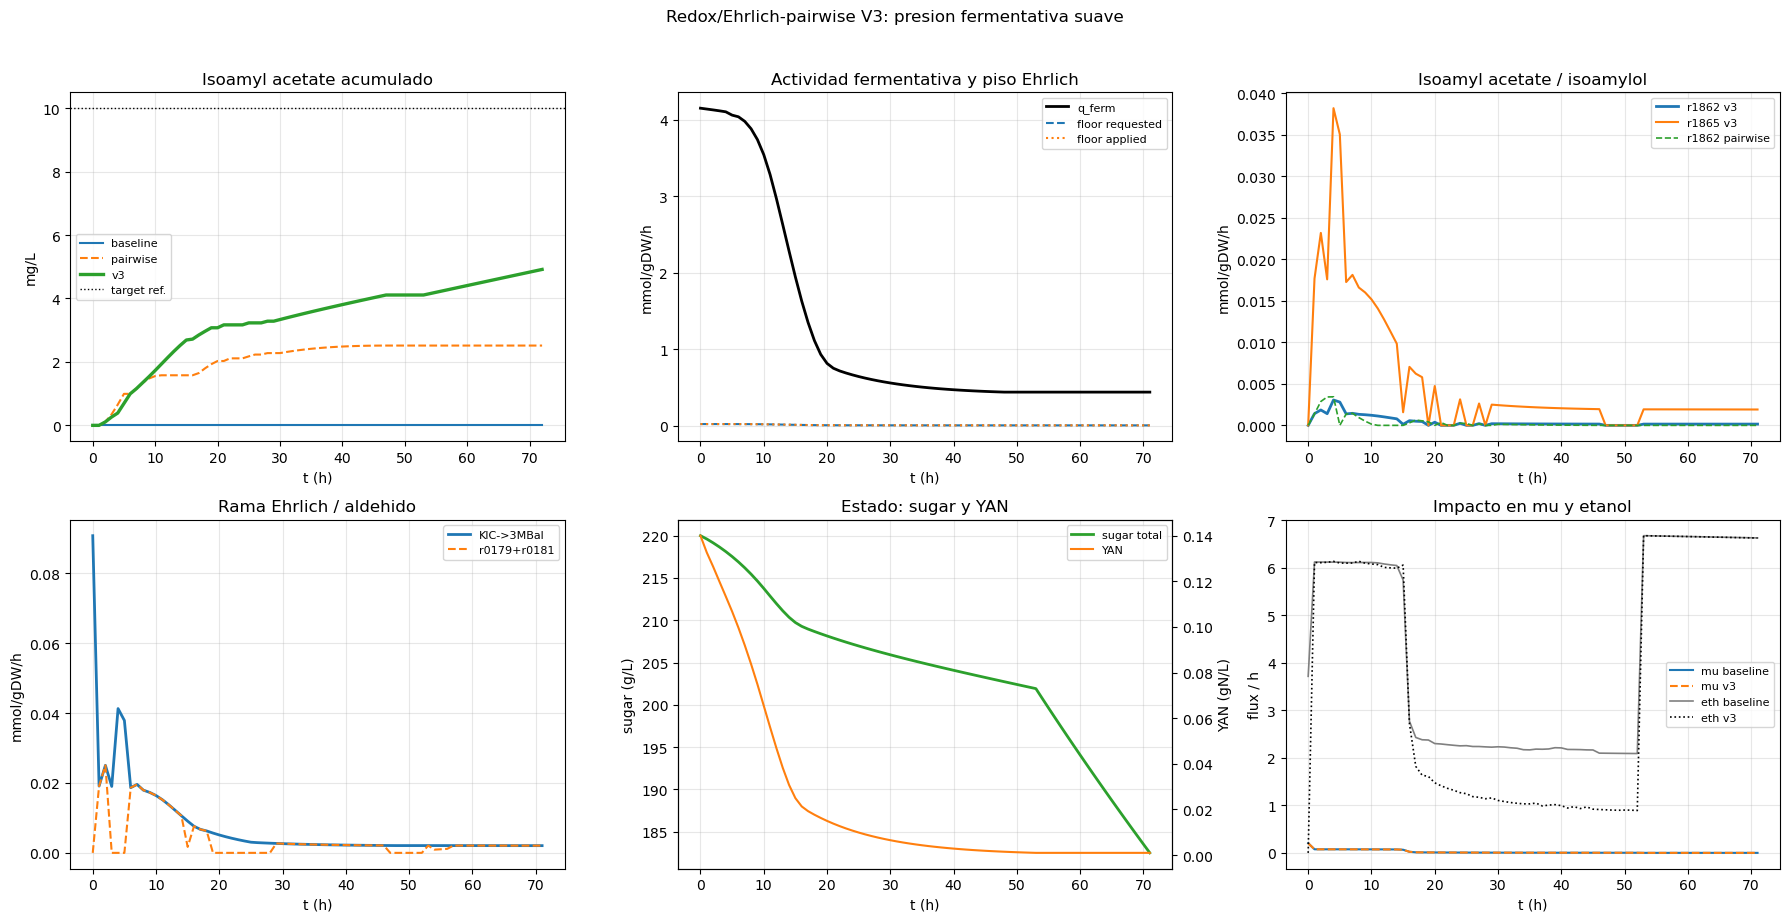


[Resumen redox-v3]


,n_snapshots,q_ferm_min,q_ferm_max,floor_requested_max,floor_applied_max,n_floor_applied,n_floor_relaxed,n_floor_omitted,floor_target_modes,v_r1865_max_v3,...,K_EHRLICH_SPILLOVER,K_SUGAR_G_L,K_YAN_GN_L,A_N_LOW,Q_FERM_DRIVER_MODE_V3,QFERM_SMOOTH_WINDOW_V3,QFERM_USE_MONOTONE_TAIL_V3,TARGET_ISOAC_FINAL_MG_L_V3,PHI_PAIR_V3,ENABLE_ADH_CAP_V3
0,72,0.437273,4.153033,0.019154,0.019154,72,0,0,kic_to_3mbal,0.038219,...,0.005,20.0,0.02,0.05,macro_sugar_derivative,9,True,10.0,0.08,False



[Archivos guardados]
  out\redox_v3_time_comparison_cell45_v3.csv
  out\redox_v3_concentration_cell45_v3.csv
  out\redox_v3_summary_cell45_v3.csv

Interpretacion automatica V3.1
  [CAL] final V3=4.92 mg/L; K sugerido para 10 mg/L: 1.017e-02
  [DIAG] r_1862 no inicia desde t=0; revisar target upstream o K_EHRLICH_SPILLOVER.
  [OK]   pairwise operativo: r1865_max=3.822e-02, r1862_max=3.057e-03.
  [OK]   impacto sobre mu dentro del umbral del 5%.
  [OK]   sin salto fuerte asociado a TURNOVER_ATPM segun criterio local.

[Variables disponibles]
  redox_v3_time_df
  redox_v3_conc_df
  redox_v3_summary_df
  snapshot_cache_v3
  _build_snapshot_redox_v3

OK: Redox/Ehrlich-pairwise V3.1 completado.


In [37]:
import math
import warnings
import numpy as np
import pandas as pd
import cobra
import matplotlib.pyplot as plt

# ======================================================================================
# Redox/Ehrlich-pairwise V3.1: presion fermentativa suavizada hacia isoamyl acetate
# Snapshot-level INCREMENTAL sobre pairwise/V2.
#
# Cambios vs V3:
#   1) q_ferm usa una envolvente suavizada desde d(azucar total)/dt/X cuando es posible.
#   2) La modulacion por YAN se vuelve leve para evitar boosts tardios artificiales.
#   3) El parametro de escala sube para llevar V3 al orden de magnitud ~10 mg/L.
#   4) NO se impone piso directo sobre r_1862.
# ======================================================================================

print("\n" + "=" * 100)
print("Redox/Ehrlich-pairwise V3.1: presion fermentativa suavizada hacia isoamyl acetate")
print("  [q_ferm suavizado -> Ehrlich upstream -> isoamylol -> isoamyl acetate]")
print("=" * 100)

# --------------------------------------------------------------------------------------
# A. Dependencias y parametros
# --------------------------------------------------------------------------------------

_required_v3 = [
    "model", "OUT_DIR", "states_df_phase", "flux_df_phase", "phase_meta_df",
    "_build_phase_snapshot_model", "ester_alcohol_pairwise_df",
    "_add_pairwise_ester_coupling_constraints", "OBJ_ID", "ETH_ID", "ZERO_TOL",
]
_missing_v3 = [s for s in _required_v3 if s not in globals()]
if _missing_v3:
    raise RuntimeError(f"[redox-v3] Faltan simbolos requeridos: {_missing_v3}")

ENABLE_PAIRWISE_IN_V3       = True
ENABLE_EHRLICH_FLOOR_V3     = True
ENABLE_ADH_CAP_V3           = False
SAVE_REDOX_V3_CSV           = True
CELL_TAG_V3                 = "cell45_v3"

# Escala: antes 1e-3. Subirla desplaza la curva acumulada sin cambiar la arquitectura.
K_EHRLICH_SPILLOVER         = 5e-3
K_SUGAR_G_L                 = 20.0
K_YAN_GN_L                  = 0.020
A_N_LOW                     = 0.05     # modulador leve; evita aumento tardio dominado por bajo YAN
PHI_PAIR_V3                 = 0.08
FLOOR_MIN_V3                = 1e-8
FLOOR_RELAX_FACTORS_V3      = [1.0, 0.5, 0.25]

# Driver fermentativo. macro_sugar_derivative evita que q_ferm dependa del objetivo
# BIOMASS/TURNOVER_ATPM; fallback a flujos si no hay estado macroscópico suficiente.
Q_FERM_DRIVER_MODE_V3       = "macro_sugar_derivative"  # "macro_sugar_derivative" | "flux"
MW_HEXOSE_G_PER_MMOL_V3     = 0.180156
QFERM_SMOOTH_WINDOW_V3      = 9
QFERM_USE_MONOTONE_TAIL_V3  = True
TARGET_ISOAC_FINAL_MG_L_V3  = 10.0
PLOT_INCLUDE_V2_REFERENCE   = False

# Hook opcional futuro. Mantener False al calibrar forma cinetica.
ADH_CAP_FACTOR_V3           = 0.95
ADH_CAP_ABS_V3              = np.inf
CAP_RELAX_FACTORS_V3        = [1.0, 1.25, 1.5]

RXN_ETH_EXCHANGE_V3         = globals().get("RXN_ETH_EXCHANGE", globals().get("ETH_ID", "r_1761"))
RXN_ADH_ETH_V3              = globals().get("RXN_ADH_ETH", "r_2115")
RXN_GLUCOSE_EXCHANGE_V3     = globals().get("GLU_ID", "r_1714")
RXN_FRUCTOSE_EXCHANGE_V3    = globals().get("FRU_ID", "r_1709")
RXN_ISOAMYL_ACETATE_EX_V3   = globals().get("RXN_ISOAMYL_ACETATE_EX", "r_1862")
RXN_ISOAMYLOL_EX_V3         = globals().get("RXN_ISOAMYLOL_EX", "r_1865")
RXN_ALDH_NADH_V3            = globals().get("RXN_ALDH_TO_ISOAMYLOL_NADH", "r_0179")
RXN_ALDH_NADPH_V3           = globals().get("RXN_ALDH_TO_ISOAMYLOL_NADPH", "r_0181")
RXN_ATF_ISOAMYL_V3          = globals().get("RXN_ATF_ISOAMYL", "r_0160")

MET_KIC_C_V3                = globals().get("MET_KIC_C", "s_0291")
MET_3METHYLBUTANAL_C_V3     = globals().get("MET_3METHYLBUTANAL_C", "s_0234")
MET_ISOAMYLOL_C_V3          = globals().get("MET_ISOAMYLOL_C", "s_0929")
MW_ISOAMYL_ACETATE_G_PER_MMOL_V3 = globals().get("MW_ISOAMYL_ACETATE_G_PER_MMOL", 0.130186)

print(f"ENABLE_EHRLICH_FLOOR_V3 = {ENABLE_EHRLICH_FLOOR_V3}")
print(f"ENABLE_ADH_CAP_V3       = {ENABLE_ADH_CAP_V3}")
print(f"K_EHRLICH_SPILLOVER     = {K_EHRLICH_SPILLOVER}")
print(f"K_SUGAR_G_L             = {K_SUGAR_G_L}")
print(f"K_YAN_GN_L              = {K_YAN_GN_L}")
print(f"A_N_LOW                 = {A_N_LOW}")
print(f"PHI_PAIR_V3             = {PHI_PAIR_V3}")

# --------------------------------------------------------------------------------------
# B. Utilidades
# --------------------------------------------------------------------------------------

def _read_state_v3(state_row, name):
    if hasattr(state_row, "index") and name in state_row.index:
        try:
            return float(state_row[name])
        except Exception:
            return np.nan
    return np.nan


def _read_sugar_total_v3(state_row):
    glu = np.nan
    for cand in ["G_g_L", "Glu_g_L", "glucose_g_L", "Glucose_g_L"]:
        v = _read_state_v3(state_row, cand)
        if np.isfinite(v):
            glu = v
            break

    fru = np.nan
    for cand in ["F_g_L", "Fru_g_L", "fructose_g_L", "Fructose_g_L"]:
        v = _read_state_v3(state_row, cand)
        if np.isfinite(v):
            fru = v
            break

    total, has_any = 0.0, False
    if np.isfinite(glu):
        total += glu
        has_any = True
    if np.isfinite(fru):
        total += fru
        has_any = True
    if not has_any:
        sg = _read_state_v3(state_row, "Sugar_g_L")
        if np.isfinite(sg):
            total, has_any = sg, True
    return (total if has_any else np.nan), glu, fru


def _rxn_present_v3(mtmp, rid):
    return rid is not None and rid in {r.id for r in mtmp.reactions}


def _flux_v3(sol, rid, tol=None):
    tol = ZERO_TOL if tol is None else tol
    if getattr(sol, "status", "") != "optimal" or rid is None:
        return np.nan
    try:
        v = float(sol.fluxes.get(rid, np.nan))
    except Exception:
        return np.nan
    return 0.0 if np.isfinite(v) and abs(v) < tol else v


def _infer_kic_to_3mbal_rxn_id(mtmp):
    """Detecta reaccion que consume KIC[c] y produce 3-methylbutanal[c]."""
    met_ids = {m.id for m in mtmp.metabolites}
    if MET_KIC_C_V3 not in met_ids or MET_3METHYLBUTANAL_C_V3 not in met_ids:
        return None
    kic = mtmp.metabolites.get_by_id(MET_KIC_C_V3)
    alde = mtmp.metabolites.get_by_id(MET_3METHYLBUTANAL_C_V3)
    candidates = []
    for rxn in mtmp.reactions:
        ck = rxn.metabolites.get(kic, 0.0)
        ca = rxn.metabolites.get(alde, 0.0)
        if ck < 0 and ca > 0:
            name_l = (rxn.name or "").lower()
            score = 10 * ("decarbox" in name_l) + 2 * ("methyl" in name_l or "oxo" in name_l)
            candidates.append((score, rxn.id))
    return sorted(candidates, reverse=True)[0][1] if candidates else None


RXN_KIC_TO_3MBAL_V3 = globals().get("RXN_KIC_TO_3MBAL", None)
if not _rxn_present_v3(model, RXN_KIC_TO_3MBAL_V3):
    RXN_KIC_TO_3MBAL_V3 = _infer_kic_to_3mbal_rxn_id(model)

print("\n[IDs V3]")
for label, rid in [
    ("RXN_GLUCOSE_EXCHANGE_V3", RXN_GLUCOSE_EXCHANGE_V3),
    ("RXN_FRUCTOSE_EXCHANGE_V3", RXN_FRUCTOSE_EXCHANGE_V3),
    ("RXN_ETH_EXCHANGE_V3", RXN_ETH_EXCHANGE_V3),
    ("RXN_ADH_ETH_V3", RXN_ADH_ETH_V3),
    ("RXN_KIC_TO_3MBAL_V3", RXN_KIC_TO_3MBAL_V3),
    ("RXN_ALDH_NADH_V3", RXN_ALDH_NADH_V3),
    ("RXN_ALDH_NADPH_V3", RXN_ALDH_NADPH_V3),
    ("RXN_ISOAMYLOL_EX_V3", RXN_ISOAMYLOL_EX_V3),
    ("RXN_ISOAMYL_ACETATE_EX_V3", RXN_ISOAMYL_ACETATE_EX_V3),
]:
    print(f"  {label:30s} = {str(rid):10s} [{'OK' if _rxn_present_v3(model, rid) else 'MISSING'}]")

if _rxn_present_v3(model, RXN_KIC_TO_3MBAL_V3):
    rx = model.reactions.get_by_id(RXN_KIC_TO_3MBAL_V3)
    print(f"\n[Upstream Ehrlich detectado] {rx.id} | {rx.name} | {rx.reaction}")
else:
    print("\n[WARN] No se detecto KIC -> 3-methylbutanal. V3 usara fallback r_0179+r_0181.")


def _build_ferm_activity_driver_v3(analysis_times):
    """Construye q_ferm desde -d(S_total)/dt/X y lo suaviza.

    Esto reduce artefactos por cambio de objetivo porque el driver viene de la
    trayectoria macroscópica, no de la solución LP instantánea.
    """
    rows = []
    for _, row in states_df_phase.sort_values("t_h").iterrows():
        s_total, glu, fru = _read_sugar_total_v3(row)
        x_val = _read_state_v3(row, "X_gDW_L")
        rows.append({"t_h": float(row["t_h"]), "S_total_g_L": s_total, "X_gDW_L": x_val})
    df = pd.DataFrame(rows).dropna(subset=["t_h", "S_total_g_L", "X_gDW_L"]).sort_values("t_h")
    df = df[df["X_gDW_L"] > 0].drop_duplicates("t_h")
    if len(df) < 3:
        return pd.DataFrame(columns=["t_h", "q_ferm_macro_raw", "q_ferm_macro_smooth"])

    t = df["t_h"].to_numpy(dtype=float)
    s = df["S_total_g_L"].to_numpy(dtype=float)
    x = df["X_gDW_L"].to_numpy(dtype=float)
    dSdt = np.gradient(s, t)
    with np.errstate(divide="ignore", invalid="ignore"):
        q_raw = np.maximum(0.0, -dSdt) / (MW_HEXOSE_G_PER_MMOL_V3 * x)

    q_smooth = pd.Series(q_raw).rolling(
        int(QFERM_SMOOTH_WINDOW_V3), center=True, min_periods=1
    ).mean().to_numpy(dtype=float)

    if QFERM_USE_MONOTONE_TAIL_V3 and np.isfinite(q_smooth).any():
        peak_idx = int(np.nanargmax(q_smooth))
        for i in range(peak_idx + 1, len(q_smooth)):
            if np.isfinite(q_smooth[i - 1]) and np.isfinite(q_smooth[i]):
                q_smooth[i] = min(q_smooth[i], q_smooth[i - 1])

    # Interpolar a tiempos de análisis para evitar lookup frágil por floats.
    q_interp = np.interp(
        np.asarray(analysis_times, dtype=float), t, q_smooth,
        left=q_smooth[0], right=q_smooth[-1],
    )
    return pd.DataFrame({
        "t_h": np.asarray(analysis_times, dtype=float),
        "q_ferm_macro_smooth": q_interp,
        "q_ferm_macro_raw_state_mean": float(np.nanmean(q_raw)),
        "q_ferm_macro_raw_state_max": float(np.nanmax(q_raw)),
    })


def _compute_q_flux_v3(sol_ref):
    """q_ferm desde solución LP: uptake glucosa+fructosa, fallback etanol."""
    if getattr(sol_ref, "status", "") != "optimal":
        return np.nan, "none", np.nan, np.nan, np.nan

    v_glu = _flux_v3(sol_ref, RXN_GLUCOSE_EXCHANGE_V3)
    v_fru = _flux_v3(sol_ref, RXN_FRUCTOSE_EXCHANGE_V3)
    q_sugar = 0.0
    has_sugar_flux = False
    if np.isfinite(v_glu):
        q_sugar += abs(min(0.0, v_glu))
        has_sugar_flux = True
    if np.isfinite(v_fru):
        q_sugar += abs(min(0.0, v_fru))
        has_sugar_flux = True
    if has_sugar_flux and q_sugar > ZERO_TOL:
        return float(q_sugar), "sugar_uptake_flux", v_glu, v_fru, _flux_v3(sol_ref, RXN_ETH_EXCHANGE_V3)

    v_eth = _flux_v3(sol_ref, RXN_ETH_EXCHANGE_V3)
    if np.isfinite(v_eth):
        return float(abs(v_eth)), "ethanol_exchange_flux", v_glu, v_fru, v_eth
    return np.nan, "none", v_glu, v_fru, v_eth


def _compute_q_ferm_v3(sol_ref, t_phase=None):
    q_flux, q_flux_source, v_glu, v_fru, v_eth = _compute_q_flux_v3(sol_ref)
    q_macro = np.nan
    if (
        Q_FERM_DRIVER_MODE_V3 == "macro_sugar_derivative"
        and "FERM_ACTIVITY_DRIVER_V3_DF" in globals()
        and not FERM_ACTIVITY_DRIVER_V3_DF.empty
        and t_phase is not None
    ):
        arr_t = FERM_ACTIVITY_DRIVER_V3_DF["t_h"].to_numpy(dtype=float)
        arr_q = FERM_ACTIVITY_DRIVER_V3_DF["q_ferm_macro_smooth"].to_numpy(dtype=float)
        q_macro = float(np.interp(float(t_phase), arr_t, arr_q))
        if np.isfinite(q_macro) and q_macro > ZERO_TOL:
            return q_macro, "macro_sugar_derivative_smooth", v_glu, v_fru, v_eth, q_flux, q_macro

    return q_flux, q_flux_source, v_glu, v_fru, v_eth, q_flux, q_macro


def _compute_ehrlich_floor_v3(sol_ref, state_row, t_phase=None):
    q_ferm, q_source, v_glu, v_fru, v_eth, q_flux, q_macro = _compute_q_ferm_v3(sol_ref, t_phase)
    sugar_total, glu_g_l, fru_g_l = _read_sugar_total_v3(state_row)
    yan = _read_state_v3(state_row, "N_gN_L")

    if np.isfinite(sugar_total) and sugar_total > 0:
        f_sugar = sugar_total / (K_SUGAR_G_L + sugar_total)
    else:
        f_sugar = 1.0 if np.isfinite(q_ferm) and q_ferm > ZERO_TOL else 0.0

    if np.isfinite(yan) and yan >= 0:
        f_n = 1.0 + A_N_LOW * K_YAN_GN_L / (K_YAN_GN_L + max(yan, 1e-12))
    else:
        f_n = 1.0

    floor = K_EHRLICH_SPILLOVER * q_ferm * f_sugar * f_n if np.isfinite(q_ferm) else 0.0
    floor = 0.0 if floor < FLOOR_MIN_V3 else float(floor)
    return {
        "q_ferm": float(q_ferm) if np.isfinite(q_ferm) else np.nan,
        "q_ferm_source": q_source,
        "q_ferm_flux": q_flux,
        "q_ferm_macro": q_macro,
        "v_glucose_baseline": v_glu,
        "v_fructose_baseline": v_fru,
        "v_eth_baseline": v_eth,
        "S_total_g_L": sugar_total,
        "glucose_g_L": glu_g_l,
        "fructose_g_L": fru_g_l,
        "N_gN_L": yan,
        "f_sugar": float(f_sugar),
        "f_N": float(f_n),
        "v_ehrlich_floor_requested": floor,
    }

# --------------------------------------------------------------------------------------
# C. Restricciones y wrapper snapshot
# --------------------------------------------------------------------------------------

def _add_ehrlich_floor_v3(mtmp, floor_value, name_suffix):
    rxn_set = {r.id for r in mtmp.reactions}
    if _rxn_present_v3(mtmp, RXN_KIC_TO_3MBAL_V3):
        rxn = mtmp.reactions.get_by_id(RXN_KIC_TO_3MBAL_V3)
        cons = mtmp.problem.Constraint(
            rxn.flux_expression,
            lb=float(floor_value),
            name=f"v3_kic_to_3mbal_floor_{name_suffix}",
        )
        mtmp.add_cons_vars([cons])
        return "kic_to_3mbal", RXN_KIC_TO_3MBAL_V3

    if RXN_ALDH_NADH_V3 in rxn_set and RXN_ALDH_NADPH_V3 in rxn_set:
        r1 = mtmp.reactions.get_by_id(RXN_ALDH_NADH_V3)
        r2 = mtmp.reactions.get_by_id(RXN_ALDH_NADPH_V3)
        cons = mtmp.problem.Constraint(
            r1.flux_expression + r2.flux_expression,
            lb=float(floor_value),
            name=f"v3_aldh_floor_{name_suffix}",
        )
        mtmp.add_cons_vars([cons])
        return "aldh_to_isoamylol_fallback", f"{RXN_ALDH_NADH_V3}+{RXN_ALDH_NADPH_V3}"

    raise RuntimeError("No hay target disponible para floor V3.")


def _apply_adh_cap_v3(mtmp, sol_ref):
    info = {"cap_active": False, "cap_applied": np.nan, "cap_relaxed": False, "cap_omitted": False}
    if not ENABLE_ADH_CAP_V3:
        return info
    target = RXN_ADH_ETH_V3 if _rxn_present_v3(mtmp, RXN_ADH_ETH_V3) else RXN_ETH_EXCHANGE_V3
    if not _rxn_present_v3(mtmp, target):
        info["cap_omitted"] = True
        return info
    v_base = abs(_flux_v3(sol_ref, target))
    if not np.isfinite(v_base) or v_base <= FLOOR_MIN_V3:
        return info
    rxn = mtmp.reactions.get_by_id(target)
    old_ub = float(rxn.upper_bound)
    base_cap = min(ADH_CAP_FACTOR_V3 * v_base, ADH_CAP_ABS_V3)
    for fac in CAP_RELAX_FACTORS_V3:
        rxn.upper_bound = min(old_ub, base_cap * fac)
        sol = mtmp.optimize()
        if getattr(sol, "status", "") == "optimal":
            info.update({"cap_active": True, "cap_applied": rxn.upper_bound, "cap_relaxed": fac != 1.0})
            return info
    rxn.upper_bound = old_ub
    info["cap_omitted"] = True
    return info


def _solve_with_floor_v3(mtmp, floor_requested, name_suffix):
    info = {
        "floor_target_mode": "none",
        "floor_target_id": None,
        "v_ehrlich_floor_requested": float(floor_requested),
        "v_ehrlich_floor_applied": 0.0,
        "floor_relaxed": False,
        "floor_omitted": False,
    }
    if (not ENABLE_EHRLICH_FLOOR_V3) or floor_requested <= FLOOR_MIN_V3:
        return mtmp.optimize(), info, mtmp

    for fac in FLOOR_RELAX_FACTORS_V3:
        m_try = mtmp.copy()
        floor_try = float(floor_requested) * float(fac)
        try:
            mode, target_id = _add_ehrlich_floor_v3(m_try, floor_try, name_suffix)
            sol = m_try.optimize()
            status = getattr(sol, "status", "unknown")
        except Exception as exc:
            status = f"error:{exc}"
            sol = None
            mode, target_id = "error", None
        if status == "optimal":
            info.update({
                "floor_target_mode": mode,
                "floor_target_id": target_id,
                "v_ehrlich_floor_applied": floor_try,
                "floor_relaxed": bool(fac != 1.0),
            })
            return sol, info, m_try

    warnings.warn(f"[redox-v3] floor inviable en t={name_suffix}; se omite.")
    info["floor_omitted"] = True
    return mtmp.optimize(), info, mtmp


def _build_snapshot_redox_v3(t_phase, pairwise_df=None, phi_pair=None):
    snap = _build_phase_snapshot_model(float(t_phase))
    m_base, sol_base = snap["model"], snap["solution"]
    state_row, mode_str, objective_id = snap["state_row"], snap["mode"], snap["objective_id"]

    phi_use = PHI_PAIR_V3 if phi_pair is None else float(phi_pair)
    m_pair = m_base.copy()
    sol_pair = sol_base
    if ENABLE_PAIRWISE_IN_V3 and pairwise_df is not None and not pairwise_df.empty:
        pwdf = pairwise_df.copy()
        if "phi_pair" in pwdf.columns:
            pwdf.loc[pwdf["pair_active"] == True, "phi_pair"] = phi_use
        _add_pairwise_ester_coupling_constraints(m_pair, pwdf)
        sol_pair = m_pair.optimize()

    m_work = m_pair.copy()
    cap_info = _apply_adh_cap_v3(m_work, sol_base)
    floor_calc = _compute_ehrlich_floor_v3(sol_base, state_row, t_phase=float(t_phase))
    sol_v3, floor_info, m_v3 = _solve_with_floor_v3(
        m_work,
        floor_calc["v_ehrlich_floor_requested"],
        str(float(t_phase)).replace(".", "p"),
    )

    return {
        "t_h": float(t_phase),
        "mode": mode_str,
        "objective_id": objective_id,
        "state_row": state_row,
        "model_baseline": m_base,
        "model_pairwise": m_pair,
        "model_v3": m_v3,
        "solution_baseline": sol_base,
        "solution_pairwise": sol_pair,
        "solution_v3": sol_v3,
        "floor_calc": floor_calc,
        "floor_info": floor_info,
        "cap_info": cap_info,
    }

# --------------------------------------------------------------------------------------
# D. Ejecutar trayectoria snapshot-level
# --------------------------------------------------------------------------------------

analysis_times_v3 = flux_df_phase["t_h"].to_numpy(dtype=float)
state_times_v3 = states_df_phase["t_h"].to_numpy(dtype=float)
FERM_ACTIVITY_DRIVER_V3_DF = _build_ferm_activity_driver_v3(analysis_times_v3)
if not FERM_ACTIVITY_DRIVER_V3_DF.empty:
    print("\n[Driver q_ferm V3.1] usando macro_sugar_derivative_smooth")
    display(FERM_ACTIVITY_DRIVER_V3_DF.head())
else:
    print("\n[Driver q_ferm V3.1] sin driver macro; fallback a flujos LP")

snapshot_cache_v3 = {}
rows_v3 = []

for k_t, t_k in enumerate(analysis_times_v3):
    if k_t % 10 == 0:
        print(f"[V3] snapshot {k_t + 1}/{len(analysis_times_v3)} | t={float(t_k):.3g} h")
    res = _build_snapshot_redox_v3(
        t_k,
        pairwise_df=ester_alcohol_pairwise_df,
        phi_pair=PHI_PAIR_V3,
    )
    snapshot_cache_v3[float(t_k)] = {
        "model_baseline": res["model_baseline"],
        "model_pairwise": res["model_pairwise"],
        "model_v3": res["model_v3"],
        "solution_baseline": res["solution_baseline"],
        "solution_pairwise": res["solution_pairwise"],
        "solution_v3": res["solution_v3"],
    }

    sol_b, sol_pw, sol_v3 = res["solution_baseline"], res["solution_pairwise"], res["solution_v3"]
    fc, fi, ci = res["floor_calc"], res["floor_info"], res["cap_info"]
    obj_id = res["objective_id"]

    v_aldh_sum = np.nansum([_flux_v3(sol_v3, RXN_ALDH_NADH_V3), _flux_v3(sol_v3, RXN_ALDH_NADPH_V3)])
    if np.isnan(_flux_v3(sol_v3, RXN_ALDH_NADH_V3)) and np.isnan(_flux_v3(sol_v3, RXN_ALDH_NADPH_V3)):
        v_aldh_sum = np.nan

    rows_v3.append({
        "t_h": float(t_k),
        "mode": res["mode"],
        "q_ferm": fc["q_ferm"],
        "q_ferm_source": fc["q_ferm_source"],
        "q_ferm_flux": fc.get("q_ferm_flux", np.nan),
        "q_ferm_macro": fc.get("q_ferm_macro", np.nan),
        "S_total_g_L": fc["S_total_g_L"],
        "glucose_g_L": fc["glucose_g_L"],
        "fructose_g_L": fc["fructose_g_L"],
        "N_gN_L": fc["N_gN_L"],
        "f_sugar": fc["f_sugar"],
        "f_N": fc["f_N"],
        "v_ehrlich_floor_requested": fi["v_ehrlich_floor_requested"],
        "v_ehrlich_floor_applied": fi["v_ehrlich_floor_applied"],
        "floor_target_mode": fi["floor_target_mode"],
        "floor_target_id": fi["floor_target_id"],
        "floor_relaxed": fi["floor_relaxed"],
        "floor_omitted": fi["floor_omitted"],
        "cap_active": ci["cap_active"],
        "cap_applied": ci["cap_applied"],
        "cap_relaxed": ci["cap_relaxed"],
        "cap_omitted": ci["cap_omitted"],
        "status_baseline": getattr(sol_b, "status", "unknown"),
        "status_pairwise": getattr(sol_pw, "status", "unknown"),
        "status_v3": getattr(sol_v3, "status", "unknown"),
        "objective_id": obj_id,
        "obj_baseline": _flux_v3(sol_b, obj_id),
        "obj_v3": _flux_v3(sol_v3, obj_id),
        "mu_baseline": _flux_v3(sol_b, OBJ_ID),
        "mu_v3": _flux_v3(sol_v3, OBJ_ID),
        "v_glucose_baseline": fc["v_glucose_baseline"],
        "v_fructose_baseline": fc["v_fructose_baseline"],
        "v_eth_baseline": fc["v_eth_baseline"],
        "v_eth_v3": _flux_v3(sol_v3, RXN_ETH_EXCHANGE_V3),
        "v_ADH_v3": _flux_v3(sol_v3, RXN_ADH_ETH_V3),
        "v_ehrlich_decarb_v3": _flux_v3(sol_v3, RXN_KIC_TO_3MBAL_V3),
        "v_r0179_v3": _flux_v3(sol_v3, RXN_ALDH_NADH_V3),
        "v_r0181_v3": _flux_v3(sol_v3, RXN_ALDH_NADPH_V3),
        "v_aldh_sum_v3": v_aldh_sum,
        "v_r1865_v3": _flux_v3(sol_v3, RXN_ISOAMYLOL_EX_V3),
        "v_r1862_v3": _flux_v3(sol_v3, RXN_ISOAMYL_ACETATE_EX_V3),
        "v_r1862_pairwise": _flux_v3(sol_pw, RXN_ISOAMYL_ACETATE_EX_V3),
        "v_r1865_pairwise": _flux_v3(sol_pw, RXN_ISOAMYLOL_EX_V3),
        "v_r1862_baseline": _flux_v3(sol_b, RXN_ISOAMYL_ACETATE_EX_V3),
        "v_r1865_baseline": _flux_v3(sol_b, RXN_ISOAMYLOL_EX_V3),
    })

redox_v3_time_df = pd.DataFrame(rows_v3)

print("\n[Comparativa V3 por tiempo]")
_show_v3 = [
    "t_h", "mode", "q_ferm", "q_ferm_source", "q_ferm_flux", "q_ferm_macro", "S_total_g_L", "N_gN_L",
    "f_sugar", "f_N", "v_ehrlich_floor_requested", "v_ehrlich_floor_applied",
    "floor_target_mode", "floor_relaxed", "floor_omitted",
    "mu_baseline", "mu_v3", "v_eth_baseline", "v_eth_v3",
    "v_ehrlich_decarb_v3", "v_aldh_sum_v3", "v_r1865_v3", "v_r1862_v3",
]
display(redox_v3_time_df[[c for c in _show_v3 if c in redox_v3_time_df.columns]].head(20))

# --------------------------------------------------------------------------------------
# E. Concentracion acumulada de isoamyl acetate
# --------------------------------------------------------------------------------------

c_iso_baseline_v3 = np.zeros(len(state_times_v3), dtype=float)
c_iso_pairwise_v3 = np.zeros(len(state_times_v3), dtype=float)
c_iso_v3 = np.zeros(len(state_times_v3), dtype=float)

for k_c, t_kc in enumerate(analysis_times_v3):
    if k_c + 1 >= len(state_times_v3):
        break
    dt_kc = float(state_times_v3[k_c + 1] - state_times_v3[k_c])
    row_state = states_df_phase.loc[states_df_phase["t_h"] == float(t_kc)]
    if row_state.empty:
        c_iso_baseline_v3[k_c + 1] = c_iso_baseline_v3[k_c]
        c_iso_pairwise_v3[k_c + 1] = c_iso_pairwise_v3[k_c]
        c_iso_v3[k_c + 1] = c_iso_v3[k_c]
        continue
    Xk = float(row_state.iloc[0]["X_gDW_L"]) if "X_gDW_L" in row_state.columns else 0.0
    rdf = redox_v3_time_df[redox_v3_time_df["t_h"] == float(t_kc)]
    if rdf.empty:
        continue
    rr = rdf.iloc[0]
    fac = 1000.0 * MW_ISOAMYL_ACETATE_G_PER_MMOL_V3 * Xk * dt_kc
    c_iso_baseline_v3[k_c + 1] = c_iso_baseline_v3[k_c] + fac * max(0.0, float(rr.get("v_r1862_baseline", 0.0) or 0.0))
    c_iso_pairwise_v3[k_c + 1] = c_iso_pairwise_v3[k_c] + fac * max(0.0, float(rr.get("v_r1862_pairwise", 0.0) or 0.0))
    c_iso_v3[k_c + 1] = c_iso_v3[k_c] + fac * max(0.0, float(rr.get("v_r1862_v3", 0.0) or 0.0))

redox_v3_conc_df = pd.DataFrame({
    "t_h": state_times_v3,
    "isoamyl_acetate_baseline_mg_L": c_iso_baseline_v3,
    "isoamyl_acetate_pairwise_mg_L": c_iso_pairwise_v3,
    "isoamyl_acetate_v3_mg_L": c_iso_v3,
})
redox_v3_conc_df["delta_v3_vs_baseline_mg_L"] = (
    redox_v3_conc_df["isoamyl_acetate_v3_mg_L"]
    - redox_v3_conc_df["isoamyl_acetate_baseline_mg_L"]
)

print("\n[Concentracion acumulada isoamyl acetate V3]")
display(redox_v3_conc_df.tail(10))

# --------------------------------------------------------------------------------------
# F. Graficos
# --------------------------------------------------------------------------------------

fig, ax = plt.subplots(2, 3, figsize=(18, 9), sharex=False)

ax[0, 0].plot(redox_v3_conc_df["t_h"], redox_v3_conc_df["isoamyl_acetate_baseline_mg_L"], lw=1.5, label="baseline")
ax[0, 0].plot(redox_v3_conc_df["t_h"], redox_v3_conc_df["isoamyl_acetate_pairwise_mg_L"], lw=1.5, ls="--", label="pairwise")
if PLOT_INCLUDE_V2_REFERENCE and "redox_v2_conc_df" in globals() and "isoamyl_acetate_redox_v2_mg_L" in redox_v2_conc_df.columns:
    ax[0, 0].plot(redox_v2_conc_df["t_h"], redox_v2_conc_df["isoamyl_acetate_redox_v2_mg_L"], lw=1.2, ls=":", label="v2")
ax[0, 0].plot(redox_v3_conc_df["t_h"], redox_v3_conc_df["isoamyl_acetate_v3_mg_L"], lw=2.4, label="v3")
if np.isfinite(TARGET_ISOAC_FINAL_MG_L_V3):
    ax[0, 0].axhline(TARGET_ISOAC_FINAL_MG_L_V3, lw=1.0, ls=":", color="black", label="target ref.")
ax[0, 0].set_title("Isoamyl acetate acumulado")
ax[0, 0].set_xlabel("t (h)")
ax[0, 0].set_ylabel("mg/L")
ax[0, 0].grid(alpha=0.3)
ax[0, 0].legend(fontsize=8)

ax[0, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df["q_ferm"], lw=2, label="q_ferm", color="black")
ax[0, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_ehrlich_floor_requested"], lw=1.5, ls="--", label="floor requested")
ax[0, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_ehrlich_floor_applied"], lw=1.5, ls=":", label="floor applied")
ax[0, 1].set_title("Actividad fermentativa y piso Ehrlich")
ax[0, 1].set_xlabel("t (h)")
ax[0, 1].set_ylabel("mmol/gDW/h")
ax[0, 1].grid(alpha=0.3)
ax[0, 1].legend(fontsize=8)

ax[0, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_r1862_v3"], lw=2, label="r1862 v3")
ax[0, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_r1865_v3"], lw=1.5, label="r1865 v3")
ax[0, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_r1862_pairwise"], lw=1.2, ls="--", label="r1862 pairwise")
ax[0, 2].set_title("Isoamyl acetate / isoamylol")
ax[0, 2].set_xlabel("t (h)")
ax[0, 2].set_ylabel("mmol/gDW/h")
ax[0, 2].grid(alpha=0.3)
ax[0, 2].legend(fontsize=8)

ax[1, 0].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_ehrlich_decarb_v3"], lw=2, label="KIC->3MBal")
ax[1, 0].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_aldh_sum_v3"], lw=1.5, ls="--", label="r0179+r0181")
ax[1, 0].set_title("Rama Ehrlich / aldehido")
ax[1, 0].set_xlabel("t (h)")
ax[1, 0].set_ylabel("mmol/gDW/h")
ax[1, 0].grid(alpha=0.3)
ax[1, 0].legend(fontsize=8)

ax[1, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df["S_total_g_L"], lw=2, label="sugar total", color="tab:green")
ax2 = ax[1, 1].twinx()
ax2.plot(redox_v3_time_df["t_h"], redox_v3_time_df["N_gN_L"], lw=1.5, label="YAN", color="tab:orange")
ax[1, 1].set_title("Estado: sugar y YAN")
ax[1, 1].set_xlabel("t (h)")
ax[1, 1].set_ylabel("sugar (g/L)")
ax2.set_ylabel("YAN (gN/L)")
ax[1, 1].grid(alpha=0.3)
lines1, labels1 = ax[1, 1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax[1, 1].legend(lines1 + lines2, labels1 + labels2, fontsize=8)

ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["mu_baseline"], lw=1.5, label="mu baseline")
ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["mu_v3"], lw=1.5, ls="--", label="mu v3")
ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_eth_baseline"], lw=1.2, label="eth baseline", color="gray")
ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_eth_v3"], lw=1.2, ls=":", label="eth v3", color="black")
ax[1, 2].set_title("Impacto en mu y etanol")
ax[1, 2].set_xlabel("t (h)")
ax[1, 2].set_ylabel("flux / h")
ax[1, 2].grid(alpha=0.3)
ax[1, 2].legend(fontsize=8)

plt.suptitle("Redox/Ehrlich-pairwise V3: presion fermentativa suave", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------------------
# G. Resumen, guardado e interpretacion
# --------------------------------------------------------------------------------------

_v1862_max_v3 = float(redox_v3_time_df["v_r1862_v3"].abs().max())
_v1865_max_v3 = float(redox_v3_time_df["v_r1865_v3"].abs().max())
_floor_nonzero = int((redox_v3_time_df["v_ehrlich_floor_applied"] > FLOOR_MIN_V3).sum())
_mu_drop = (redox_v3_time_df["mu_baseline"] - redox_v3_time_df["mu_v3"]).abs().max()
_mu_max_b = redox_v3_time_df["mu_baseline"].abs().max()

redox_v3_summary_df = pd.DataFrame([{
    "n_snapshots": int(len(redox_v3_time_df)),
    "q_ferm_min": float(redox_v3_time_df["q_ferm"].min()),
    "q_ferm_max": float(redox_v3_time_df["q_ferm"].max()),
    "floor_requested_max": float(redox_v3_time_df["v_ehrlich_floor_requested"].max()),
    "floor_applied_max": float(redox_v3_time_df["v_ehrlich_floor_applied"].max()),
    "n_floor_applied": _floor_nonzero,
    "n_floor_relaxed": int(redox_v3_time_df["floor_relaxed"].sum()),
    "n_floor_omitted": int(redox_v3_time_df["floor_omitted"].sum()),
    "floor_target_modes": ",".join(sorted(set(map(str, redox_v3_time_df["floor_target_mode"].dropna())))),
    "v_r1865_max_v3": _v1865_max_v3,
    "v_r1862_max_v3": _v1862_max_v3,
    "mu_drop_max_abs": float(_mu_drop) if np.isfinite(_mu_drop) else np.nan,
    "iso_ac_final_baseline_mg_L": float(redox_v3_conc_df["isoamyl_acetate_baseline_mg_L"].iloc[-1]),
    "iso_ac_final_pairwise_mg_L": float(redox_v3_conc_df["isoamyl_acetate_pairwise_mg_L"].iloc[-1]),
    "iso_ac_final_v3_mg_L": float(redox_v3_conc_df["isoamyl_acetate_v3_mg_L"].iloc[-1]),
    "K_EHRLICH_SPILLOVER": K_EHRLICH_SPILLOVER,
    "K_SUGAR_G_L": K_SUGAR_G_L,
    "K_YAN_GN_L": K_YAN_GN_L,
    "A_N_LOW": A_N_LOW,
    "Q_FERM_DRIVER_MODE_V3": Q_FERM_DRIVER_MODE_V3,
    "QFERM_SMOOTH_WINDOW_V3": QFERM_SMOOTH_WINDOW_V3,
    "QFERM_USE_MONOTONE_TAIL_V3": QFERM_USE_MONOTONE_TAIL_V3,
    "TARGET_ISOAC_FINAL_MG_L_V3": TARGET_ISOAC_FINAL_MG_L_V3,
    "PHI_PAIR_V3": PHI_PAIR_V3,
    "ENABLE_ADH_CAP_V3": ENABLE_ADH_CAP_V3,
}])

print("\n[Resumen redox-v3]")
display(redox_v3_summary_df)

if SAVE_REDOX_V3_CSV:
    f_time = OUT_DIR / f"redox_v3_time_comparison_{CELL_TAG_V3}.csv"
    f_conc = OUT_DIR / f"redox_v3_concentration_{CELL_TAG_V3}.csv"
    f_sum = OUT_DIR / f"redox_v3_summary_{CELL_TAG_V3}.csv"
    redox_v3_time_df.to_csv(f_time, index=False)
    redox_v3_conc_df.to_csv(f_conc, index=False)
    redox_v3_summary_df.to_csv(f_sum, index=False)
    print("\n[Archivos guardados]")
    print(f"  {f_time}")
    print(f"  {f_conc}")
    print(f"  {f_sum}")

print("\n" + "=" * 100)
print("Interpretacion automatica V3.1")
print("=" * 100)
_final_v3 = float(redox_v3_conc_df["isoamyl_acetate_v3_mg_L"].iloc[-1])
if np.isfinite(_final_v3) and _final_v3 > 0 and np.isfinite(TARGET_ISOAC_FINAL_MG_L_V3):
    _k_suggest = K_EHRLICH_SPILLOVER * TARGET_ISOAC_FINAL_MG_L_V3 / _final_v3
    print(f"  [CAL] final V3={_final_v3:.3g} mg/L; K sugerido para {TARGET_ISOAC_FINAL_MG_L_V3:g} mg/L: {_k_suggest:.3e}")

first = redox_v3_time_df.iloc[0]
if float(first.get("v_r1862_v3", 0.0) or 0.0) > ZERO_TOL:
    print(f"  [OK]   r_1862 inicia desde t=0: {first['v_r1862_v3']:.3e} mmol/gDW/h.")
else:
    print("  [DIAG] r_1862 no inicia desde t=0; revisar target upstream o K_EHRLICH_SPILLOVER.")

if _v1865_max_v3 > ZERO_TOL and _v1862_max_v3 > ZERO_TOL:
    print(f"  [OK]   pairwise operativo: r1865_max={_v1865_max_v3:.3e}, r1862_max={_v1862_max_v3:.3e}.")
else:
    print("  [DIAG] la rama isoamyl sigue sin activarse en V3.")

if int(redox_v3_time_df["floor_omitted"].sum()) > 0:
    print(f"  [WARN] floor omitido en {int(redox_v3_time_df['floor_omitted'].sum())} snapshots.")
if int(redox_v3_time_df["floor_relaxed"].sum()) > 0:
    print(f"  [WARN] floor relajado en {int(redox_v3_time_df['floor_relaxed'].sum())} snapshots.")

if np.isfinite(_mu_drop) and np.isfinite(_mu_max_b) and _mu_max_b > 0 and _mu_drop > 0.05 * _mu_max_b:
    print(f"  [WARN] caida importante en mu ({_mu_drop:.3e}); K_EHRLICH_SPILLOVER puede ser agresivo.")
else:
    print("  [OK]   impacto sobre mu dentro del umbral del 5%.")

turn_mask = redox_v3_time_df["mode"].astype(str).str.contains("TURNOVER_ATPM", case=False, na=False)
if turn_mask.any():
    t0_turn = float(redox_v3_time_df.loc[turn_mask, "t_h"].iloc[0])
    before = redox_v3_time_df.loc[redox_v3_time_df["t_h"] < t0_turn, "v_r1862_v3"].tail(3).mean()
    after = redox_v3_time_df.loc[redox_v3_time_df["t_h"] >= t0_turn, "v_r1862_v3"].head(3).mean()
    if np.isfinite(before) and np.isfinite(after) and before > ZERO_TOL and after / before > 2.0:
        print(f"  [WARN] aun hay salto >2x al entrar TURNOVER_ATPM (t~{t0_turn:g} h).")
    else:
        print("  [OK]   sin salto fuerte asociado a TURNOVER_ATPM segun criterio local.")

print("\n[Variables disponibles]")
for vn in ["redox_v3_time_df", "redox_v3_conc_df", "redox_v3_summary_df", "snapshot_cache_v3", "_build_snapshot_redox_v3"]:
    print(f"  {vn}")

print("\n" + "=" * 100)
print("OK: Redox/Ehrlich-pairwise V3.1 completado.")
print("=" * 100)





Redox/Ehrlich-pairwise V3.2: presion fermentativa suavizada hacia isoamyl acetate
  [q_ferm suavizado + beta/gamma aldehido -> isoamylol -> isoamyl acetate]
ENABLE_EHRLICH_FLOOR_V3 = True
ENABLE_ADH_CAP_V3       = False
K_EHRLICH_SPILLOVER     = 0.005
K_SUGAR_G_L             = 20.0
K_YAN_GN_L              = 0.02
A_N_LOW                 = 0.05
PHI_PAIR_V3             = 0.08
ENABLE_ATPM_FREE_BIOMASS_V32 = True
RXN_ATPM_V3                  = r_4046
ATPM_GROWTH_LB_V32           = 0.7
ATPM_GROWTH_UB_V32           = 1000.0
ENABLE_ALDH_BRANCH_COUPLING_V32    = True
BETA_ALDH_TO_ALCOHOL_V32           = 0.2
ENABLE_ALDEHYDE_TRANSPORT_CAP_V32  = True
GAMMA_ALDEHYDE_TRANSPORT_V32       = 0.2

[IDs V3]
  RXN_GLUCOSE_EXCHANGE_V3        = r_1714     [OK]
  RXN_FRUCTOSE_EXCHANGE_V3       = r_1709     [OK]
  RXN_ETH_EXCHANGE_V3            = r_1761     [OK]
  RXN_ADH_ETH_V3                 = r_2115     [OK]
  RXN_KIC_TO_3MBAL_V3            = r_0072     [OK]
  RXN_ALDH_NADH_V3               = r_0179    

,t_h,q_ferm_macro_smooth,q_ferm_macro_raw_state_mean,q_ferm_macro_raw_state_max
0,0.0,4.153033,1.844435,4.351019
1,1.0,4.141821,1.844435,4.351019
2,2.0,4.130532,1.844435,4.351019
3,3.0,4.118609,1.844435,4.351019
4,4.0,4.105612,1.844435,4.351019


[V3] snapshot 1/72 | t=0 h
[V3] snapshot 11/72 | t=10 h
[V3] snapshot 21/72 | t=20 h
[V3] snapshot 31/72 | t=30 h
[V3] snapshot 41/72 | t=40 h
[V3] snapshot 51/72 | t=50 h
[V3] snapshot 61/72 | t=60 h
[V3] snapshot 71/72 | t=70 h

[Comparativa V3 por tiempo]


,t_h,mode,q_ferm,q_ferm_source,q_ferm_flux,q_ferm_macro,S_total_g_L,N_gN_L,f_sugar,f_N,...,v_ATPM_v3,mu_baseline,mu_v3,v_eth_baseline,v_eth_v3,v_ehrlich_decarb_v3,v_aldh_sum_v3,v_aldehyde_transport_sum_v3,v_r1865_v3,v_r1862_v3
0,0.0,BIOMASS,4.153033,macro_sugar_derivative_smooth,3.337031,4.153033,220.000000,0.140000,0.916667,1.006250,...,0.7,0.203195,0.203195,3.713020,0.000000,0.090739,0.072591,0.018148,0.067214,0.005377
1,1.0,BIOMASS,4.141821,macro_sugar_derivative_smooth,3.336669,4.141821,219.608069,0.132621,0.916530,1.006552,...,0.7,0.074993,0.074872,6.117207,6.106446,0.019105,0.019105,0.000000,0.017690,0.001415
2,2.0,BIOMASS,4.130532,macro_sugar_derivative_smooth,3.336249,4.130532,219.155419,0.126444,0.916372,1.006829,...,0.7,0.074983,0.074802,6.116456,6.103406,0.025043,0.025043,0.000000,0.023188,0.001855
3,3.0,BIOMASS,4.118609,macro_sugar_derivative_smooth,3.335788,4.118609,218.661229,0.119877,0.916199,1.007149,...,0.7,0.074972,0.074742,6.115632,6.100733,0.019002,0.015202,0.003800,0.017595,0.001408
4,4.0,BIOMASS,4.105612,macro_sugar_derivative_smooth,3.335283,4.105612,218.122259,0.113384,0.916010,1.007497,...,0.7,0.074961,0.074688,6.114729,6.130935,0.018945,0.015156,0.003789,0.017542,0.001403
5,5.0,BIOMASS,4.062198,macro_sugar_derivative_smooth,3.334729,4.062198,217.535075,0.106790,0.915802,1.007887,...,0.7,0.074948,0.074640,6.113739,6.095996,0.018748,0.014998,0.003750,0.017359,0.001389
6,6.0,BIOMASS,4.040540,macro_sugar_derivative_smooth,3.334123,4.040540,216.896324,0.099659,0.915575,1.008357,...,0.7,0.074891,0.074597,6.106836,6.093828,0.018652,0.018652,0.000000,0.017270,0.001382
7,7.0,BIOMASS,3.980709,macro_sugar_derivative_smooth,3.333459,3.980709,216.202911,0.091968,0.915327,1.008931,...,0.7,0.074577,0.074365,6.105056,6.130326,0.019582,0.019582,0.000000,0.018132,0.001451
8,8.0,BIOMASS,3.883627,macro_sugar_derivative_smooth,3.332736,3.883627,215.451991,0.083701,0.915057,1.009643,...,0.7,0.074258,0.073799,6.106369,6.086836,0.017940,0.017940,0.000000,0.016611,0.001329
9,9.0,BIOMASS,3.742122,macro_sugar_derivative_smooth,3.331947,3.742122,214.641270,0.074857,0.914764,1.010542,...,0.7,0.073987,0.073264,6.107138,6.111637,0.017296,0.017296,0.000000,0.016015,0.001281



[Concentracion acumulada isoamyl acetate V3]


,t_h,isoamyl_acetate_baseline_mg_L,isoamyl_acetate_pairwise_mg_L,isoamyl_acetate_v3_mg_L,delta_v3_vs_baseline_mg_L
63,63.0,0.0,3.198523,5.418084,5.418084
64,64.0,0.0,3.198523,5.460487,5.460487
65,65.0,0.0,3.198523,5.502867,5.502867
66,66.0,0.0,3.198523,5.545224,5.545224
67,67.0,0.0,3.198523,5.587559,5.587559
68,68.0,0.0,3.198523,5.629871,5.629871
69,69.0,0.0,3.198523,5.672160,5.672160
70,70.0,0.0,3.198523,5.714426,5.714426
71,71.0,0.0,3.198523,5.756669,5.756669
72,72.0,0.0,3.198523,5.798889,5.798889


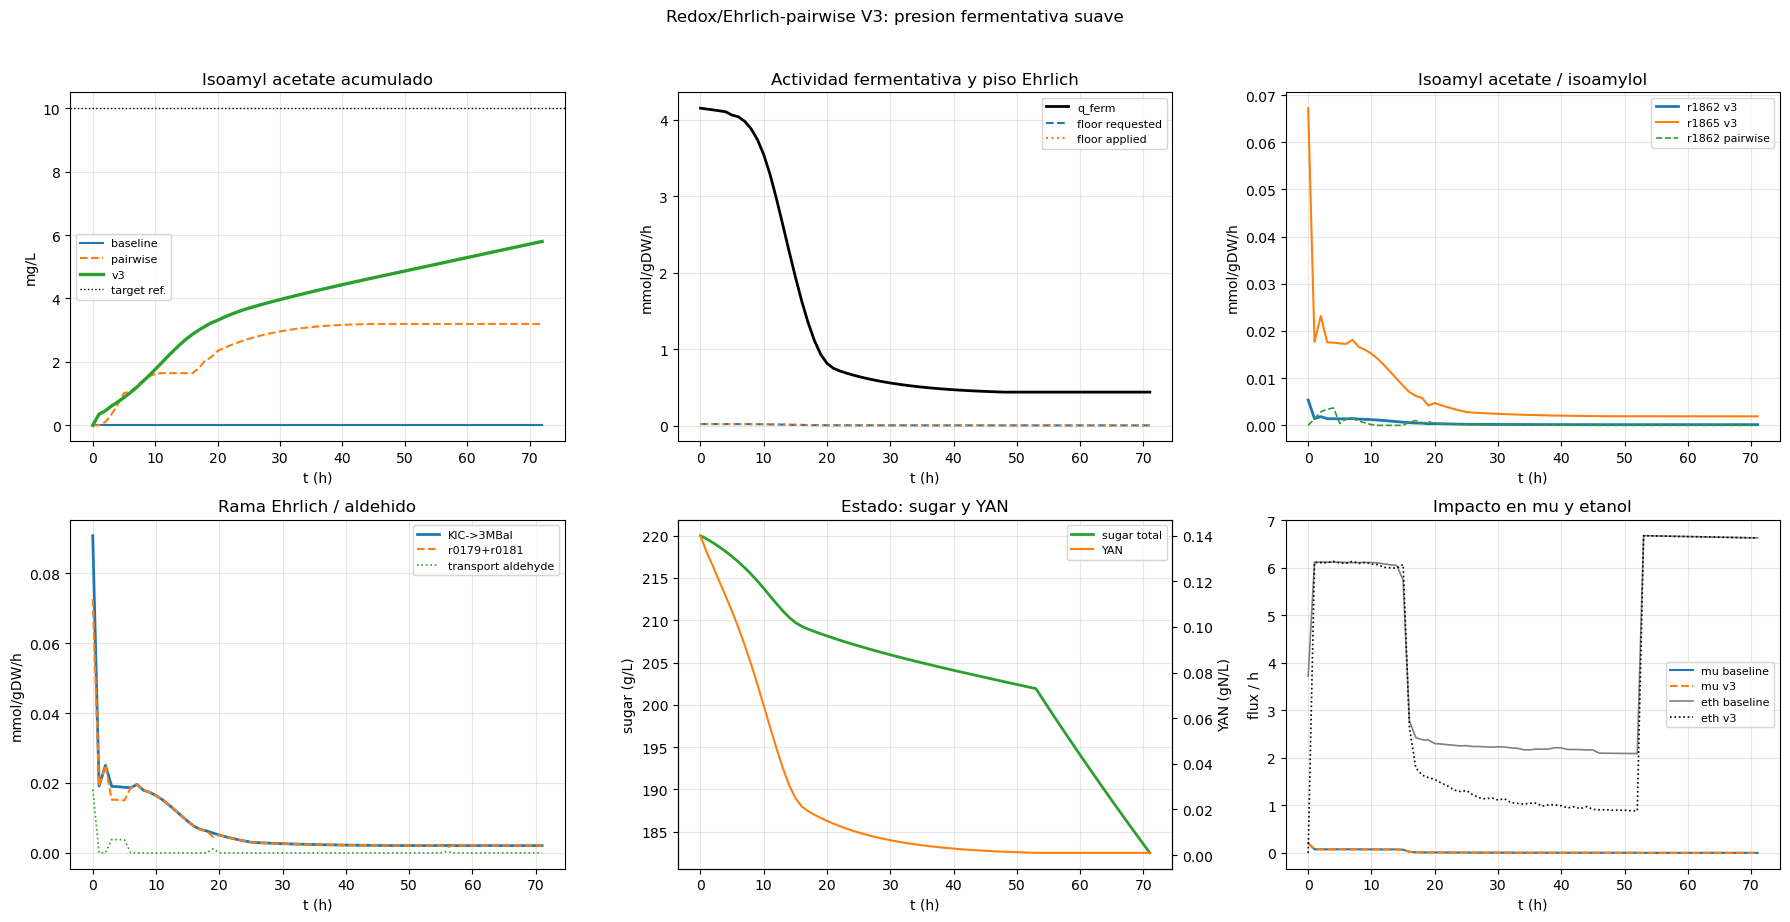


[Resumen redox-v3]


,n_snapshots,q_ferm_min,q_ferm_max,floor_requested_max,floor_applied_max,n_floor_applied,n_floor_relaxed,n_floor_omitted,n_branch_coupling_active,n_transport_cap_active,...,K_EHRLICH_SPILLOVER,K_SUGAR_G_L,K_YAN_GN_L,A_N_LOW,Q_FERM_DRIVER_MODE_V3,QFERM_SMOOTH_WINDOW_V3,QFERM_USE_MONOTONE_TAIL_V3,TARGET_ISOAC_FINAL_MG_L_V3,PHI_PAIR_V3,ENABLE_ADH_CAP_V3
0,72,0.437273,4.153033,0.019154,0.019154,72,0,0,72,72,...,0.005,20.0,0.02,0.05,macro_sugar_derivative,9,True,10.0,0.08,False



[Archivos guardados]
  out\redox_v3_time_comparison_cell45_v3.csv
  out\redox_v3_concentration_cell45_v3.csv
  out\redox_v3_summary_cell45_v3.csv

Interpretacion automatica V3.1
  [CAL] final V3=5.8 mg/L; K sugerido para 10 mg/L: 8.622e-03
  [OK]   r_1862 inicia desde t=0: 5.377e-03 mmol/gDW/h.
  [OK]   pairwise operativo: r1865_max=6.721e-02, r1862_max=5.377e-03.
  [OK]   transporte aldehido limitado/reportado: max=1.815e-02.
  [OK]   impacto sobre mu dentro del umbral del 5%.
  [OK]   sin salto fuerte asociado a TURNOVER_ATPM segun criterio local.

[Variables disponibles]
  redox_v3_time_df
  redox_v3_conc_df
  redox_v3_summary_df
  snapshot_cache_v3
  _build_snapshot_redox_v3

OK: Redox/Ehrlich-pairwise V3.2 completado.


In [39]:
import math
import warnings
import numpy as np
import pandas as pd
import cobra
import matplotlib.pyplot as plt

# ======================================================================================
# Redox/Ehrlich-pairwise V3.2: presion fermentativa suavizada hacia isoamyl acetate
# Snapshot-level INCREMENTAL sobre pairwise/V2.
#
# Cambios vs V3:
#   1) q_ferm usa una envolvente suavizada desde d(azucar total)/dt/X cuando es posible.
#   2) La modulacion por YAN se vuelve leve para evitar boosts tardios artificiales.
#   3) El parametro de escala sube para llevar V3 al orden de magnitud ~10 mg/L.
#   4) Se limita transporte libre de 3-methylbutanal y se exige detox parcial.
#   5) NO se impone piso directo sobre r_1862.
# ======================================================================================

print("\n" + "=" * 100)
print("Redox/Ehrlich-pairwise V3.2: presion fermentativa suavizada hacia isoamyl acetate")
print("  [q_ferm suavizado + beta/gamma aldehido -> isoamylol -> isoamyl acetate]")
print("=" * 100)

# --------------------------------------------------------------------------------------
# A. Dependencias y parametros
# --------------------------------------------------------------------------------------

_required_v3 = [
    "model", "OUT_DIR", "states_df_phase", "flux_df_phase", "phase_meta_df",
    "_build_phase_snapshot_model", "ester_alcohol_pairwise_df",
    "_add_pairwise_ester_coupling_constraints", "OBJ_ID", "ETH_ID", "ZERO_TOL",
]
_missing_v3 = [s for s in _required_v3 if s not in globals()]
if _missing_v3:
    raise RuntimeError(f"[redox-v3] Faltan simbolos requeridos: {_missing_v3}")

ENABLE_PAIRWISE_IN_V3       = True
ENABLE_EHRLICH_FLOOR_V3     = True
ENABLE_ADH_CAP_V3           = False
SAVE_REDOX_V3_CSV           = True
CELL_TAG_V3                 = "cell45_v3"

# Escala: antes 1e-3. Subirla desplaza la curva acumulada sin cambiar la arquitectura.
K_EHRLICH_SPILLOVER         = 5e-3
K_SUGAR_G_L                 = 20.0
K_YAN_GN_L                  = 0.020
A_N_LOW                     = 0.05     # modulador leve; evita aumento tardio dominado por bajo YAN
PHI_PAIR_V3                 = 0.08

# V3.2b: ATPM libre durante BIOMASS, aislado del resto de la arquitectura V3.2.
# Esto emula solo la liberacion de mantenimiento energetico en crecimiento.
ENABLE_ATPM_FREE_BIOMASS_V32 = True
RXN_ATPM_V3                  = globals().get("ATPM_ID", "r_4046")
ATPM_GROWTH_LB_V32           = float(globals().get("BAL_ATPM_GROWTH_LB", globals().get("ATPM_LB_NO_GROWTH", 0.7)))
ATPM_GROWTH_UB_V32           = float(globals().get("BAL_ATPM_GROWTH_UB", 1000.0))

# V3.2: evita que 3-methylbutanal sea un sumidero libre por transporte.
ENABLE_ALDH_BRANCH_COUPLING_V32 = True
BETA_ALDH_TO_ALCOHOL_V32       = 0.20   # r0179+r0181 >= beta * r0072
ENABLE_ALDEHYDE_TRANSPORT_CAP_V32 = True
GAMMA_ALDEHYDE_TRANSPORT_V32      = 0.20 # r1599+r1600 <= gamma * r0072
ALDEHYDE_TRANSPORT_IDS_V32        = ["r_1599", "r_1600"]

FLOOR_MIN_V3                = 1e-8
FLOOR_RELAX_FACTORS_V3      = [1.0, 0.5, 0.25]

# Driver fermentativo. macro_sugar_derivative evita que q_ferm dependa del objetivo
# BIOMASS/TURNOVER_ATPM; fallback a flujos si no hay estado macroscópico suficiente.
Q_FERM_DRIVER_MODE_V3       = "macro_sugar_derivative"  # "macro_sugar_derivative" | "flux"
MW_HEXOSE_G_PER_MMOL_V3     = 0.180156
QFERM_SMOOTH_WINDOW_V3      = 9
QFERM_USE_MONOTONE_TAIL_V3  = True
TARGET_ISOAC_FINAL_MG_L_V3  = 10.0
PLOT_INCLUDE_V2_REFERENCE   = False

# Hook opcional futuro. Mantener False al calibrar forma cinetica.
ADH_CAP_FACTOR_V3           = 0.95
ADH_CAP_ABS_V3              = np.inf
CAP_RELAX_FACTORS_V3        = [1.0, 1.25, 1.5]

RXN_ETH_EXCHANGE_V3         = globals().get("RXN_ETH_EXCHANGE", globals().get("ETH_ID", "r_1761"))
RXN_ADH_ETH_V3              = globals().get("RXN_ADH_ETH", "r_2115")
RXN_GLUCOSE_EXCHANGE_V3     = globals().get("GLU_ID", "r_1714")
RXN_FRUCTOSE_EXCHANGE_V3    = globals().get("FRU_ID", "r_1709")
RXN_ISOAMYL_ACETATE_EX_V3   = globals().get("RXN_ISOAMYL_ACETATE_EX", "r_1862")
RXN_ISOAMYLOL_EX_V3         = globals().get("RXN_ISOAMYLOL_EX", "r_1865")
RXN_ALDH_NADH_V3            = globals().get("RXN_ALDH_TO_ISOAMYLOL_NADH", "r_0179")
RXN_ALDH_NADPH_V3           = globals().get("RXN_ALDH_TO_ISOAMYLOL_NADPH", "r_0181")
RXN_ATF_ISOAMYL_V3          = globals().get("RXN_ATF_ISOAMYL", "r_0160")

MET_KIC_C_V3                = globals().get("MET_KIC_C", "s_0291")
MET_3METHYLBUTANAL_C_V3     = globals().get("MET_3METHYLBUTANAL_C", "s_0234")
MET_ISOAMYLOL_C_V3          = globals().get("MET_ISOAMYLOL_C", "s_0929")
MW_ISOAMYL_ACETATE_G_PER_MMOL_V3 = globals().get("MW_ISOAMYL_ACETATE_G_PER_MMOL", 0.130186)

print(f"ENABLE_EHRLICH_FLOOR_V3 = {ENABLE_EHRLICH_FLOOR_V3}")
print(f"ENABLE_ADH_CAP_V3       = {ENABLE_ADH_CAP_V3}")
print(f"K_EHRLICH_SPILLOVER     = {K_EHRLICH_SPILLOVER}")
print(f"K_SUGAR_G_L             = {K_SUGAR_G_L}")
print(f"K_YAN_GN_L              = {K_YAN_GN_L}")
print(f"A_N_LOW                 = {A_N_LOW}")
print(f"PHI_PAIR_V3             = {PHI_PAIR_V3}")
print(f"ENABLE_ATPM_FREE_BIOMASS_V32 = {ENABLE_ATPM_FREE_BIOMASS_V32}")
print(f"RXN_ATPM_V3                  = {RXN_ATPM_V3}")
print(f"ATPM_GROWTH_LB_V32           = {ATPM_GROWTH_LB_V32}")
print(f"ATPM_GROWTH_UB_V32           = {ATPM_GROWTH_UB_V32}")
print(f"ENABLE_ALDH_BRANCH_COUPLING_V32    = {ENABLE_ALDH_BRANCH_COUPLING_V32}")
print(f"BETA_ALDH_TO_ALCOHOL_V32           = {BETA_ALDH_TO_ALCOHOL_V32}")
print(f"ENABLE_ALDEHYDE_TRANSPORT_CAP_V32  = {ENABLE_ALDEHYDE_TRANSPORT_CAP_V32}")
print(f"GAMMA_ALDEHYDE_TRANSPORT_V32       = {GAMMA_ALDEHYDE_TRANSPORT_V32}")

# --------------------------------------------------------------------------------------
# B. Utilidades
# --------------------------------------------------------------------------------------

def _read_state_v3(state_row, name):
    if hasattr(state_row, "index") and name in state_row.index:
        try:
            return float(state_row[name])
        except Exception:
            return np.nan
    return np.nan


def _read_sugar_total_v3(state_row):
    glu = np.nan
    for cand in ["G_g_L", "Glu_g_L", "glucose_g_L", "Glucose_g_L"]:
        v = _read_state_v3(state_row, cand)
        if np.isfinite(v):
            glu = v
            break

    fru = np.nan
    for cand in ["F_g_L", "Fru_g_L", "fructose_g_L", "Fructose_g_L"]:
        v = _read_state_v3(state_row, cand)
        if np.isfinite(v):
            fru = v
            break

    total, has_any = 0.0, False
    if np.isfinite(glu):
        total += glu
        has_any = True
    if np.isfinite(fru):
        total += fru
        has_any = True
    if not has_any:
        sg = _read_state_v3(state_row, "Sugar_g_L")
        if np.isfinite(sg):
            total, has_any = sg, True
    return (total if has_any else np.nan), glu, fru


def _rxn_present_v3(mtmp, rid):
    return rid is not None and rid in {r.id for r in mtmp.reactions}


def _flux_v3(sol, rid, tol=None):
    tol = ZERO_TOL if tol is None else tol
    if getattr(sol, "status", "") != "optimal" or rid is None:
        return np.nan
    try:
        v = float(sol.fluxes.get(rid, np.nan))
    except Exception:
        return np.nan
    return 0.0 if np.isfinite(v) and abs(v) < tol else v


def _infer_kic_to_3mbal_rxn_id(mtmp):
    """Detecta reaccion que consume KIC[c] y produce 3-methylbutanal[c]."""
    met_ids = {m.id for m in mtmp.metabolites}
    if MET_KIC_C_V3 not in met_ids or MET_3METHYLBUTANAL_C_V3 not in met_ids:
        return None
    kic = mtmp.metabolites.get_by_id(MET_KIC_C_V3)
    alde = mtmp.metabolites.get_by_id(MET_3METHYLBUTANAL_C_V3)
    candidates = []
    for rxn in mtmp.reactions:
        ck = rxn.metabolites.get(kic, 0.0)
        ca = rxn.metabolites.get(alde, 0.0)
        if ck < 0 and ca > 0:
            name_l = (rxn.name or "").lower()
            score = 10 * ("decarbox" in name_l) + 2 * ("methyl" in name_l or "oxo" in name_l)
            candidates.append((score, rxn.id))
    return sorted(candidates, reverse=True)[0][1] if candidates else None


RXN_KIC_TO_3MBAL_V3 = globals().get("RXN_KIC_TO_3MBAL", None)
if not _rxn_present_v3(model, RXN_KIC_TO_3MBAL_V3):
    RXN_KIC_TO_3MBAL_V3 = _infer_kic_to_3mbal_rxn_id(model)

print("\n[IDs V3]")
for label, rid in [
    ("RXN_GLUCOSE_EXCHANGE_V3", RXN_GLUCOSE_EXCHANGE_V3),
    ("RXN_FRUCTOSE_EXCHANGE_V3", RXN_FRUCTOSE_EXCHANGE_V3),
    ("RXN_ETH_EXCHANGE_V3", RXN_ETH_EXCHANGE_V3),
    ("RXN_ADH_ETH_V3", RXN_ADH_ETH_V3),
    ("RXN_KIC_TO_3MBAL_V3", RXN_KIC_TO_3MBAL_V3),
    ("RXN_ALDH_NADH_V3", RXN_ALDH_NADH_V3),
    ("RXN_ALDH_NADPH_V3", RXN_ALDH_NADPH_V3),
    ("RXN_ISOAMYLOL_EX_V3", RXN_ISOAMYLOL_EX_V3),
    ("RXN_ISOAMYL_ACETATE_EX_V3", RXN_ISOAMYL_ACETATE_EX_V3),
]:
    print(f"  {label:30s} = {str(rid):10s} [{'OK' if _rxn_present_v3(model, rid) else 'MISSING'}]")

if _rxn_present_v3(model, RXN_KIC_TO_3MBAL_V3):
    rx = model.reactions.get_by_id(RXN_KIC_TO_3MBAL_V3)
    print(f"\n[Upstream Ehrlich detectado] {rx.id} | {rx.name} | {rx.reaction}")
else:
    print("\n[WARN] No se detecto KIC -> 3-methylbutanal. V3 usara fallback r_0179+r_0181.")


def _build_ferm_activity_driver_v3(analysis_times):
    """Construye q_ferm desde -d(S_total)/dt/X y lo suaviza.

    Esto reduce artefactos por cambio de objetivo porque el driver viene de la
    trayectoria macroscópica, no de la solución LP instantánea.
    """
    rows = []
    for _, row in states_df_phase.sort_values("t_h").iterrows():
        s_total, glu, fru = _read_sugar_total_v3(row)
        x_val = _read_state_v3(row, "X_gDW_L")
        rows.append({"t_h": float(row["t_h"]), "S_total_g_L": s_total, "X_gDW_L": x_val})
    df = pd.DataFrame(rows).dropna(subset=["t_h", "S_total_g_L", "X_gDW_L"]).sort_values("t_h")
    df = df[df["X_gDW_L"] > 0].drop_duplicates("t_h")
    if len(df) < 3:
        return pd.DataFrame(columns=["t_h", "q_ferm_macro_raw", "q_ferm_macro_smooth"])

    t = df["t_h"].to_numpy(dtype=float)
    s = df["S_total_g_L"].to_numpy(dtype=float)
    x = df["X_gDW_L"].to_numpy(dtype=float)
    dSdt = np.gradient(s, t)
    with np.errstate(divide="ignore", invalid="ignore"):
        q_raw = np.maximum(0.0, -dSdt) / (MW_HEXOSE_G_PER_MMOL_V3 * x)

    q_smooth = pd.Series(q_raw).rolling(
        int(QFERM_SMOOTH_WINDOW_V3), center=True, min_periods=1
    ).mean().to_numpy(dtype=float)

    if QFERM_USE_MONOTONE_TAIL_V3 and np.isfinite(q_smooth).any():
        peak_idx = int(np.nanargmax(q_smooth))
        for i in range(peak_idx + 1, len(q_smooth)):
            if np.isfinite(q_smooth[i - 1]) and np.isfinite(q_smooth[i]):
                q_smooth[i] = min(q_smooth[i], q_smooth[i - 1])

    # Interpolar a tiempos de análisis para evitar lookup frágil por floats.
    q_interp = np.interp(
        np.asarray(analysis_times, dtype=float), t, q_smooth,
        left=q_smooth[0], right=q_smooth[-1],
    )
    return pd.DataFrame({
        "t_h": np.asarray(analysis_times, dtype=float),
        "q_ferm_macro_smooth": q_interp,
        "q_ferm_macro_raw_state_mean": float(np.nanmean(q_raw)),
        "q_ferm_macro_raw_state_max": float(np.nanmax(q_raw)),
    })


def _compute_q_flux_v3(sol_ref):
    """q_ferm desde solución LP: uptake glucosa+fructosa, fallback etanol."""
    if getattr(sol_ref, "status", "") != "optimal":
        return np.nan, "none", np.nan, np.nan, np.nan

    v_glu = _flux_v3(sol_ref, RXN_GLUCOSE_EXCHANGE_V3)
    v_fru = _flux_v3(sol_ref, RXN_FRUCTOSE_EXCHANGE_V3)
    q_sugar = 0.0
    has_sugar_flux = False
    if np.isfinite(v_glu):
        q_sugar += abs(min(0.0, v_glu))
        has_sugar_flux = True
    if np.isfinite(v_fru):
        q_sugar += abs(min(0.0, v_fru))
        has_sugar_flux = True
    if has_sugar_flux and q_sugar > ZERO_TOL:
        return float(q_sugar), "sugar_uptake_flux", v_glu, v_fru, _flux_v3(sol_ref, RXN_ETH_EXCHANGE_V3)

    v_eth = _flux_v3(sol_ref, RXN_ETH_EXCHANGE_V3)
    if np.isfinite(v_eth):
        return float(abs(v_eth)), "ethanol_exchange_flux", v_glu, v_fru, v_eth
    return np.nan, "none", v_glu, v_fru, v_eth


def _compute_q_ferm_v3(sol_ref, t_phase=None):
    q_flux, q_flux_source, v_glu, v_fru, v_eth = _compute_q_flux_v3(sol_ref)
    q_macro = np.nan
    if (
        Q_FERM_DRIVER_MODE_V3 == "macro_sugar_derivative"
        and "FERM_ACTIVITY_DRIVER_V3_DF" in globals()
        and not FERM_ACTIVITY_DRIVER_V3_DF.empty
        and t_phase is not None
    ):
        arr_t = FERM_ACTIVITY_DRIVER_V3_DF["t_h"].to_numpy(dtype=float)
        arr_q = FERM_ACTIVITY_DRIVER_V3_DF["q_ferm_macro_smooth"].to_numpy(dtype=float)
        q_macro = float(np.interp(float(t_phase), arr_t, arr_q))
        if np.isfinite(q_macro) and q_macro > ZERO_TOL:
            return q_macro, "macro_sugar_derivative_smooth", v_glu, v_fru, v_eth, q_flux, q_macro

    return q_flux, q_flux_source, v_glu, v_fru, v_eth, q_flux, q_macro


def _compute_ehrlich_floor_v3(sol_ref, state_row, t_phase=None):
    q_ferm, q_source, v_glu, v_fru, v_eth, q_flux, q_macro = _compute_q_ferm_v3(sol_ref, t_phase)
    sugar_total, glu_g_l, fru_g_l = _read_sugar_total_v3(state_row)
    yan = _read_state_v3(state_row, "N_gN_L")

    if np.isfinite(sugar_total) and sugar_total > 0:
        f_sugar = sugar_total / (K_SUGAR_G_L + sugar_total)
    else:
        f_sugar = 1.0 if np.isfinite(q_ferm) and q_ferm > ZERO_TOL else 0.0

    if np.isfinite(yan) and yan >= 0:
        f_n = 1.0 + A_N_LOW * K_YAN_GN_L / (K_YAN_GN_L + max(yan, 1e-12))
    else:
        f_n = 1.0

    floor = K_EHRLICH_SPILLOVER * q_ferm * f_sugar * f_n if np.isfinite(q_ferm) else 0.0
    floor = 0.0 if floor < FLOOR_MIN_V3 else float(floor)
    return {
        "q_ferm": float(q_ferm) if np.isfinite(q_ferm) else np.nan,
        "q_ferm_source": q_source,
        "q_ferm_flux": q_flux,
        "q_ferm_macro": q_macro,
        "v_glucose_baseline": v_glu,
        "v_fructose_baseline": v_fru,
        "v_eth_baseline": v_eth,
        "S_total_g_L": sugar_total,
        "glucose_g_L": glu_g_l,
        "fructose_g_L": fru_g_l,
        "N_gN_L": yan,
        "f_sugar": float(f_sugar),
        "f_N": float(f_n),
        "v_ehrlich_floor_requested": floor,
    }

# --------------------------------------------------------------------------------------
# C. Restricciones y wrapper snapshot
# --------------------------------------------------------------------------------------

def _apply_atpm_free_biomass_v32(mtmp, mode_str):
    """Libera ATPM solo en snapshots BIOMASS y reporta el cambio aplicado."""
    info = {
        "atpm_free_biomass_active": False,
        "atpm_free_biomass_status": "disabled",
        "atpm_old_lb": np.nan,
        "atpm_old_ub": np.nan,
        "atpm_new_lb": np.nan,
        "atpm_new_ub": np.nan,
    }
    if not ENABLE_ATPM_FREE_BIOMASS_V32:
        return info
    if not isinstance(mode_str, str) or "BIOMASS" not in mode_str.upper():
        info["atpm_free_biomass_status"] = "not_biomass"
        return info
    if not _rxn_present_v3(mtmp, RXN_ATPM_V3):
        info["atpm_free_biomass_status"] = "missing_atpm"
        return info

    rxn = mtmp.reactions.get_by_id(RXN_ATPM_V3)
    old_lb = float(rxn.lower_bound)
    old_ub = float(rxn.upper_bound)
    rxn.lower_bound = max(old_lb, float(ATPM_GROWTH_LB_V32))
    rxn.upper_bound = max(old_ub, float(ATPM_GROWTH_UB_V32))
    info.update({
        "atpm_free_biomass_active": True,
        "atpm_free_biomass_status": "applied",
        "atpm_old_lb": old_lb,
        "atpm_old_ub": old_ub,
        "atpm_new_lb": float(rxn.lower_bound),
        "atpm_new_ub": float(rxn.upper_bound),
    })
    return info


def _add_ehrlich_floor_v3(mtmp, floor_value, name_suffix):
    rxn_set = {r.id for r in mtmp.reactions}
    if _rxn_present_v3(mtmp, RXN_KIC_TO_3MBAL_V3):
        rxn = mtmp.reactions.get_by_id(RXN_KIC_TO_3MBAL_V3)
        cons = mtmp.problem.Constraint(
            rxn.flux_expression,
            lb=float(floor_value),
            name=f"v3_kic_to_3mbal_floor_{name_suffix}",
        )
        mtmp.add_cons_vars([cons])
        return "kic_to_3mbal", RXN_KIC_TO_3MBAL_V3

    if RXN_ALDH_NADH_V3 in rxn_set and RXN_ALDH_NADPH_V3 in rxn_set:
        r1 = mtmp.reactions.get_by_id(RXN_ALDH_NADH_V3)
        r2 = mtmp.reactions.get_by_id(RXN_ALDH_NADPH_V3)
        cons = mtmp.problem.Constraint(
            r1.flux_expression + r2.flux_expression,
            lb=float(floor_value),
            name=f"v3_aldh_floor_{name_suffix}",
        )
        mtmp.add_cons_vars([cons])
        return "aldh_to_isoamylol_fallback", f"{RXN_ALDH_NADH_V3}+{RXN_ALDH_NADPH_V3}"

    raise RuntimeError("No hay target disponible para floor V3.")

def _add_v32_branch_transport_constraints(mtmp, name_suffix):
    """V3.2: detox parcial aldehido y limite a transporte libre.

    r0179+r0181 >= beta * r0072
    r1599+r1600 <= gamma * r0072
    """
    info = {
        "branch_coupling_active": False,
        "transport_cap_active": False,
        "branch_beta": BETA_ALDH_TO_ALCOHOL_V32 if ENABLE_ALDH_BRANCH_COUPLING_V32 else np.nan,
        "transport_gamma": GAMMA_ALDEHYDE_TRANSPORT_V32 if ENABLE_ALDEHYDE_TRANSPORT_CAP_V32 else np.nan,
    }
    if not _rxn_present_v3(mtmp, RXN_KIC_TO_3MBAL_V3):
        return info

    decarb_expr = mtmp.reactions.get_by_id(RXN_KIC_TO_3MBAL_V3).flux_expression
    rxn_set = {r.id for r in mtmp.reactions}

    if ENABLE_ALDH_BRANCH_COUPLING_V32 and BETA_ALDH_TO_ALCOHOL_V32 > 0:
        aldh_exprs = []
        for rid in [RXN_ALDH_NADH_V3, RXN_ALDH_NADPH_V3]:
            if rid in rxn_set:
                aldh_exprs.append(mtmp.reactions.get_by_id(rid).flux_expression)
        if aldh_exprs:
            cons_beta = mtmp.problem.Constraint(
                sum(aldh_exprs) - float(BETA_ALDH_TO_ALCOHOL_V32) * decarb_expr,
                lb=0.0,
                name=f"v32_beta_aldh_to_alcohol_{name_suffix}",
            )
            mtmp.add_cons_vars([cons_beta])
            info["branch_coupling_active"] = True

    if ENABLE_ALDEHYDE_TRANSPORT_CAP_V32 and GAMMA_ALDEHYDE_TRANSPORT_V32 >= 0:
        transport_exprs = []
        for rid in ALDEHYDE_TRANSPORT_IDS_V32:
            if rid in rxn_set:
                transport_exprs.append(mtmp.reactions.get_by_id(rid).flux_expression)
        if transport_exprs:
            cons_gamma = mtmp.problem.Constraint(
                sum(transport_exprs) - float(GAMMA_ALDEHYDE_TRANSPORT_V32) * decarb_expr,
                ub=0.0,
                name=f"v32_gamma_transport_cap_{name_suffix}",
            )
            mtmp.add_cons_vars([cons_gamma])
            info["transport_cap_active"] = True

    return info



def _apply_adh_cap_v3(mtmp, sol_ref):
    info = {"cap_active": False, "cap_applied": np.nan, "cap_relaxed": False, "cap_omitted": False}
    if not ENABLE_ADH_CAP_V3:
        return info
    target = RXN_ADH_ETH_V3 if _rxn_present_v3(mtmp, RXN_ADH_ETH_V3) else RXN_ETH_EXCHANGE_V3
    if not _rxn_present_v3(mtmp, target):
        info["cap_omitted"] = True
        return info
    v_base = abs(_flux_v3(sol_ref, target))
    if not np.isfinite(v_base) or v_base <= FLOOR_MIN_V3:
        return info
    rxn = mtmp.reactions.get_by_id(target)
    old_ub = float(rxn.upper_bound)
    base_cap = min(ADH_CAP_FACTOR_V3 * v_base, ADH_CAP_ABS_V3)
    for fac in CAP_RELAX_FACTORS_V3:
        rxn.upper_bound = min(old_ub, base_cap * fac)
        sol = mtmp.optimize()
        if getattr(sol, "status", "") == "optimal":
            info.update({"cap_active": True, "cap_applied": rxn.upper_bound, "cap_relaxed": fac != 1.0})
            return info
    rxn.upper_bound = old_ub
    info["cap_omitted"] = True
    return info


def _solve_with_floor_v3(mtmp, floor_requested, name_suffix):
    info = {
        "floor_target_mode": "none",
        "floor_target_id": None,
        "v_ehrlich_floor_requested": float(floor_requested),
        "v_ehrlich_floor_applied": 0.0,
        "floor_relaxed": False,
        "floor_omitted": False,
        "branch_coupling_active": False,
        "transport_cap_active": False,
        "branch_beta": BETA_ALDH_TO_ALCOHOL_V32 if ENABLE_ALDH_BRANCH_COUPLING_V32 else np.nan,
        "transport_gamma": GAMMA_ALDEHYDE_TRANSPORT_V32 if ENABLE_ALDEHYDE_TRANSPORT_CAP_V32 else np.nan,
    }

    candidate_factors = FLOOR_RELAX_FACTORS_V3 if (ENABLE_EHRLICH_FLOOR_V3 and floor_requested > FLOOR_MIN_V3) else [0.0]
    for fac in candidate_factors:
        m_try = mtmp.copy()
        floor_try = float(floor_requested) * float(fac)
        try:
            mode, target_id = "none", None
            if floor_try > FLOOR_MIN_V3:
                mode, target_id = _add_ehrlich_floor_v3(m_try, floor_try, name_suffix)
            v32_info = _add_v32_branch_transport_constraints(m_try, name_suffix)
            sol = m_try.optimize()
            status = getattr(sol, "status", "unknown")
        except Exception as exc:
            status = f"error:{exc}"
            sol = None
            mode, target_id = "error", None
            v32_info = {}
        if status == "optimal":
            info.update({
                "floor_target_mode": mode,
                "floor_target_id": target_id,
                "v_ehrlich_floor_applied": floor_try,
                "floor_relaxed": bool(fac not in (0.0, 1.0)),
            })
            info.update(v32_info)
            return sol, info, m_try

    warnings.warn(f"[redox-v3] restricciones V3.2/floor inviables en t={name_suffix}; se omite floor y V3.2.")
    info["floor_omitted"] = True
    m_fallback = mtmp.copy()
    sol = m_fallback.optimize()
    return sol, info, m_fallback


def _build_snapshot_redox_v3(t_phase, pairwise_df=None, phi_pair=None):
    snap = _build_phase_snapshot_model(float(t_phase))
    m_base, sol_base = snap["model"], snap["solution"]
    state_row, mode_str, objective_id = snap["state_row"], snap["mode"], snap["objective_id"]

    atpm_info = _apply_atpm_free_biomass_v32(m_base, mode_str)
    if atpm_info["atpm_free_biomass_active"]:
        sol_reopt = m_base.optimize()
        atpm_info["atpm_free_biomass_status"] = getattr(sol_reopt, "status", "unknown")
        if getattr(sol_reopt, "status", "") == "optimal":
            sol_base = sol_reopt
        else:
            warnings.warn(
                f"[redox-v3] ATPM libre en BIOMASS no optimizo en t={t_phase}; "
                "se conserva la solucion snapshot original."
            )

    phi_use = PHI_PAIR_V3 if phi_pair is None else float(phi_pair)
    m_pair = m_base.copy()
    sol_pair = sol_base
    if ENABLE_PAIRWISE_IN_V3 and pairwise_df is not None and not pairwise_df.empty:
        pwdf = pairwise_df.copy()
        if "phi_pair" in pwdf.columns:
            pwdf.loc[pwdf["pair_active"] == True, "phi_pair"] = phi_use
        _add_pairwise_ester_coupling_constraints(m_pair, pwdf)
        sol_pair = m_pair.optimize()

    m_work = m_pair.copy()
    cap_info = _apply_adh_cap_v3(m_work, sol_base)
    floor_calc = _compute_ehrlich_floor_v3(sol_base, state_row, t_phase=float(t_phase))
    sol_v3, floor_info, m_v3 = _solve_with_floor_v3(
        m_work,
        floor_calc["v_ehrlich_floor_requested"],
        str(float(t_phase)).replace(".", "p"),
    )

    return {
        "t_h": float(t_phase),
        "mode": mode_str,
        "objective_id": objective_id,
        "state_row": state_row,
        "model_baseline": m_base,
        "model_pairwise": m_pair,
        "model_v3": m_v3,
        "solution_baseline": sol_base,
        "solution_pairwise": sol_pair,
        "solution_v3": sol_v3,
        "floor_calc": floor_calc,
        "floor_info": floor_info,
        "cap_info": cap_info,
        "atpm_info": atpm_info,
    }

# --------------------------------------------------------------------------------------
# D. Ejecutar trayectoria snapshot-level
# --------------------------------------------------------------------------------------

analysis_times_v3 = flux_df_phase["t_h"].to_numpy(dtype=float)
state_times_v3 = states_df_phase["t_h"].to_numpy(dtype=float)
FERM_ACTIVITY_DRIVER_V3_DF = _build_ferm_activity_driver_v3(analysis_times_v3)
if not FERM_ACTIVITY_DRIVER_V3_DF.empty:
    print("\n[Driver q_ferm V3.1] usando macro_sugar_derivative_smooth")
    display(FERM_ACTIVITY_DRIVER_V3_DF.head())
else:
    print("\n[Driver q_ferm V3.1] sin driver macro; fallback a flujos LP")

snapshot_cache_v3 = {}
rows_v3 = []

for k_t, t_k in enumerate(analysis_times_v3):
    if k_t % 10 == 0:
        print(f"[V3] snapshot {k_t + 1}/{len(analysis_times_v3)} | t={float(t_k):.3g} h")
    res = _build_snapshot_redox_v3(
        t_k,
        pairwise_df=ester_alcohol_pairwise_df,
        phi_pair=PHI_PAIR_V3,
    )
    snapshot_cache_v3[float(t_k)] = {
        "model_baseline": res["model_baseline"],
        "model_pairwise": res["model_pairwise"],
        "model_v3": res["model_v3"],
        "solution_baseline": res["solution_baseline"],
        "solution_pairwise": res["solution_pairwise"],
        "solution_v3": res["solution_v3"],
    }

    sol_b, sol_pw, sol_v3 = res["solution_baseline"], res["solution_pairwise"], res["solution_v3"]
    fc, fi, ci, ai = res["floor_calc"], res["floor_info"], res["cap_info"], res["atpm_info"]
    obj_id = res["objective_id"]

    v_aldh_sum = np.nansum([_flux_v3(sol_v3, RXN_ALDH_NADH_V3), _flux_v3(sol_v3, RXN_ALDH_NADPH_V3)])
    if np.isnan(_flux_v3(sol_v3, RXN_ALDH_NADH_V3)) and np.isnan(_flux_v3(sol_v3, RXN_ALDH_NADPH_V3)):
        v_aldh_sum = np.nan

    rows_v3.append({
        "t_h": float(t_k),
        "mode": res["mode"],
        "q_ferm": fc["q_ferm"],
        "q_ferm_source": fc["q_ferm_source"],
        "q_ferm_flux": fc.get("q_ferm_flux", np.nan),
        "q_ferm_macro": fc.get("q_ferm_macro", np.nan),
        "S_total_g_L": fc["S_total_g_L"],
        "glucose_g_L": fc["glucose_g_L"],
        "fructose_g_L": fc["fructose_g_L"],
        "N_gN_L": fc["N_gN_L"],
        "f_sugar": fc["f_sugar"],
        "f_N": fc["f_N"],
        "v_ehrlich_floor_requested": fi["v_ehrlich_floor_requested"],
        "v_ehrlich_floor_applied": fi["v_ehrlich_floor_applied"],
        "floor_target_mode": fi["floor_target_mode"],
        "floor_target_id": fi["floor_target_id"],
        "floor_relaxed": fi["floor_relaxed"],
        "floor_omitted": fi["floor_omitted"],
        "branch_coupling_active": fi.get("branch_coupling_active", False),
        "transport_cap_active": fi.get("transport_cap_active", False),
        "branch_beta": fi.get("branch_beta", np.nan),
        "transport_gamma": fi.get("transport_gamma", np.nan),
        "atpm_free_biomass_active": ai.get("atpm_free_biomass_active", False),
        "atpm_free_biomass_status": ai.get("atpm_free_biomass_status", "unknown"),
        "atpm_old_lb": ai.get("atpm_old_lb", np.nan),
        "atpm_old_ub": ai.get("atpm_old_ub", np.nan),
        "atpm_new_lb": ai.get("atpm_new_lb", np.nan),
        "atpm_new_ub": ai.get("atpm_new_ub", np.nan),
        "cap_active": ci["cap_active"],
        "cap_applied": ci["cap_applied"],
        "cap_relaxed": ci["cap_relaxed"],
        "cap_omitted": ci["cap_omitted"],
        "status_baseline": getattr(sol_b, "status", "unknown"),
        "status_pairwise": getattr(sol_pw, "status", "unknown"),
        "status_v3": getattr(sol_v3, "status", "unknown"),
        "objective_id": obj_id,
        "obj_baseline": _flux_v3(sol_b, obj_id),
        "obj_v3": _flux_v3(sol_v3, obj_id),
        "mu_baseline": _flux_v3(sol_b, OBJ_ID),
        "mu_v3": _flux_v3(sol_v3, OBJ_ID),
        "v_glucose_baseline": fc["v_glucose_baseline"],
        "v_fructose_baseline": fc["v_fructose_baseline"],
        "v_eth_baseline": fc["v_eth_baseline"],
        "v_eth_v3": _flux_v3(sol_v3, RXN_ETH_EXCHANGE_V3),
        "v_ATPM_baseline": _flux_v3(sol_b, RXN_ATPM_V3),
        "v_ATPM_v3": _flux_v3(sol_v3, RXN_ATPM_V3),
        "v_ADH_v3": _flux_v3(sol_v3, RXN_ADH_ETH_V3),
        "v_ehrlich_decarb_v3": _flux_v3(sol_v3, RXN_KIC_TO_3MBAL_V3),
        "v_aldehyde_transport_sum_v3": np.nansum([_flux_v3(sol_v3, rid) for rid in ALDEHYDE_TRANSPORT_IDS_V32]),
        "v_r0179_v3": _flux_v3(sol_v3, RXN_ALDH_NADH_V3),
        "v_r0181_v3": _flux_v3(sol_v3, RXN_ALDH_NADPH_V3),
        "v_aldh_sum_v3": v_aldh_sum,
        "v_r1865_v3": _flux_v3(sol_v3, RXN_ISOAMYLOL_EX_V3),
        "v_r1862_v3": _flux_v3(sol_v3, RXN_ISOAMYL_ACETATE_EX_V3),
        "v_r1862_pairwise": _flux_v3(sol_pw, RXN_ISOAMYL_ACETATE_EX_V3),
        "v_r1865_pairwise": _flux_v3(sol_pw, RXN_ISOAMYLOL_EX_V3),
        "v_r1862_baseline": _flux_v3(sol_b, RXN_ISOAMYL_ACETATE_EX_V3),
        "v_r1865_baseline": _flux_v3(sol_b, RXN_ISOAMYLOL_EX_V3),
    })

redox_v3_time_df = pd.DataFrame(rows_v3)

print("\n[Comparativa V3 por tiempo]")
_show_v3 = [
    "t_h", "mode", "q_ferm", "q_ferm_source", "q_ferm_flux", "q_ferm_macro", "S_total_g_L", "N_gN_L",
    "f_sugar", "f_N", "v_ehrlich_floor_requested", "v_ehrlich_floor_applied",
    "floor_target_mode", "floor_relaxed", "floor_omitted",
    "atpm_free_biomass_active", "atpm_new_lb", "atpm_new_ub", "v_ATPM_baseline", "v_ATPM_v3",
    "mu_baseline", "mu_v3", "v_eth_baseline", "v_eth_v3",
    "v_ehrlich_decarb_v3", "v_aldh_sum_v3", "v_aldehyde_transport_sum_v3", "v_r1865_v3", "v_r1862_v3",
]
display(redox_v3_time_df[[c for c in _show_v3 if c in redox_v3_time_df.columns]].head(20))

# --------------------------------------------------------------------------------------
# E. Concentracion acumulada de isoamyl acetate
# --------------------------------------------------------------------------------------

c_iso_baseline_v3 = np.zeros(len(state_times_v3), dtype=float)
c_iso_pairwise_v3 = np.zeros(len(state_times_v3), dtype=float)
c_iso_v3 = np.zeros(len(state_times_v3), dtype=float)

for k_c, t_kc in enumerate(analysis_times_v3):
    if k_c + 1 >= len(state_times_v3):
        break
    dt_kc = float(state_times_v3[k_c + 1] - state_times_v3[k_c])
    row_state = states_df_phase.loc[states_df_phase["t_h"] == float(t_kc)]
    if row_state.empty:
        c_iso_baseline_v3[k_c + 1] = c_iso_baseline_v3[k_c]
        c_iso_pairwise_v3[k_c + 1] = c_iso_pairwise_v3[k_c]
        c_iso_v3[k_c + 1] = c_iso_v3[k_c]
        continue
    Xk = float(row_state.iloc[0]["X_gDW_L"]) if "X_gDW_L" in row_state.columns else 0.0
    rdf = redox_v3_time_df[redox_v3_time_df["t_h"] == float(t_kc)]
    if rdf.empty:
        continue
    rr = rdf.iloc[0]
    fac = 1000.0 * MW_ISOAMYL_ACETATE_G_PER_MMOL_V3 * Xk * dt_kc
    c_iso_baseline_v3[k_c + 1] = c_iso_baseline_v3[k_c] + fac * max(0.0, float(rr.get("v_r1862_baseline", 0.0) or 0.0))
    c_iso_pairwise_v3[k_c + 1] = c_iso_pairwise_v3[k_c] + fac * max(0.0, float(rr.get("v_r1862_pairwise", 0.0) or 0.0))
    c_iso_v3[k_c + 1] = c_iso_v3[k_c] + fac * max(0.0, float(rr.get("v_r1862_v3", 0.0) or 0.0))

redox_v3_conc_df = pd.DataFrame({
    "t_h": state_times_v3,
    "isoamyl_acetate_baseline_mg_L": c_iso_baseline_v3,
    "isoamyl_acetate_pairwise_mg_L": c_iso_pairwise_v3,
    "isoamyl_acetate_v3_mg_L": c_iso_v3,
})
redox_v3_conc_df["delta_v3_vs_baseline_mg_L"] = (
    redox_v3_conc_df["isoamyl_acetate_v3_mg_L"]
    - redox_v3_conc_df["isoamyl_acetate_baseline_mg_L"]
)

print("\n[Concentracion acumulada isoamyl acetate V3]")
display(redox_v3_conc_df.tail(10))

# --------------------------------------------------------------------------------------
# F. Graficos
# --------------------------------------------------------------------------------------

fig, ax = plt.subplots(2, 3, figsize=(18, 9), sharex=False)

ax[0, 0].plot(redox_v3_conc_df["t_h"], redox_v3_conc_df["isoamyl_acetate_baseline_mg_L"], lw=1.5, label="baseline")
ax[0, 0].plot(redox_v3_conc_df["t_h"], redox_v3_conc_df["isoamyl_acetate_pairwise_mg_L"], lw=1.5, ls="--", label="pairwise")
if PLOT_INCLUDE_V2_REFERENCE and "redox_v2_conc_df" in globals() and "isoamyl_acetate_redox_v2_mg_L" in redox_v2_conc_df.columns:
    ax[0, 0].plot(redox_v2_conc_df["t_h"], redox_v2_conc_df["isoamyl_acetate_redox_v2_mg_L"], lw=1.2, ls=":", label="v2")
ax[0, 0].plot(redox_v3_conc_df["t_h"], redox_v3_conc_df["isoamyl_acetate_v3_mg_L"], lw=2.4, label="v3")
if np.isfinite(TARGET_ISOAC_FINAL_MG_L_V3):
    ax[0, 0].axhline(TARGET_ISOAC_FINAL_MG_L_V3, lw=1.0, ls=":", color="black", label="target ref.")
ax[0, 0].set_title("Isoamyl acetate acumulado")
ax[0, 0].set_xlabel("t (h)")
ax[0, 0].set_ylabel("mg/L")
ax[0, 0].grid(alpha=0.3)
ax[0, 0].legend(fontsize=8)

ax[0, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df["q_ferm"], lw=2, label="q_ferm", color="black")
ax[0, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_ehrlich_floor_requested"], lw=1.5, ls="--", label="floor requested")
ax[0, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_ehrlich_floor_applied"], lw=1.5, ls=":", label="floor applied")
ax[0, 1].set_title("Actividad fermentativa y piso Ehrlich")
ax[0, 1].set_xlabel("t (h)")
ax[0, 1].set_ylabel("mmol/gDW/h")
ax[0, 1].grid(alpha=0.3)
ax[0, 1].legend(fontsize=8)

ax[0, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_r1862_v3"], lw=2, label="r1862 v3")
ax[0, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_r1865_v3"], lw=1.5, label="r1865 v3")
ax[0, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_r1862_pairwise"], lw=1.2, ls="--", label="r1862 pairwise")
ax[0, 2].set_title("Isoamyl acetate / isoamylol")
ax[0, 2].set_xlabel("t (h)")
ax[0, 2].set_ylabel("mmol/gDW/h")
ax[0, 2].grid(alpha=0.3)
ax[0, 2].legend(fontsize=8)

ax[1, 0].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_ehrlich_decarb_v3"], lw=2, label="KIC->3MBal")
ax[1, 0].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_aldh_sum_v3"], lw=1.5, ls="--", label="r0179+r0181")
if "v_aldehyde_transport_sum_v3" in redox_v3_time_df.columns:
    ax[1, 0].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_aldehyde_transport_sum_v3"], lw=1.2, ls=":", label="transport aldehyde")
ax[1, 0].set_title("Rama Ehrlich / aldehido")
ax[1, 0].set_xlabel("t (h)")
ax[1, 0].set_ylabel("mmol/gDW/h")
ax[1, 0].grid(alpha=0.3)
ax[1, 0].legend(fontsize=8)

ax[1, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df["S_total_g_L"], lw=2, label="sugar total", color="tab:green")
ax2 = ax[1, 1].twinx()
ax2.plot(redox_v3_time_df["t_h"], redox_v3_time_df["N_gN_L"], lw=1.5, label="YAN", color="tab:orange")
ax[1, 1].set_title("Estado: sugar y YAN")
ax[1, 1].set_xlabel("t (h)")
ax[1, 1].set_ylabel("sugar (g/L)")
ax2.set_ylabel("YAN (gN/L)")
ax[1, 1].grid(alpha=0.3)
lines1, labels1 = ax[1, 1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax[1, 1].legend(lines1 + lines2, labels1 + labels2, fontsize=8)

ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["mu_baseline"], lw=1.5, label="mu baseline")
ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["mu_v3"], lw=1.5, ls="--", label="mu v3")
ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_eth_baseline"], lw=1.2, label="eth baseline", color="gray")
ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_eth_v3"], lw=1.2, ls=":", label="eth v3", color="black")
ax[1, 2].set_title("Impacto en mu y etanol")
ax[1, 2].set_xlabel("t (h)")
ax[1, 2].set_ylabel("flux / h")
ax[1, 2].grid(alpha=0.3)
ax[1, 2].legend(fontsize=8)

plt.suptitle("Redox/Ehrlich-pairwise V3: presion fermentativa suave", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------------------
# G. Resumen, guardado e interpretacion
# --------------------------------------------------------------------------------------

_v1862_max_v3 = float(redox_v3_time_df["v_r1862_v3"].abs().max())
_v1865_max_v3 = float(redox_v3_time_df["v_r1865_v3"].abs().max())
_floor_nonzero = int((redox_v3_time_df["v_ehrlich_floor_applied"] > FLOOR_MIN_V3).sum())
_mu_drop = (redox_v3_time_df["mu_baseline"] - redox_v3_time_df["mu_v3"]).abs().max()
_mu_max_b = redox_v3_time_df["mu_baseline"].abs().max()

redox_v3_summary_df = pd.DataFrame([{
    "n_snapshots": int(len(redox_v3_time_df)),
    "q_ferm_min": float(redox_v3_time_df["q_ferm"].min()),
    "q_ferm_max": float(redox_v3_time_df["q_ferm"].max()),
    "floor_requested_max": float(redox_v3_time_df["v_ehrlich_floor_requested"].max()),
    "floor_applied_max": float(redox_v3_time_df["v_ehrlich_floor_applied"].max()),
    "n_floor_applied": _floor_nonzero,
    "n_floor_relaxed": int(redox_v3_time_df["floor_relaxed"].sum()),
    "n_floor_omitted": int(redox_v3_time_df["floor_omitted"].sum()),
    "n_branch_coupling_active": int(redox_v3_time_df["branch_coupling_active"].sum()) if "branch_coupling_active" in redox_v3_time_df.columns else 0,
    "n_transport_cap_active": int(redox_v3_time_df["transport_cap_active"].sum()) if "transport_cap_active" in redox_v3_time_df.columns else 0,
    "n_atpm_free_biomass_active": int(redox_v3_time_df["atpm_free_biomass_active"].sum()) if "atpm_free_biomass_active" in redox_v3_time_df.columns else 0,
    "BETA_ALDH_TO_ALCOHOL_V32": BETA_ALDH_TO_ALCOHOL_V32,
    "GAMMA_ALDEHYDE_TRANSPORT_V32": GAMMA_ALDEHYDE_TRANSPORT_V32,
    "ENABLE_ATPM_FREE_BIOMASS_V32": ENABLE_ATPM_FREE_BIOMASS_V32,
    "RXN_ATPM_V3": RXN_ATPM_V3,
    "ATPM_GROWTH_LB_V32": ATPM_GROWTH_LB_V32,
    "ATPM_GROWTH_UB_V32": ATPM_GROWTH_UB_V32,
    "floor_target_modes": ",".join(sorted(set(map(str, redox_v3_time_df["floor_target_mode"].dropna())))),
    "v_r1865_max_v3": _v1865_max_v3,
    "v_r1862_max_v3": _v1862_max_v3,
    "mu_drop_max_abs": float(_mu_drop) if np.isfinite(_mu_drop) else np.nan,
    "iso_ac_final_baseline_mg_L": float(redox_v3_conc_df["isoamyl_acetate_baseline_mg_L"].iloc[-1]),
    "iso_ac_final_pairwise_mg_L": float(redox_v3_conc_df["isoamyl_acetate_pairwise_mg_L"].iloc[-1]),
    "iso_ac_final_v3_mg_L": float(redox_v3_conc_df["isoamyl_acetate_v3_mg_L"].iloc[-1]),
    "K_EHRLICH_SPILLOVER": K_EHRLICH_SPILLOVER,
    "K_SUGAR_G_L": K_SUGAR_G_L,
    "K_YAN_GN_L": K_YAN_GN_L,
    "A_N_LOW": A_N_LOW,
    "Q_FERM_DRIVER_MODE_V3": Q_FERM_DRIVER_MODE_V3,
    "QFERM_SMOOTH_WINDOW_V3": QFERM_SMOOTH_WINDOW_V3,
    "QFERM_USE_MONOTONE_TAIL_V3": QFERM_USE_MONOTONE_TAIL_V3,
    "TARGET_ISOAC_FINAL_MG_L_V3": TARGET_ISOAC_FINAL_MG_L_V3,
    "PHI_PAIR_V3": PHI_PAIR_V3,
    "ENABLE_ADH_CAP_V3": ENABLE_ADH_CAP_V3,
}])

print("\n[Resumen redox-v3]")
display(redox_v3_summary_df)

if SAVE_REDOX_V3_CSV:
    f_time = OUT_DIR / f"redox_v3_time_comparison_{CELL_TAG_V3}.csv"
    f_conc = OUT_DIR / f"redox_v3_concentration_{CELL_TAG_V3}.csv"
    f_sum = OUT_DIR / f"redox_v3_summary_{CELL_TAG_V3}.csv"
    redox_v3_time_df.to_csv(f_time, index=False)
    redox_v3_conc_df.to_csv(f_conc, index=False)
    redox_v3_summary_df.to_csv(f_sum, index=False)
    print("\n[Archivos guardados]")
    print(f"  {f_time}")
    print(f"  {f_conc}")
    print(f"  {f_sum}")

print("\n" + "=" * 100)
print("Interpretacion automatica V3.1")
print("=" * 100)
_final_v3 = float(redox_v3_conc_df["isoamyl_acetate_v3_mg_L"].iloc[-1])
if np.isfinite(_final_v3) and _final_v3 > 0 and np.isfinite(TARGET_ISOAC_FINAL_MG_L_V3):
    _k_suggest = K_EHRLICH_SPILLOVER * TARGET_ISOAC_FINAL_MG_L_V3 / _final_v3
    print(f"  [CAL] final V3={_final_v3:.3g} mg/L; K sugerido para {TARGET_ISOAC_FINAL_MG_L_V3:g} mg/L: {_k_suggest:.3e}")

first = redox_v3_time_df.iloc[0]
if float(first.get("v_r1862_v3", 0.0) or 0.0) > ZERO_TOL:
    print(f"  [OK]   r_1862 inicia desde t=0: {first['v_r1862_v3']:.3e} mmol/gDW/h.")
else:
    print("  [DIAG] r_1862 no inicia desde t=0; revisar target upstream o K_EHRLICH_SPILLOVER.")

if _v1865_max_v3 > ZERO_TOL and _v1862_max_v3 > ZERO_TOL:
    print(f"  [OK]   pairwise operativo: r1865_max={_v1865_max_v3:.3e}, r1862_max={_v1862_max_v3:.3e}.")
    if "v_aldehyde_transport_sum_v3" in redox_v3_time_df.columns:
        _tr_max = float(redox_v3_time_df["v_aldehyde_transport_sum_v3"].abs().max())
        print(f"  [OK]   transporte aldehido limitado/reportado: max={_tr_max:.3e}.")
else:
    print("  [DIAG] la rama isoamyl sigue sin activarse en V3.")

if int(redox_v3_time_df["floor_omitted"].sum()) > 0:
    print(f"  [WARN] floor omitido en {int(redox_v3_time_df['floor_omitted'].sum())} snapshots.")
if int(redox_v3_time_df["floor_relaxed"].sum()) > 0:
    print(f"  [WARN] floor relajado en {int(redox_v3_time_df['floor_relaxed'].sum())} snapshots.")

if np.isfinite(_mu_drop) and np.isfinite(_mu_max_b) and _mu_max_b > 0 and _mu_drop > 0.05 * _mu_max_b:
    print(f"  [WARN] caida importante en mu ({_mu_drop:.3e}); K_EHRLICH_SPILLOVER puede ser agresivo.")
else:
    print("  [OK]   impacto sobre mu dentro del umbral del 5%.")

turn_mask = redox_v3_time_df["mode"].astype(str).str.contains("TURNOVER_ATPM", case=False, na=False)
if turn_mask.any():
    t0_turn = float(redox_v3_time_df.loc[turn_mask, "t_h"].iloc[0])
    before = redox_v3_time_df.loc[redox_v3_time_df["t_h"] < t0_turn, "v_r1862_v3"].tail(3).mean()
    after = redox_v3_time_df.loc[redox_v3_time_df["t_h"] >= t0_turn, "v_r1862_v3"].head(3).mean()
    if np.isfinite(before) and np.isfinite(after) and before > ZERO_TOL and after / before > 2.0:
        print(f"  [WARN] aun hay salto >2x al entrar TURNOVER_ATPM (t~{t0_turn:g} h).")
    else:
        print("  [OK]   sin salto fuerte asociado a TURNOVER_ATPM segun criterio local.")

print("\n[Variables disponibles]")
for vn in ["redox_v3_time_df", "redox_v3_conc_df", "redox_v3_summary_df", "snapshot_cache_v3", "_build_snapshot_redox_v3"]:
    print(f"  {vn}")

print("\n" + "=" * 100)
print("OK: Redox/Ehrlich-pairwise V3.2 completado.")
print("=" * 100)



